# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Akshay Prakash (2503690F)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import sys
import joblib
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing and splitting (scikit-learn only, per project specification)
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_validate, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

## Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

# 1. Business Understanding

**Objective:** predict the presence of heart disease from 11 routinely-collected clinical measurements — age, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG, maximum heart rate, exercise-induced angina, ST depression and slope — to support a clinician deciding whether a patient's assessment warrants escalation.

**Problem framing:** binary classification. Target `HeartDisease` — `1` disease present, `0` absent.

| Error | Consequence | Recoverable? |
| --- | --- | --- |
| **Missed case** (false negative) | may delay appropriate follow-up | not by this tool |
| **False alarm** (false positive) | leads to further assessment that can correct it | yes |

**These costs are treated as asymmetric, and that — not the class ratio — is why accuracy is the wrong headline metric.** Accuracy sums both errors at 1:1. This project assumes a missed case is the more serious error, since it may delay follow-up while a false alarm leads to an assessment that can correct the flag. The size of that asymmetry is a judgement, not a measurement, and it is set explicitly as a cost ratio rather than left implicit. The dataset records current disease status only; it contains no follow-up or outcome data, so no claim about what happens to a given patient can be supported here.

The model should therefore favour recall over precision, but deliberately — with a stated cost ratio and threshold — and not so far that precision collapses.

**Working assumptions**

1. The 11 features come from a standard clinical workup, assembled over one or two visits since cholesterol and fasting blood sugar require lab turnaround.
2. The model supports a referral decision. It does not replace clinical judgement or constitute a diagnosis.
3. The training population is assumed to reflect the deployment population. This dataset merges several cohorts, so distributional mismatch is a live risk revisited in the EDA.
4. The relationships between these markers and heart disease are assumed stable over the short term, but this is not verified here. The model should be monitored for drift, and recalibrated or retrained if the patient population or the data-collection process changes.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv("dataset.csv")

print("Rows:", df.shape[0], " Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())

df.head()

Rows: 918  Columns: 12
Duplicate rows: 0


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


The dataset loads with 918 patient records and 12 columns: 11 predictors and the `HeartDisease` target. This clears the 200-sample minimum, but it is small enough that the train-test split must be stratified, otherwise the test set may not preserve the class ratio and the reported metrics will be unstable.

Source: Fedesoriano, *Heart Failure Prediction Dataset* (Kaggle). This file is a merge of five separate cardiology cohorts — Cleveland, Hungarian, Switzerland, Long Beach VA and Stalog — with 272 duplicate records already removed by the compiler, which is why `duplicated()` returns zero here. That merge is not a background detail: it is the origin of the data quality problem uncovered in 2.2 and the main threat to how this model generalises.

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()

## Group columns by how they will need to be handled later.
## FastingBS is stored as a number but is really a 0/1 flag, so it is grouped with
## the categorical columns and will not be scaled like a continuous measurement.
target = "HeartDisease"
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
category_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina",
                 "ST_Slope", "FastingBS"]

## Print the levels of each categorical column to catch typos or unexpected values
print("\nCategorical levels:")
for col in category_cols:
    print(col, "->", sorted(df[col].unique().tolist(), key=str))

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB

Categorical levels:
Sex -> ['F', 'M']
ChestPainType -> ['ASY', 'ATA', 'NAP', 'TA']
RestingECG -> ['LVH', 'Normal', 'ST']
ExerciseAngina -> ['N', 'Y']
ST_Slope -> ['Down', 'Flat', 'Up']
FastingBS -> [0, 1]


In [4]:
## Check for missing data

## Count explicit missing values
print("Explicit missing values per column:")
print(df.isna().sum())

## describe() reported a minimum of 0 for Cholesterol and RestingBP, which is
## impossible in a living patient. Count how often that occurs.
print("\nZeros in columns where 0 is impossible:")
for col in ["RestingBP", "Cholesterol", "MaxHR"]:
    n = (df[col] == 0).sum()
    print(col, ":", n, "rows (", round(n / len(df) * 100, 1), "% )")

## How much do those zeros distort the column they sit in?
measured = df.loc[df["Cholesterol"] > 0, "Cholesterol"]
print("\nCholesterol mean, all rows      :", round(df["Cholesterol"].mean(), 1))
print("Cholesterol mean, measured only :", round(measured.mean(), 1))
distortion = measured.mean() - df["Cholesterol"].mean()
print("Distortion                      :", round(distortion, 1))

## Are the zeros spread evenly across the target, or concentrated in one class?
## If concentrated, "this test was never run" carries outcome information.
print("\nDisease rate by whether cholesterol was recorded:")
print(df.groupby(df["Cholesterol"] == 0)[target].mean().round(3))
print("\nRow counts:")
print(df.groupby(df["Cholesterol"] == 0)[target].size())

Explicit missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zeros in columns where 0 is impossible:
RestingBP : 1 rows ( 0.1 % )
Cholesterol : 172 rows ( 18.7 % )
MaxHR : 0 rows ( 0.0 % )

Cholesterol mean, all rows      : 198.8
Cholesterol mean, measured only : 244.6
Distortion                      : 45.8

Disease rate by whether cholesterol was recorded:
Cholesterol
False    0.477
True     0.884
Name: HeartDisease, dtype: float64

Row counts:
Cholesterol
False    746
True     172
Name: HeartDisease, dtype: int64


In [5]:
## Describe data distribution

## Spread and central tendency of the continuous columns
print("Continuous features:")
display(df[numeric_cols].describe().round(2))

## Skew tells us whether a distribution is lopsided enough to need a transform
print("Skewness (values beyond +/-1 are heavily one-sided):")
print(df[numeric_cols].skew().round(2))

## Proportions rather than raw counts, so rare categories are easy to spot
print("\nCategory proportions (%):")
for col in category_cols:
    print("\n" + col)
    print((df[col].value_counts(normalize=True) * 100).round(1))

Continuous features:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,136.81,0.89
std,9.43,18.51,109.38,25.46,1.07
min,28.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,120.00,0.00
50%,54.00,130.00,223.00,138.00,0.60
75%,60.00,140.00,267.00,156.00,1.50
max,77.00,200.00,603.00,202.00,6.20


Skewness (values beyond +/-1 are heavily one-sided):
Age           -0.20
RestingBP      0.18
Cholesterol   -0.61
MaxHR         -0.14
Oldpeak        1.02
dtype: float64

Category proportions (%):

Sex
Sex
M    79.0
F    21.0
Name: proportion, dtype: float64

ChestPainType
ChestPainType
ASY    54.0
NAP    22.1
ATA    18.8
TA      5.0
Name: proportion, dtype: float64

RestingECG
RestingECG
Normal    60.1
LVH       20.5
ST        19.4
Name: proportion, dtype: float64

ExerciseAngina
ExerciseAngina
N    59.6
Y    40.4
Name: proportion, dtype: float64

ST_Slope
ST_Slope
Flat    50.1
Up      43.0
Down     6.9
Name: proportion, dtype: float64

FastingBS
FastingBS
0    76.7
1    23.3
Name: proportion, dtype: float64


### 2.2.1 What the summary statistics reveal

**`isna()` reports zero missing values, and that is misleading.** `describe()` gives a minimum of 0 for both `Cholesterol` and `RestingBP` — impossible in a living patient:

| Column | Zeros | Share | Reading |
| --- | --- | --- | --- |
| `Cholesterol` | 172 | 18.7% | missing or unrecorded |
| `RestingBP` | 1 | 0.1% | implausible, most likely a recording error |

These are missing values wearing a numeric disguise, and they distort the column they sit in: the reported mean cholesterol of 198.8 mg/dl rises to 244.6 among patients actually measured. The same zeros make `Cholesterol` skew negative (−0.61) despite serum cholesterol being naturally right-tailed.

**The zeros are not spread evenly across the target.** Patients with a recorded cholesterol are disease-positive 47.7% of the time; patients whose cholesterol reads 0, 88.4% of the time. *Whether the test was run* is more informative than the value it returned.

This is a property of how the data was collected, not of the patients — nothing in a lipid panel's absence causes heart disease, so a model learning this association learns a recording practice. The dataset carries no column identifying which source cohort a record came from, so the pattern can be measured but its cause cannot be confirmed from this data.

**Consequences.** Mean-imputing injects the 88.4% signal into a feature meant to carry cholesterol information. Dropping the 172 rows discards nearly a fifth of the data non-randomly with respect to the target. The approach taken is to impute the value while recording the absence as its own feature, so the model uses the pattern openly rather than through a corrupted column, and its influence can be measured directly.

**Cohort composition limits what a single metric can claim.** 79.0% of the sample is male, so any overall figure is mainly a statement about male patients. `ChestPainType` is dominated by asymptomatic cases at 54.0%, and `ST_Slope = Down` accounts for only 6.9% — thin enough to produce a sparse column after encoding.

**Scale.** `Cholesterol` (0–603) and `MaxHR` (60–202) sit on very different ranges from `Oldpeak` (−2.6 to 6.2). Distance- and gradient-based models will need scaling; tree ensembles will not.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

In [6]:
## One consistent style for every figure, so colour always means the same thing:
## green = no disease, red = heart disease.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PALETTE = {0: "#4C9F70", 1: "#C0392B"}
LABELS = {0: "No disease", 1: "Heart disease"}

### 2.3.1.1 Understanding distribution of target

No disease   : 410 patients ( 44.7 % )
Heart disease: 508 patients ( 55.3 % )
Majority-class baseline accuracy: 55.3 %


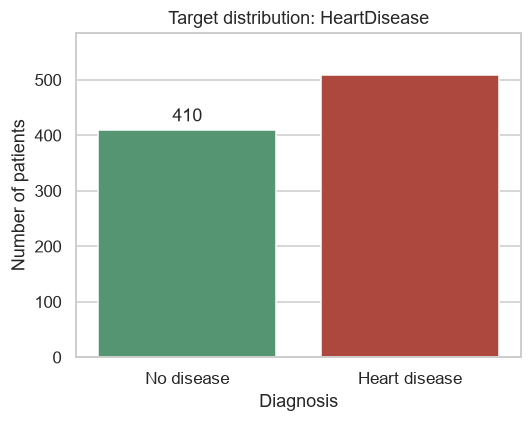

In [7]:
## Understanding distribution of target

## Count and percentage of each class
counts = df[target].value_counts().sort_index()
percent = (df[target].value_counts(normalize=True).sort_index() * 100).round(1)

print("No disease   :", counts[0], "patients (", percent[0], "% )")
print("Heart disease:", counts[1], "patients (", percent[1], "% )")
print("Majority-class baseline accuracy:", percent.max(), "%")

## Bar chart of the class balance
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x=target, hue=target, palette=PALETTE, legend=False, ax=ax)
ax.set_title("Target distribution: HeartDisease")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of patients")
ax.set_xticks([0, 1])
ax.set_xticklabels([LABELS[0], LABELS[1]])
ax.bar_label(ax.containers[0], padding=3)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Interpretation.** The split is 508 disease-positive (55.3%) against 410 negative (44.7%), a ratio of about 1.24 : 1. That is mild enough that resampling, class weighting or SMOTE would be solving a problem that does not exist, and all three would distort the predicted probabilities a threshold selection depends on. No rebalancing is applied.

Two consequences follow. First, **the baseline every model must beat is 55.3% accuracy** — the score obtained by predicting "heart disease" for everyone. A model reporting 78% accuracy is beating a coin flip, not beating that trivial strategy, and only the gap between the two is a real claim. This baseline is reported alongside every model in sections 4 and 5.

Second, near-balance does not rescue accuracy as the headline metric. Balance makes accuracy *interpretable*; it does not make it *appropriate*. Accuracy scores a missed heart disease case and a false referral identically, when section 1 treats the first as the more serious error and the second as recoverable through further assessment. The metric choice follows from that asymmetry, not from this ratio.

One caveat that limits deployment: 55.3% prevalence describes a **referred cardiology cohort**, not the general population, where prevalence is far lower. A model calibrated on this base rate will over-predict disease on unselected primary-care walk-ins. The operating point chosen later is valid for the referred population this dataset represents, and would need recalibration before wider use.

### 2.3.1.2 Understanding distribution of features

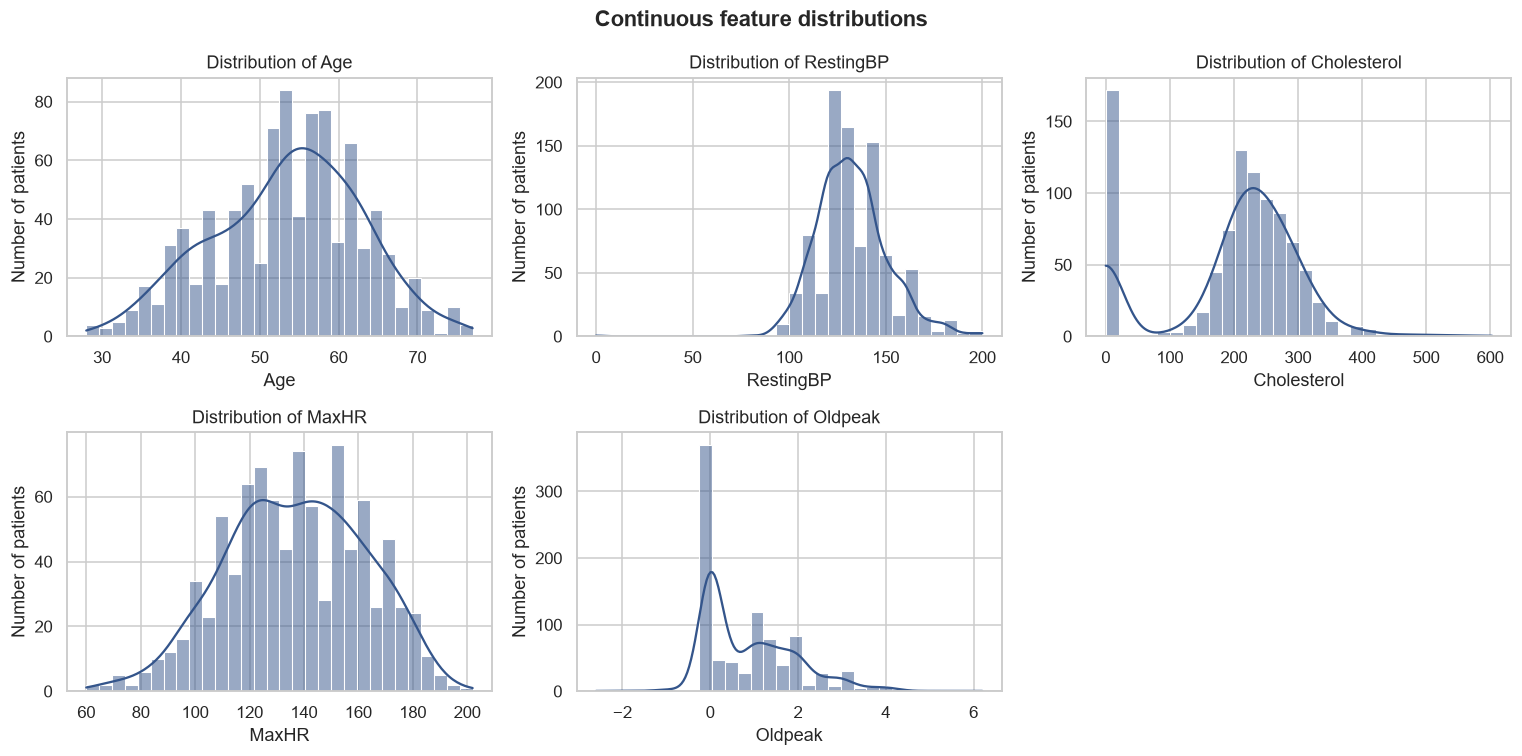

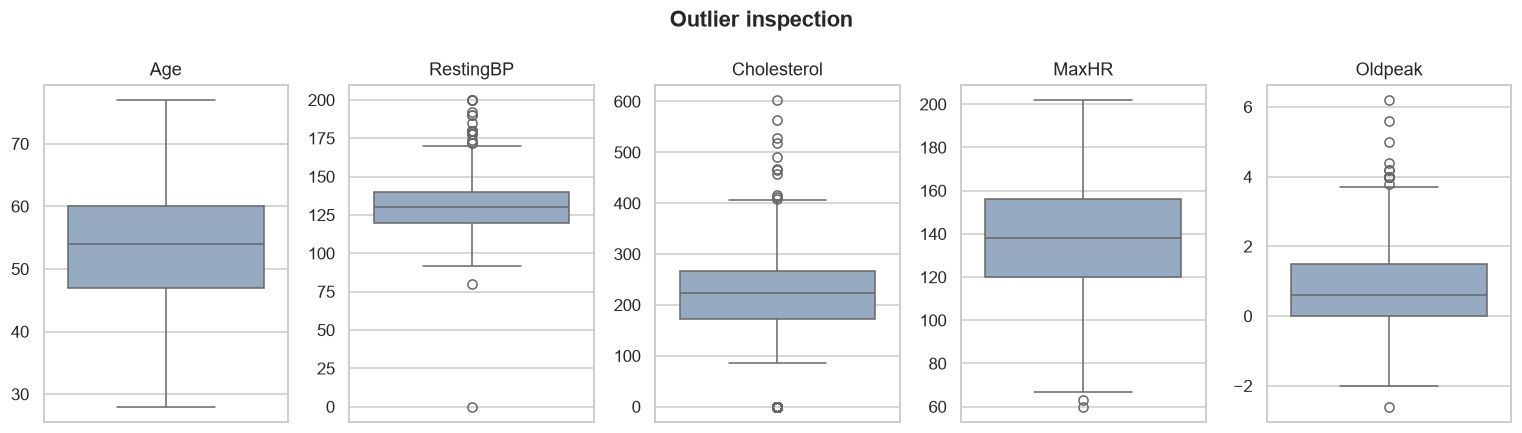

Outliers using the 1.5 x IQR rule:
Age : 0 rows ( 0.0 % )
RestingBP : 28 rows ( 3.1 % )
Cholesterol : 183 rows ( 19.9 % )
MaxHR : 2 rows ( 0.2 % )
Oldpeak : 16 rows ( 1.7 % )


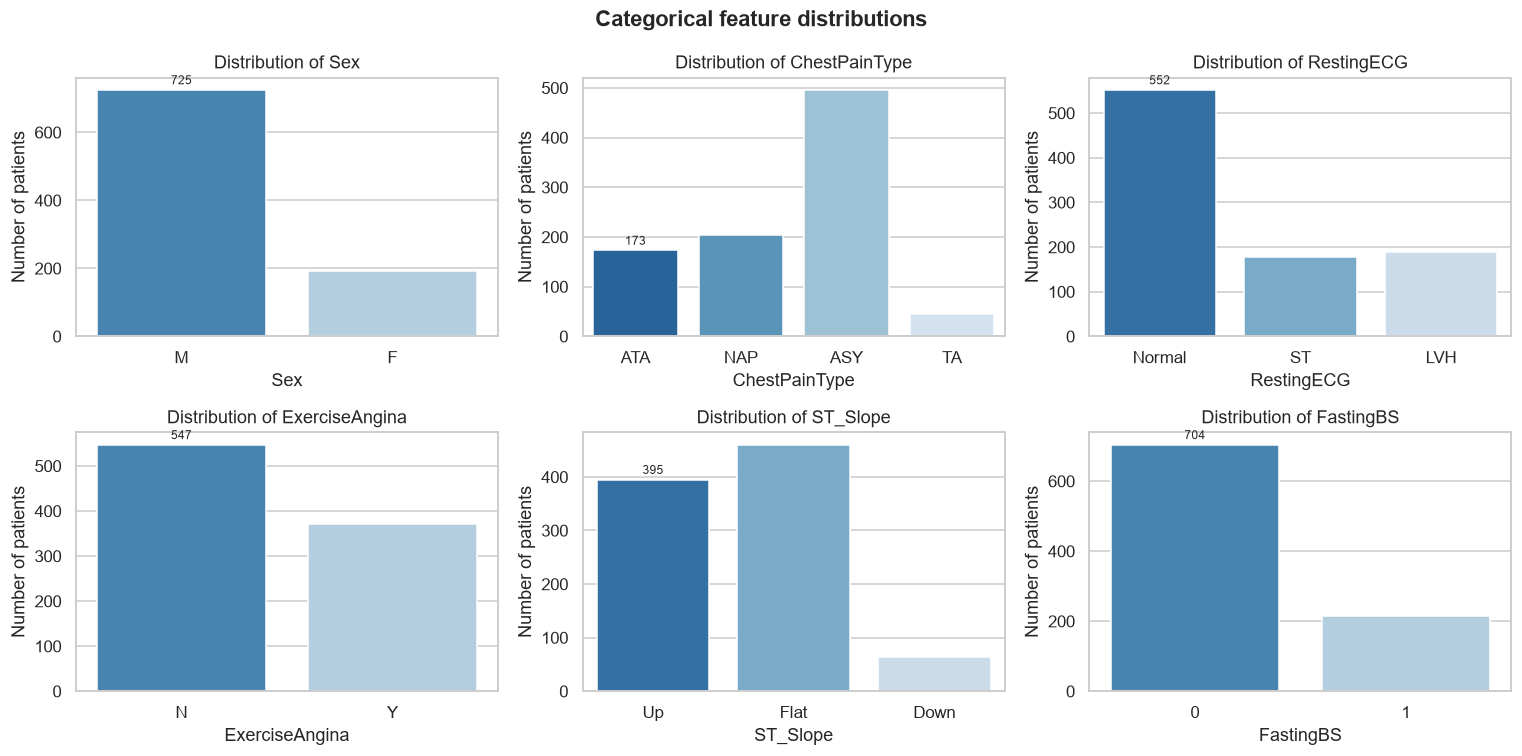

In [8]:
## Understanding distribution of features

## Histograms show the shape of each continuous feature and expose impossible values
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, color="#34558B", ax=axes[i])
    axes[i].set_title("Distribution of " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of patients")
axes[-1].axis("off")
fig.suptitle("Continuous feature distributions", fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots make outliers easy to see
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, color="#8FA9C9", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
fig.suptitle("Outlier inspection", fontweight="bold")
plt.tight_layout()
plt.show()

## Count the outliers so the discussion is based on numbers, not just the picture
print("Outliers using the 1.5 x IQR rule:")
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, ":", n, "rows (", round(n / len(df) * 100, 1), "% )")

## Bar charts for the categorical features, with counts labelled so rare levels stand out
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(category_cols):
    sns.countplot(data=df, x=col, hue=col, palette="Blues_r", legend=False, ax=axes[i])
    axes[i].set_title("Distribution of " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of patients")
    axes[i].bar_label(axes[i].containers[0], fontsize=8, padding=2)
fig.suptitle("Categorical feature distributions", fontweight="bold")
plt.tight_layout()
plt.show()

**Interpretation.**

`Age` is close to symmetric (skew −0.20), centred on 53.5 and spanning 28 to 77 — a plausible referral range with no absurd values and zero IQR outliers.

`Cholesterol` confirms the 2.2.1 finding visually: a tall spike at exactly 0, separated from an otherwise roughly normal body of measured values. There is also an extreme value at 603 mg/dl. It is within the range serum cholesterol can take, so it is retained rather than trimmed.

`RestingBP` has a single record at 0 mm Hg — one data-entry error rather than a systematic gap, so the row is dropped rather than imputed.

`Oldpeak` is the only meaningfully skewed feature (1.02), with a large stack at 0 and a few negative values. No log transform is applied: the zero is meaningful, and a transform would destroy that anchor.

`MaxHR` is broadly symmetric across 60–202 bpm, consistent with an exercise stress test population.

**`ChestPainType` is dominated by `ASY` (asymptomatic) at 54.0%.** The largest single group in a cardiology cohort presented *without* classic chest pain. That undercuts any product built on symptom-led screening: a tool waiting for a patient to report chest pain would miss the majority of this population, which is the argument for a model reading the full panel of markers instead.

`ST_Slope` is badly imbalanced — `Flat` 50.1%, `Up` 43.0%, `Down` only 6.9%. Per-level estimates for `Down` will be high-variance, and it is a candidate for merging into `Flat` if it proves unstable. `ChestPainType = TA` is similarly thin at 5.0%.

**Implications for modelling.** Outlier counts are not uniformly small: `Cholesterol` shows 183 (19.9%) under the 1.5 × IQR rule, but roughly 172 are the disguised zeros already identified, which fall below the lower bound and are flagged automatically. `RestingBP` shows 28 (3.1%), all within a plausible clinical range rather than data errors. `Oldpeak` (16), `MaxHR` (2) and `Age` (0) are modest. None are trimmed — the `Cholesterol` count is addressed by the imputation-plus-flag decision, and the rest sit within a plausible clinical range and tree ensembles are insensitive to them, which favours including them in the comparison. The differing scales confirm scaling is required for the distance- and gradient-based candidates, applied inside a pipeline.

### 2.3.2 Understanding relationship between variables

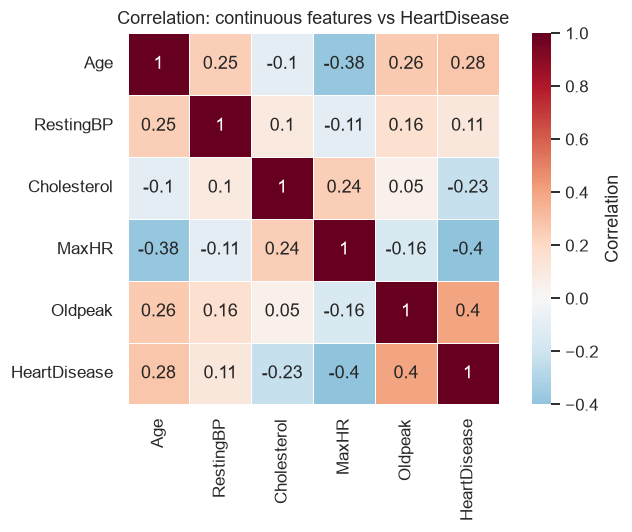

Correlation of each continuous feature with HeartDisease:
MaxHR         -0.40
Cholesterol   -0.23
RestingBP      0.11
Age            0.28
Oldpeak        0.40
Name: HeartDisease, dtype: float64


In [9]:
## Understanding relationship between variables

## Correlation between the continuous features and the target.
## Because HeartDisease is coded 0/1, pandas' Pearson correlation is exactly the
## point-biserial correlation, so no extra library is needed.
corr = df[numeric_cols + [target]].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation: continuous features vs HeartDisease")
plt.tight_layout()
plt.show()

print("Correlation of each continuous feature with HeartDisease:")
print(corr[target].drop(target).sort_values())

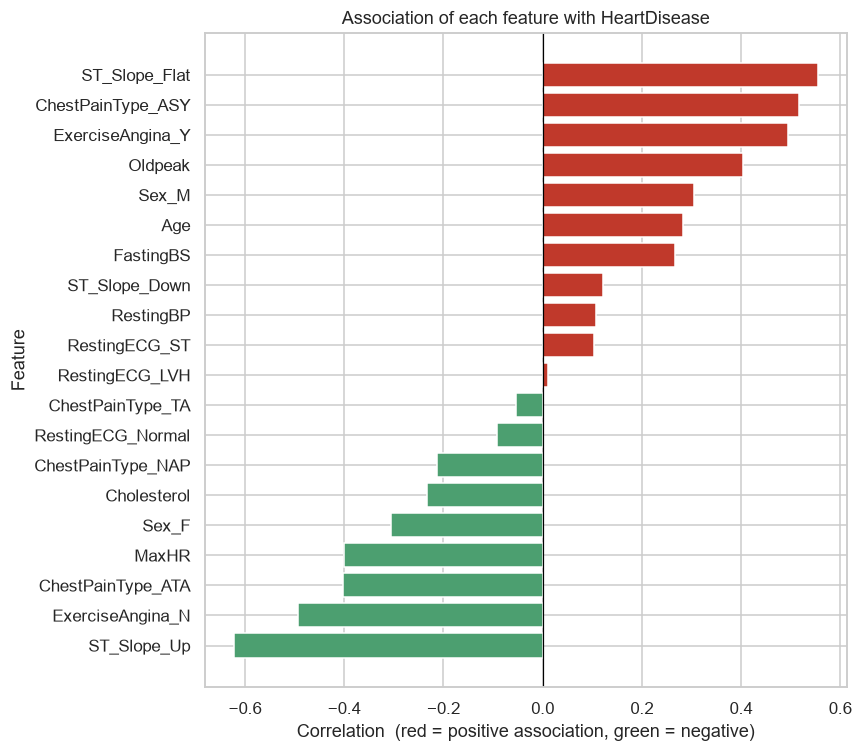

In [10]:
## One-hot encode so that categorical levels can be ranked on the same scale as the
## numeric columns. This is a quick stand-in for feature importance before any model
## is trained, and tells us which features are worth engineering.
encoded = pd.get_dummies(df.drop(columns=[target])).astype(float)
strength = encoded.corrwith(df[target]).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colours = ["#4C9F70" if v < 0 else "#C0392B" for v in strength]
ax.barh(strength.index, strength.values, color=colours)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Association of each feature with HeartDisease")
ax.set_xlabel("Correlation  (red = positive association, green = negative)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

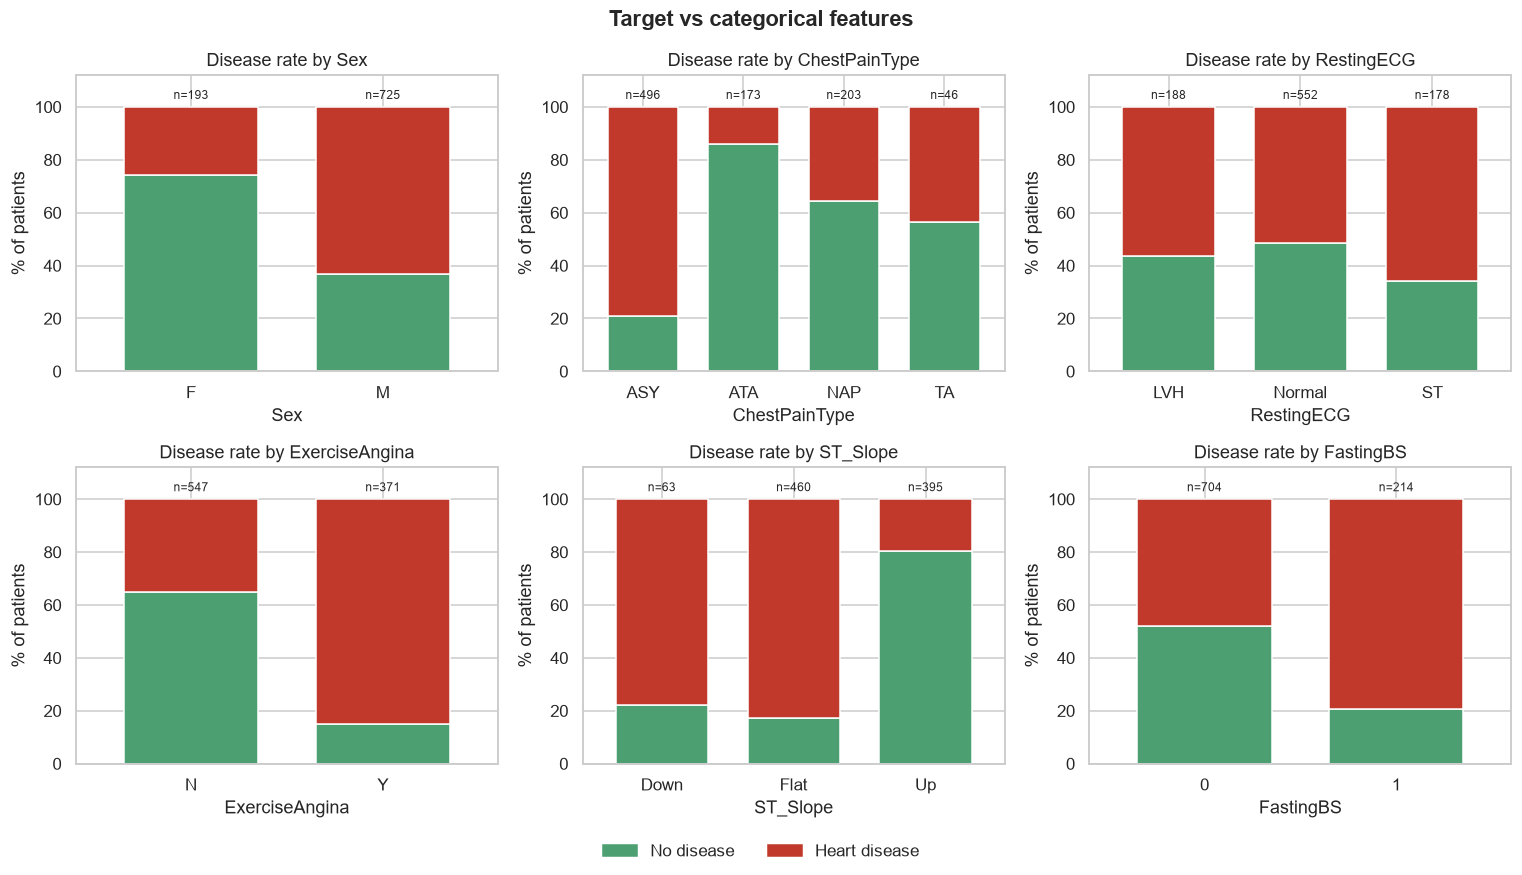

In [11]:
## Stacked percentage bars show how strongly each category splits the target.
## Sample size is printed above each bar because a large effect on a small group
## is not trustworthy.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(category_cols):
    share = pd.crosstab(df[col], df[target], normalize="index") * 100
    share.plot(kind="bar", stacked=True, ax=axes[i], legend=False,
               color=[PALETTE[0], PALETTE[1]], width=0.7)
    axes[i].set_title("Disease rate by " + col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("% of patients")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].set_ylim(0, 112)
    for j, level in enumerate(share.index):
        axes[i].text(j, 103, "n=" + str((df[col] == level).sum()), ha="center", fontsize=8)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[0]),
           plt.Rectangle((0, 0), 1, 1, color=PALETTE[1])]
fig.legend(handles, [LABELS[0], LABELS[1]], loc="lower center", ncol=2, frameon=False)
fig.suptitle("Target vs categorical features", fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

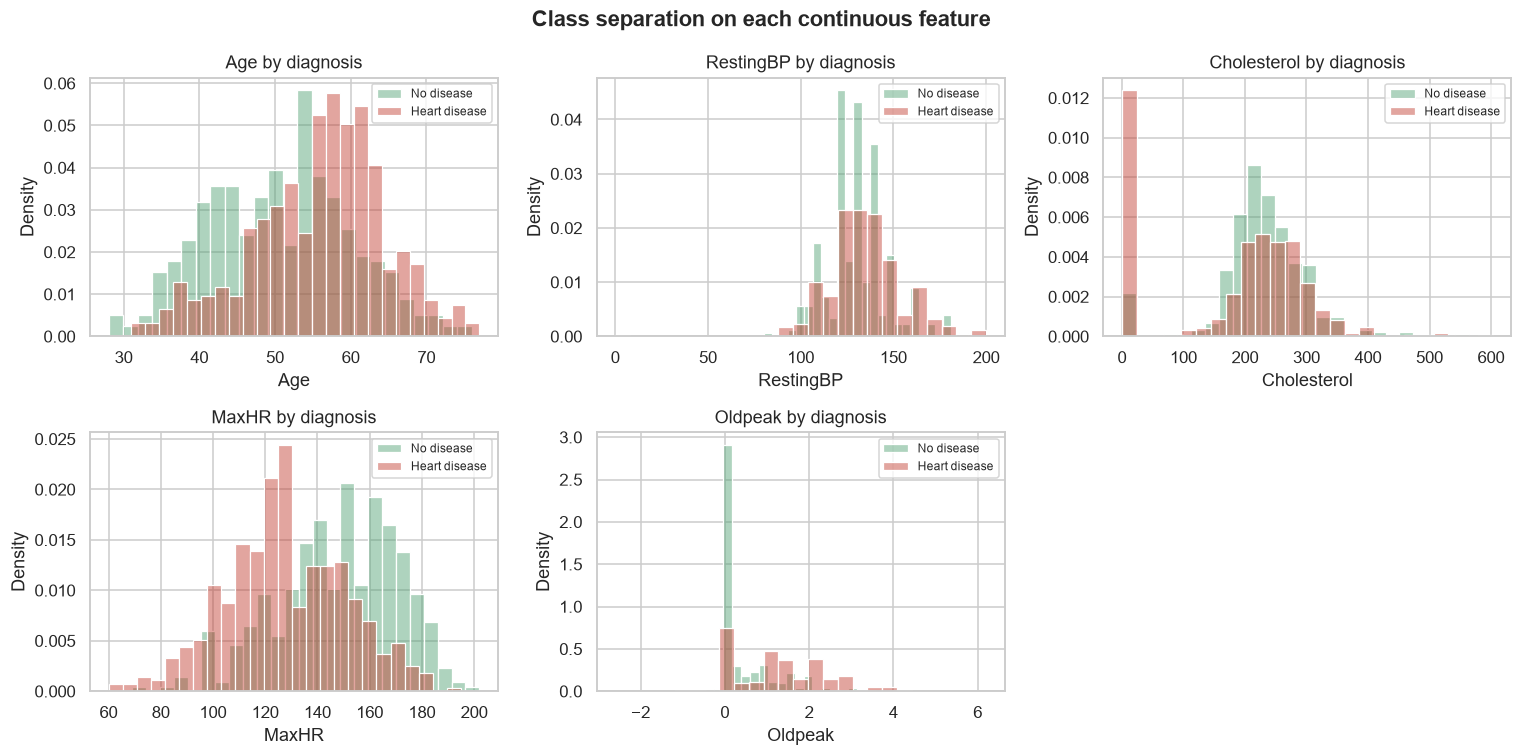

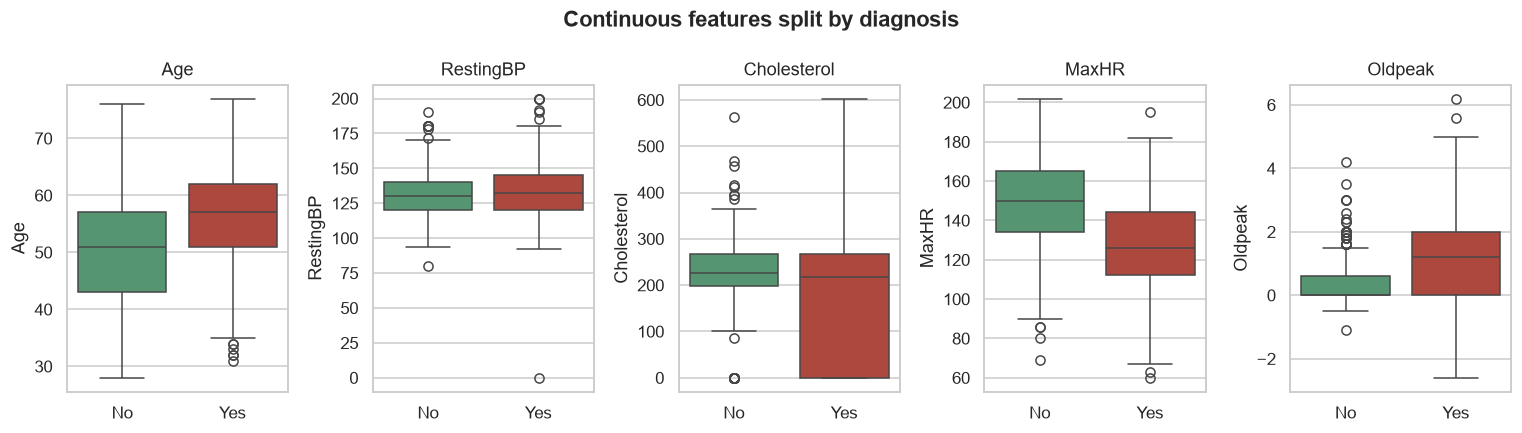

In [12]:
## Overlaid histograms show how much the two classes overlap on each feature.
## Heavy overlap means the model cannot separate patients on that feature alone.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    for cls in [0, 1]:
        sns.histplot(data=df[df[target] == cls], x=col, bins=25, stat="density",
                     alpha=0.45, color=PALETTE[cls], label=LABELS[cls], ax=axes[i])
    axes[i].set_title(col + " by diagnosis")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
axes[-1].axis("off")
fig.suptitle("Class separation on each continuous feature", fontweight="bold")
plt.tight_layout()
plt.show()

## Boxplots of the same comparison, which make the shift in medians easier to read
fig, axes = plt.subplots(1, 5, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x=target, y=col, hue=target, palette=PALETTE,
                legend=False, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["No", "Yes"])
fig.suptitle("Continuous features split by diagnosis", fontweight="bold")
plt.tight_layout()
plt.show()

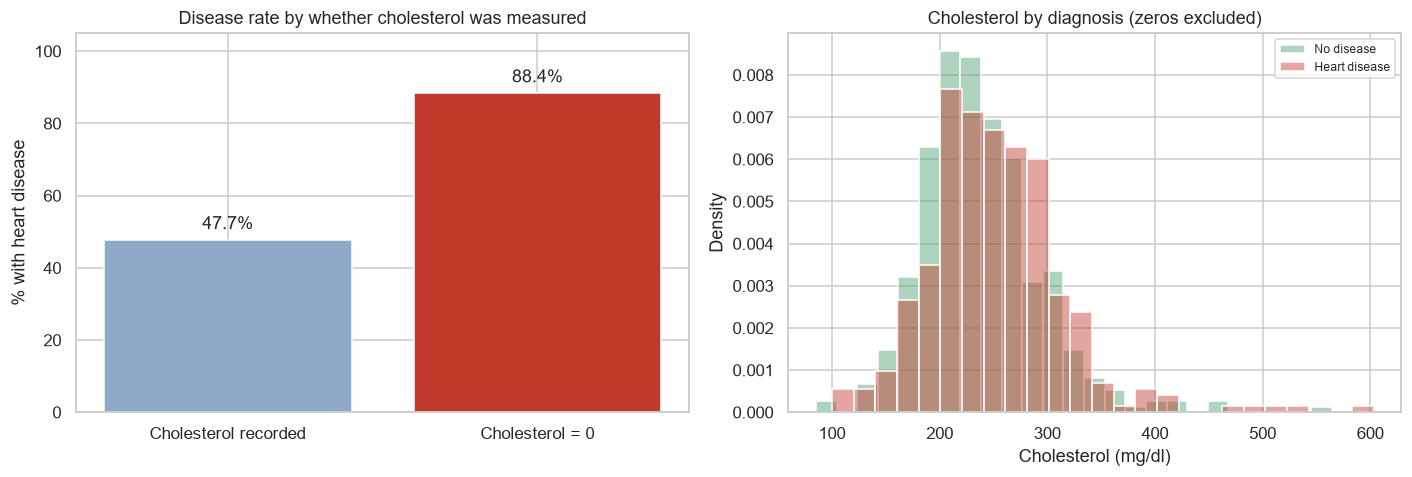

In [13]:
## Left: disease rate depending only on whether cholesterol was recorded.
## Right: the cholesterol distribution once the disguised zeros are excluded.
## Together these show that the zeros carry outcome information that has nothing
## to do with a patient's actual cholesterol level.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

rate = df.groupby(df["Cholesterol"] == 0)[target].mean() * 100
axes[0].bar(["Cholesterol recorded", "Cholesterol = 0"], rate.values,
            color=["#8FA9C9", "#C0392B"])
axes[0].set_title("Disease rate by whether cholesterol was measured")
axes[0].set_ylabel("% with heart disease")
axes[0].set_ylim(0, 105)
for i, v in enumerate(rate.values):
    axes[0].text(i, v + 3, str(round(v, 1)) + "%", ha="center")

measured = df[df["Cholesterol"] > 0]
for cls in [0, 1]:
    sns.histplot(data=measured[measured[target] == cls], x="Cholesterol", bins=25,
                 stat="density", alpha=0.45, color=PALETTE[cls],
                 label=LABELS[cls], ax=axes[1])
axes[1].set_title("Cholesterol by diagnosis (zeros excluded)")
axes[1].set_xlabel("Cholesterol (mg/dl)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

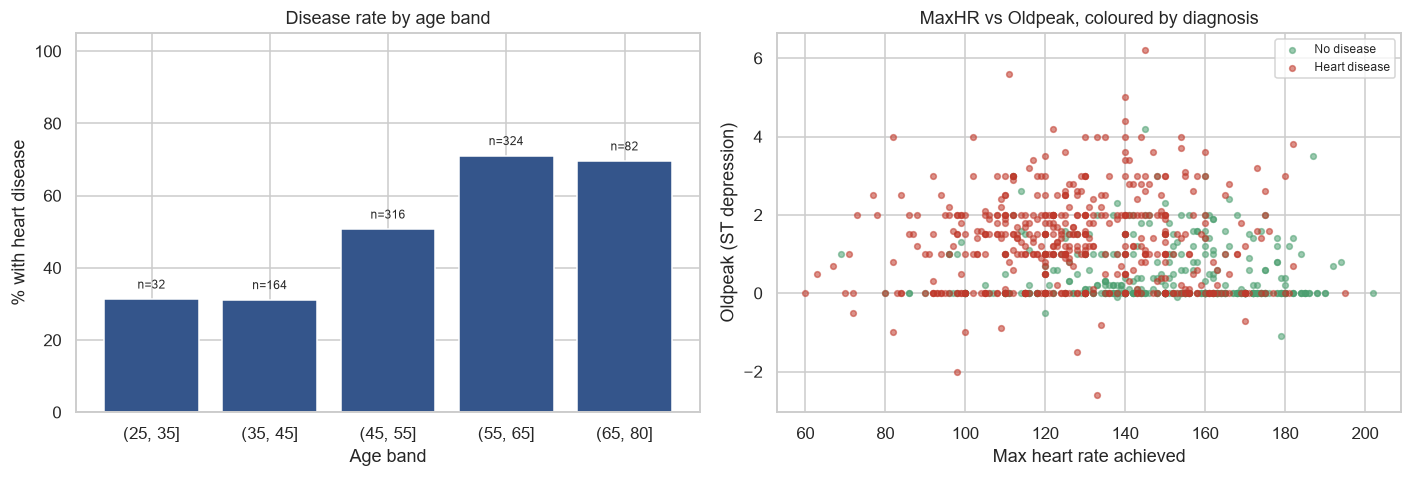

In [14]:
## Disease rate across age bands, which is easier for a non-technical audience
## to read than a correlation coefficient
bands = pd.cut(df["Age"], bins=[25, 35, 45, 55, 65, 80])
by_age = df.groupby(bands, observed=True)[target].agg(["mean", "size"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(by_age.index.astype(str), by_age["mean"] * 100, color="#34558B")
axes[0].set_title("Disease rate by age band")
axes[0].set_xlabel("Age band")
axes[0].set_ylabel("% with heart disease")
axes[0].set_ylim(0, 105)
for i, row in enumerate(by_age.itertuples()):
    axes[0].text(i, row.mean * 100 + 3, "n=" + str(row.size), ha="center", fontsize=8)

## Two features plotted together, to see whether the classes separate in 2D.
## This gives an early feel for how complex a decision boundary the model needs.
for cls in [0, 1]:
    subset = df[df[target] == cls]
    axes[1].scatter(subset["MaxHR"], subset["Oldpeak"], s=14, alpha=0.55,
                    color=PALETTE[cls], label=LABELS[cls])
axes[1].set_title("MaxHR vs Oldpeak, coloured by diagnosis")
axes[1].set_xlabel("Max heart rate achieved")
axes[1].set_ylabel("Oldpeak (ST depression)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

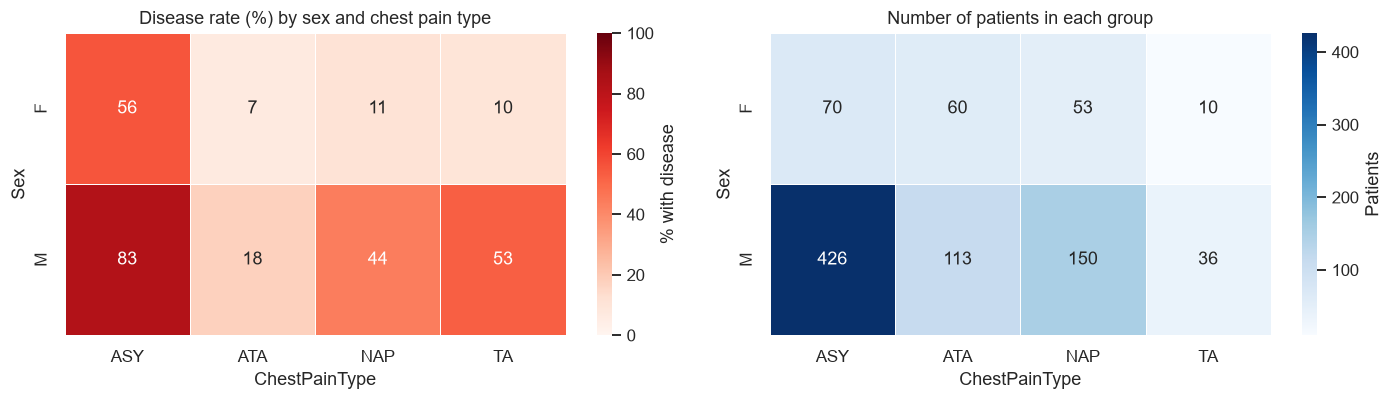

Strongest correlations between predictors:
Age          Age          1.00
MaxHR        Age          0.38
Age          Oldpeak      0.26
             RestingBP    0.25
Cholesterol  MaxHR        0.24
Oldpeak      RestingBP    0.16
dtype: float64


In [15]:
## Disease rate for each Sex x ChestPainType combination, with the number of patients
## in each cell. Small cells warn us where the model's performance estimate will be
## unreliable and where a headline metric hides poor performance.
rate_table = df.pivot_table(index="Sex", columns="ChestPainType",
                            values=target, aggfunc="mean") * 100
size_table = df.pivot_table(index="Sex", columns="ChestPainType",
                            values=target, aggfunc="size")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(rate_table, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            linewidths=0.5, cbar_kws={"label": "% with disease"}, ax=axes[0])
axes[0].set_title("Disease rate (%) by sex and chest pain type")

sns.heatmap(size_table, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Patients"}, ax=axes[1])
axes[1].set_title("Number of patients in each group")

plt.tight_layout()
plt.show()

## Finally, check whether any two continuous predictors carry the same information
print("Strongest correlations between predictors:")
print(df[numeric_cols].corr().abs().unstack().sort_values(ascending=False)
        .drop_duplicates().head(6).round(2))

### 2.3.3 What the relationships mean for the model

**`ST_Slope` is the strongest single predictor.** Upsloping patients are overwhelmingly disease-negative, flat-sloped overwhelmingly positive. But `ST_Slope`, `Oldpeak`, `MaxHR` and `ExerciseAngina` all come from an **exercise stress test**, so the features carrying most of the signal are not available at a walk-in consultation. This model describes a patient already escalated to a stress test, and a reduced feature set is built to quantify what that test contributes.

**Asymptomatic chest pain is the highest-risk category, not the lowest.** `ASY` patients show a far higher disease rate than those reporting atypical angina, and `ASY` is simultaneously the largest group. Within this data, a rule keyed only on reported chest pain would miss most diseased patients, which is the argument for a model reading the full panel of markers instead.

**Class separation is real but no single feature is sufficient.** `Oldpeak` (+0.40) and `MaxHR` (−0.40) correlate most strongly, then `Age` (+0.28); `Cholesterol` (−0.23) and `RestingBP` (+0.11) are weak, and the `Cholesterol` figure measures the missingness pattern rather than physiology. Overlaid histograms show `Age`, `RestingBP` and `Cholesterol` overlapping heavily, so a univariate rule would perform poorly. The `MaxHR`–`Oldpeak` scatter shows partial separation with a substantial mixed region — those are the patients a threshold choice has to adjudicate.

**The cholesterol plots isolate a leakage risk.** Disease rate depends on *whether the test was recorded* — 47.7% when measured against 88.4% when the value reads 0. Once zeros are excluded, actual cholesterol separates the classes only weakly. A model that mean-imputes without a missingness flag learns a collection-specific pattern here, so the flag is built explicitly and its influence tested directly in 6.1.

**Subgroup sizes limit what a single metric can claim.** With women at 21% of the sample, a headline figure is dominated by the male majority. Metrics are reported by sex in 5.4.

**No strong pairwise correlation among the continuous predictors.** The strongest pair is `Age`/`MaxHR` at |r| = 0.38, everything else at or below 0.26. This rules out pairwise redundancy; it does not rule out multicollinearity across three or more columns, which is why 6.2 tests the feature set empirically rather than trusting this check alone.

**Decisions carried forward:**

1. Drop the single `RestingBP = 0` record; retain other outliers as clinically plausible.
2. Treat `Cholesterol = 0` as missing, impute it, and add a `Cholesterol_missing` flag.
3. One-hot encode categoricals; consider merging `ST_Slope = Down` into `Flat` if unstable.
4. Scale continuous features inside a `Pipeline`, for scaling-sensitive models only.
5. Stratify the split to preserve the 55.3 / 44.7 ratio.
6. Report the majority-class baseline beside every result, and metrics separately by sex.
7. Build a reduced pre-stress-test feature set to quantify the stress test's contribution.

# 3. Data Preparation

Section 2 ended with a numbered list of decisions. This section carries each of them out, in the order they need to happen:

| Step | What it does | Which 2.3.3 decision it implements |
| --- | --- | --- |
| 3.1 Data Cleaning | remove the impossible `RestingBP` record, convert disguised missing values to `NaN` | 1, 2 (first half) |
| 3.2 Feature Engineering | build the missingness flag and three clinically-motivated derived features | 2 (second half) |
| 3.3 Feature Selection | define the full and reduced "pre-stress-test" feature sets | 7 |
| 3.4 Preprocessing Pipeline | encode, impute and scale — fitted inside a `Pipeline` so nothing leaks | 3, 4 |
| 3.5 Train-Test Split | stratified hold-out that preserves the class ratio | 5 |

**The ordering matters and is deliberate.** Row-level repairs that depend on no statistics at all (dropping a corrupt record, marking a 0 as missing) happen before the split, because they would be applied identically to any future patient and involve no information from other rows. Everything that *learns a value from the data* — imputation medians, scaling means, category vocabularies — is deferred into a `Pipeline` in 3.4 and fitted only on training folds. Doing the imputation eagerly here would leak the test set's cholesterol distribution into training and inflate every score reported later.

## 3.1 Data Cleaning

In [16]:
## Work on a copy so the raw frame stays intact -- the shape comparison printed at the
## end of this cell reads df.shape, so it must not be modified in place.
data = df.copy()

## --- Step 1: remove the physiologically impossible RestingBP record ---
## Section 2.3.1.2 identified exactly one patient with RestingBP = 0 mm Hg. This is a
## data-entry error rather than a systematic collection gap, so the row is dropped.
## Only one row is lost, so the cost to sample size is negligible.
before = len(data)
data = data[data["RestingBP"] > 0].copy()
print("Rows dropped for RestingBP = 0:", before - len(data))

## --- Step 2: convert disguised missing cholesterol values to NaN ---
## A serum cholesterol of 0 means the lipid panel was never drawn, not that the patient
## has no cholesterol. Marking these as NaN stops the value 0 being treated as a real
## measurement, and hands the imputation decision to the pipeline in 3.4 where it can
## be fitted on training data only.
print("Cholesterol values converted to NaN:", (data["Cholesterol"] == 0).sum())
data["Cholesterol"] = data["Cholesterol"].replace(0, np.nan)

## --- Step 3: confirm no duplicate patient records ---
## The dataset compiler already removed 272 duplicates, so this is a safety check
## rather than an expected fix.
print("Duplicate rows remaining:", data.duplicated().sum())

## --- Step 4: negative Oldpeak values ---
## Oldpeak is ST depression, so a negative reading indicates ST elevation or a
## sign convention difference in one of the source cohorts. These are left as-is:
## they are a small minority, they are ordered correctly relative to 0, and both
## tree ensembles and a scaled logistic regression handle the sign without issue.
print("Negative Oldpeak records retained:", (data["Oldpeak"] < 0).sum())

## --- Cleaning summary ---
print("\nShape before cleaning:", df.shape)
print("Shape after cleaning: ", data.shape)
print("\nMissing values after cleaning:")
print(data.isna().sum()[data.isna().sum() > 0])

Rows dropped for RestingBP = 0: 1
Cholesterol values converted to NaN: 171
Duplicate rows remaining: 0
Negative Oldpeak records retained: 13

Shape before cleaning: (918, 12)
Shape after cleaning:  (917, 12)

Missing values after cleaning:
Cholesterol    171
dtype: int64


**What was and was not removed, and why.**

`RestingBP = 0` is dropped outright: a resting blood pressure of zero is incompatible with a living patient, it appears exactly once, and there is no principled value to impute — a single row is a cheaper loss than a fabricated one.

`Cholesterol = 0` is *not* dropped, and this is the more consequential call. 2.2.1 counted 172; 171 are converted here, because one belonged to the same patient as the impossible `RestingBP` reading and was already removed. Those 171 records are close to a fifth of the dataset and are heavily disease-positive relative to the measured records. Deleting them would discard a large block of patients non-randomly with respect to the target, shifting the class balance and biasing every downstream estimate. Converting them to `NaN` keeps the patients, removes the false measurement, and defers imputation to a pipeline step that never sees the test set.

The 13 negative `Oldpeak` values are retained. Unlike a cholesterol of zero they are not impossible — they reflect ST elevation or a sign convention difference between source cohorts. Clipping them to zero would erase a genuine distinction, and none of the candidate models require non-negative inputs.

Outliers flagged by the IQR rule in 2.3.1.2 are also retained: the large `Cholesterol` count was mostly the disguised zeros, now handled, and the `RestingBP` tail is a plausible hypertensive population. Trimming clinically real extremes would remove exactly the high-risk patients this model exists to catch.

After this step the shape is 917 × 12, and the only remaining missing values sit in `Cholesterol`.

## 3.2 Feature Engineering

In [17]:
## Feature engineering is applied to the cleaned frame. Every feature below is
## computed from a single patient's own record, so it can be recomputed identically
## at prediction time in the Streamlit app and introduces no cross-row leakage.

## --- Feature 1: Cholesterol_missing ---
## Section 2.2.1 found that whether a lipid panel was drawn is more predictive than
## the value it returned. Making this explicit lets the model use the fact openly
## instead of inferring it from an imputed cholesterol value, and keeps the imputed
## column interpretable as an actual cholesterol estimate.
data["Cholesterol_missing"] = data["Cholesterol"].isna().astype(int)

## --- Feature 2: HR_reserve_deficit ---
## Age-predicted maximum heart rate is approximated here as 220 - age, a rough heuristic
## with substantial individual variation rather than a validated clinical measure. The
## shortfall between that estimate and the rate achieved combines Age and MaxHR into one
## convenience quantity; section 2.3.2 showed the two
## are the most correlated predictor pair (|r| = 0.38), so a ratio-style term captures
## their interaction that neither column expresses alone.
data["HR_reserve_deficit"] = (220 - data["Age"]) - data["MaxHR"]

## --- Feature 3: HasSTDepression ---
## Oldpeak is heavily zero-inflated: a large block of patients have no ST depression at
## all, and the remainder spread over a continuous range. A linear model cannot express
## "any depression at all" as distinct from "how much"; this flag separates the two so
## logistic regression can weight the threshold effect and the magnitude effect
## independently.
data["HasSTDepression"] = (data["Oldpeak"] > 0).astype(int)

## --- Feature 4: BP_category ---
## Resting blood pressure correlated only weakly with the target as a raw number
## (r = 0.11), which is expected: clinical risk rises in steps at recognised
## thresholds rather than linearly per mm Hg. Binning to the standard hypertension
## stages gives a linear model access to that step structure.
## right=False makes the intervals left-closed: [0,120), [120,130), [130,140), [140,300).
## With the default right=True a reading of exactly 120 would fall into "Normal" and
## 140 into "Stage1", both one band below the ACC/AHA definition.
data["BP_category"] = pd.cut(
    data["RestingBP"],
    bins=[0, 120, 130, 140, np.inf],
    labels=["Normal", "Elevated", "Stage1", "Stage2"],
    right=False,
)

print("Engineered features added:")
engineered = ["Cholesterol_missing", "HR_reserve_deficit",
              "HasSTDepression", "BP_category"]
print(data[engineered].head())
print("\nNew shape:", data.shape)

Engineered features added:
   Cholesterol_missing  HR_reserve_deficit  HasSTDepression BP_category
0                    0                   8                0      Stage2
1                    0                  15                1      Stage2
2                    0                  85                0      Stage1
3                    0                  64                1      Stage1
4                    0                  44                0      Stage2

New shape: (917, 16)


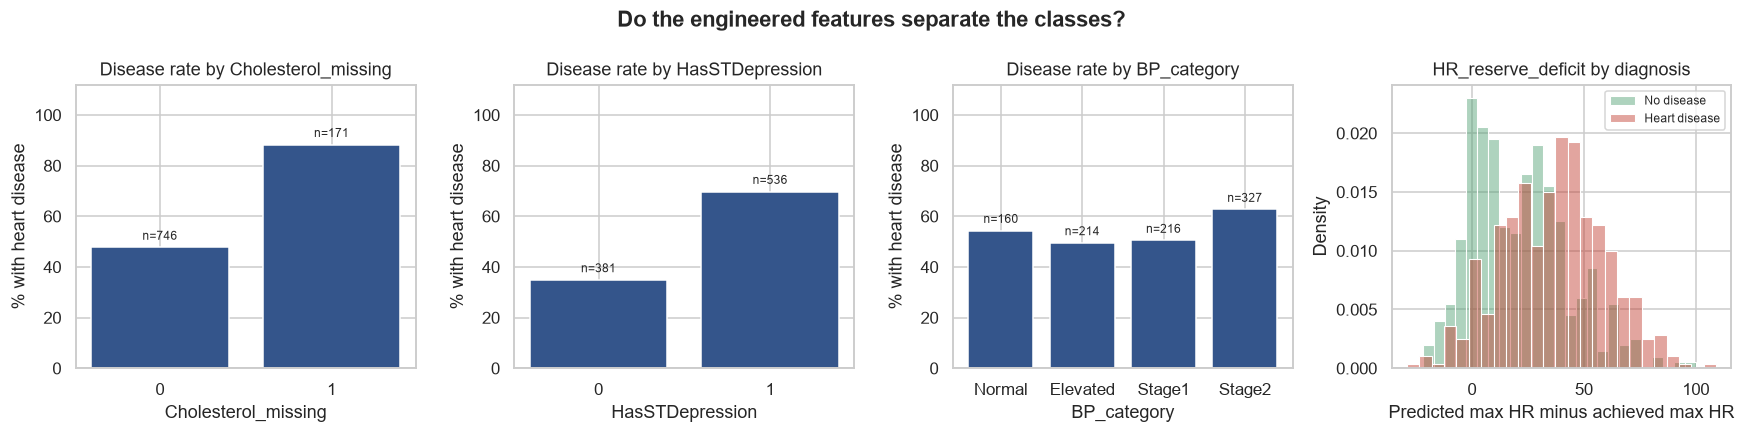

Correlation with HeartDisease -- engineered vs source features:
  Cholesterol_missing    r = +0.318   (source Cholesterol  r = +0.104)
  HR_reserve_deficit     r = +0.321   (source MaxHR        r = -0.401)
  HasSTDepression        r = +0.346   (source Oldpeak      r = +0.404)
  BP_category_code       r = +0.078   (source RestingBP    r = +0.118)


In [18]:
## Check that each engineered feature actually separates the classes, rather than
## assuming it does. A feature that does not move the disease rate is not worth keeping.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

## Three binary/categorical features: disease rate per level, with group sizes
for ax, col in zip(axes[:3], ["Cholesterol_missing", "HasSTDepression", "BP_category"]):
    rate = data.groupby(col, observed=True)[target].mean() * 100
    size = data.groupby(col, observed=True)[target].size()
    ax.bar(rate.index.astype(str), rate.values, color="#34558B")
    ax.set_title("Disease rate by " + col)
    ax.set_xlabel(col)
    ax.set_ylabel("% with heart disease")
    ax.set_ylim(0, 112)
    for i, (v, n) in enumerate(zip(rate.values, size.values)):
        ax.text(i, v + 3, "n=" + str(n), ha="center", fontsize=8)

## One continuous feature: distribution split by class
for cls in [0, 1]:
    sns.histplot(data=data[data[target] == cls], x="HR_reserve_deficit", bins=25,
                 stat="density", alpha=0.45, color=PALETTE[cls],
                 label=LABELS[cls], ax=axes[3])
axes[3].set_title("HR_reserve_deficit by diagnosis")
axes[3].set_xlabel("Predicted max HR minus achieved max HR")
axes[3].set_ylabel("Density")
axes[3].legend(fontsize=8)

fig.suptitle("Do the engineered features separate the classes?", fontweight="bold")
plt.tight_layout()
plt.show()

## Quantify the same thing, so the rationale rests on numbers rather than the picture.
## Each engineered feature is compared against the raw column it was derived from.
print("Correlation with HeartDisease -- engineered vs source features:")
check = data.copy()
check["BP_category_code"] = check["BP_category"].cat.codes
pairs = [
    ("Cholesterol_missing", "Cholesterol"),
    ("HR_reserve_deficit", "MaxHR"),
    ("HasSTDepression", "Oldpeak"),
    ("BP_category_code", "RestingBP"),
]
for new, source in pairs:
    r_new = check[new].corr(check[target])
    r_src = check[source].corr(check[target])
    print(f"  {new:22} r = {r_new:+.3f}   (source {source:12} r = {r_src:+.3f})")

**Rationale for each engineered feature.**

| Engineered feature | r with target | Source column | r with target |
| --- | --- | --- | --- |
| `Cholesterol_missing` | +0.318 | `Cholesterol` | +0.104 |
| `HR_reserve_deficit` | +0.321 | `MaxHR` | −0.401 |
| `HasSTDepression` | +0.346 | `Oldpeak` | +0.404 |
| `BP_category` | +0.078 | `RestingBP` | +0.118 |

- **`Cholesterol_missing`** records whether a value was present. It is included so that the pattern identified in 2.2.1 is visible to the feature importances rather than folded into an imputed cholesterol value. Cleaning has already changed the picture here: raw `Cholesterol` correlated at **−0.23** before the zeros were handled — an implausible protective direction — and at **+0.104** on measured patients afterwards.
- **`HR_reserve_deficit`** combines `Age` and `MaxHR` using the rough `220 − age` heuristic. The heuristic is approximate with substantial individual variation, so this is a convenience combination rather than a validated clinical measure.
- **`HasSTDepression`** flags any ST depression, separate from its magnitude, for the zero-inflation visible in the 2.3.1.2 histogram. A tree can already split `Oldpeak` at zero, so it is expected to matter mainly for the linear model.
- **`BP_category`** bins `RestingBP` at the standard hypertension stages, with left-closed intervals so a reading of exactly 120 falls in "Elevated". It correlates *less* strongly than the raw column, so binning has cost univariate information.

All four retain their source columns, so no information is removed. They can still hurt — a redundant feature adds variance — which is what feature selection in 6.2 tests.

## 3.3 Feature Selection

In [19]:
## Two feature sets are defined, corresponding to two deployment scenarios.

## The target and the columns that will not be fed to any model
X_full = data.drop(columns=[target])
y = data[target]

## --- Feature set A: full ---
## Everything available, including the four measurements derived from an exercise
## stress test. This is the model for a patient already undergoing cardiac workup.
features_full = X_full.columns.tolist()

## --- Feature set B: reduced, "pre-stress-test" ---
## Section 2.3.3 established that ST_Slope, Oldpeak, MaxHR and ExerciseAngina all come
## from an exercise stress test, which is not available at a first consultation. Any
## feature derived from those is excluded too, which removes HR_reserve_deficit and
## HasSTDepression. What remains is history, a resting ECG and a blood panel.
stress_test_features = [
    "ST_Slope", "Oldpeak", "MaxHR", "ExerciseAngina",
    "HR_reserve_deficit", "HasSTDepression",
]
features_reduced = [c for c in features_full if c not in stress_test_features]

print("Full feature set (", len(features_full), "features ):")
print(" ", features_full)
print("\nReduced pre-stress-test feature set (", len(features_reduced), "features ):")
print(" ", features_reduced)
print("\nExcluded from the reduced set:")
print(" ", stress_test_features)

Full feature set ( 15 features ):
  ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'Cholesterol_missing', 'HR_reserve_deficit', 'HasSTDepression', 'BP_category']

Reduced pre-stress-test feature set ( 9 features ):
  ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'Cholesterol_missing', 'BP_category']

Excluded from the reduced set:
  ['ST_Slope', 'Oldpeak', 'MaxHR', 'ExerciseAngina', 'HR_reserve_deficit', 'HasSTDepression']


**Why two feature sets rather than one.**

Section 2.3.3 identified a structural property of this dataset: the strongest predictors — `ST_Slope`, `Oldpeak`, `MaxHR`, `ExerciseAngina` — are all outputs of an exercise stress test. A model built on them does not help a clinician decide *whether to order* one; it interprets one already run. That is a legitimate product, but a narrower one than the triage framing in 1 implies.

**Only the full set produces a deployed model.** The reduced set is a measurement instrument: fitting the same algorithms without those four features quantifies what the stress test contributes to the diagnosis. All three algorithms are trained on both sets, so:

- **Full set** — the pool the deployed model is selected from, containing the strongest signal in the data.
- **Reduced set** — a control. Its purpose is the *gap*, which tells a referring clinician how much diagnostic value the stress test adds. No model fitted on it is deployed.

This matters for reading the modelling section correctly. Where a table shows six rows — three algorithms × two feature sets — only the three full-set rows are deployment candidates.

**No automated feature selection is applied here.** The dataset has only 11 original predictors and 2.3.2 confirmed no predictor pair exceeds |r| = 0.38, so there is no redundancy to remove, and with this few features the risk of discarding a clinically meaningful one outweighs any dimensionality benefit. Selection here is driven by *when a measurement becomes available in the clinical pathway* — a business constraint no automated method could have discovered from the data.

## 3.4 Preprocessing Pipeline

In [20]:
## Everything that learns a parameter from the data lives here, so it is fitted on
## training folds only. This is what stops imputation medians and scaler means leaking.

def build_preprocessor(feature_list, scale_numeric):
    """ColumnTransformer for the given features.

    scale_numeric=True for logistic regression (scale-sensitive), False for the trees.
    """
    ## Split the requested features by the treatment they need
    numeric = [c for c in feature_list
               if c in ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak",
                        "HR_reserve_deficit"]]
    categorical = [c for c in feature_list
                   if c in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina",
                            "ST_Slope", "BP_category"]]
    ## Already 0/1, so they need neither scaling nor encoding
    passthrough = [c for c in feature_list
                   if c in ["FastingBS", "Cholesterol_missing", "HasSTDepression"]]

    ## Median imputation for the numeric block. Median rather than mean because
    ## Cholesterol retains genuine high extremes (up to 603 mg/dl) that would drag a
    ## mean upward; the median is unaffected by them.
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numeric),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
            ("pass", "passthrough", passthrough),
        ],
        remainder="drop",
    )


## Four preprocessors: two feature sets x scaled/unscaled
preprocessor_full_scaled = build_preprocessor(features_full, scale_numeric=True)
preprocessor_full_tree = build_preprocessor(features_full, scale_numeric=False)
preprocessor_reduced_scaled = build_preprocessor(features_reduced, scale_numeric=True)
preprocessor_reduced_tree = build_preprocessor(features_reduced, scale_numeric=False)

print("Preprocessors built.")
print("  Full set    :", len(features_full), "features in")
print("  Reduced set :", len(features_reduced), "features in")
print("\nEach is fitted inside a Pipeline, on training data only.")

Preprocessors built.
  Full set    : 15 features in
  Reduced set : 9 features in

Each is fitted inside a Pipeline, on training data only.


**Design decisions in the preprocessing step.**

**Imputation.** `Cholesterol` is imputed with the median rather than the mean: 2.3.1.2 confirmed the column retains genuine high extremes up to 603 mg/dl, which would pull a mean upward while leaving the median unaffected. More importantly, the imputer is a pipeline step rather than something applied to `data` directly — during cross-validation it is refitted on each training fold, so no fold's cholesterol distribution informs the values used to score it. Imputing eagerly would have been simpler and would have quietly inflated every result.

**Encoding.** `OneHotEncoder(drop="first")` avoids the dummy-variable trap for logistic regression, where perfectly collinear columns make coefficients unstable. `handle_unknown="ignore"` guards the deployment: an unseen category at prediction time returns a prediction rather than raising.

**Scaling, applied selectively.** Scaling helps logistic regression's optimiser converge, keeps its regularisation penalty applied evenly across coefficients, and makes coefficient magnitudes comparable to one another. Tree models split on thresholds within each feature independently, so scaling changes nothing for them beyond wasted computation. Building both variants keeps the tree importances readable in original units.

**Passthrough columns.** `FastingBS`, `Cholesterol_missing` and `HasSTDepression` are already 0/1. Scaling a binary indicator distorts its interpretation, and one-hot encoding would produce a redundant duplicate.

**`remainder="drop"`** is set explicitly so a column added later cannot silently enter the model unprocessed.

## 3.5 Train-Test Split

In [21]:
## Split data into train set and test set

## An 80/20 split. With ~917 rows after cleaning this leaves roughly 180 patients in the
## test set -- large enough for a confusion matrix to be meaningful,
## while keeping enough training data for three algorithms plus hyperparameter tuning.
##
## stratify=y is essential here. The 55.3 / 44.7 class ratio is mild but a random split
## on a dataset this size can still drift by several percentage points, which would make
## the majority-class baseline different between train and test and render the
## later comparison meaningless.
##
## random_state=42 is fixed so that every result in sections 4 and 5 is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

print("Training set:", X_train.shape[0], "patients")
print("Test set:    ", X_test.shape[0], "patients")

## Confirm the split preserved the class balance in both halves
print("\nClass balance check (% with heart disease):")
print("  Full data :", round(y.mean() * 100, 1), "%")
print("  Train     :", round(y_train.mean() * 100, 1), "%")
print("  Test      :", round(y_test.mean() * 100, 1), "%")

## The majority-class baseline every model in sections 4 and 5 must beat
baseline_accuracy = max(y_test.mean(), 1 - y_test.mean())
print("\nMajority-class baseline accuracy on the test set:",
      round(baseline_accuracy * 100, 1), "%")

## The reduced feature set uses the same split, so that the full and reduced models are
## compared on identical patients rather than different random subsets.
X_train_reduced = X_train[features_reduced]
X_test_reduced = X_test[features_reduced]

## One resampling scheme, defined once and reused by every cross-validation in
## sections 4 and 6. Several comparisons below are only valid because they were scored
## on identical folds -- defining the splitter separately in each section would make
## that a coincidence rather than a guarantee, and a later edit to one copy would
## silently invalidate the comparisons without raising an error.
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nFull set    -- train:", X_train.shape, " test:", X_test.shape)
print("Reduced set -- train:", X_train_reduced.shape, " test:", X_test_reduced.shape)

Training set: 733 patients
Test set:     184 patients

Class balance check (% with heart disease):
  Full data : 55.3 %
  Train     : 55.3 %
  Test      : 55.4 %

Majority-class baseline accuracy on the test set: 55.4 %

Full set    -- train: (733, 15)  test: (184, 15)
Reduced set -- train: (733, 9)  test: (184, 9)


**Why this split, and what it protects.**

**Stratification worked.** The disease rate holds at 55.3% across the full cleaned data and in training, 55.4% in the test set. Without `stratify=y` a random draw on 917 rows can shift that ratio by several points, which would break the later comparison subtly — the majority-class baseline would differ between train and test, so a model could appear to beat it purely because the test set was easier.

**80/20 gives 733 training and 184 test patients**, roughly 102 disease-positive cases held out. That is enough for a confusion matrix and recall figure to be read with some confidence. A 70/30 split would tighten the test estimate but costs training data that three algorithms and a hyperparameter search need more.

**One split, used by both feature sets.** `X_train_reduced` is a column subset of `X_train`, not an independent draw, so any performance gap between them is attributable to the missing stress-test features rather than to a luckier partition.

**One resampling scheme, defined once.** The 5-fold stratified splitter created here is reused by every cross-validation below. Several comparisons depend on two models having been scored on *identical* folds; defining a splitter separately in each section would leave that to accident, and a later edit to one copy would invalidate those comparisons silently.

**No fitting decision uses the test set.** All model comparison, feature experimentation and hyperparameter tuning is done with cross-validation inside the training set, and combined with the pipeline design from 3.4, no test-set row influences any fitted parameter. Test metrics are still *reported* in sections 4 and 5, and those readings shaped what section 6 attempted — recorded as limitation 7 in 6.7.

# 4. Modelling

Three distinct algorithms are trained:

| Model | Why it is included |
| --- | --- |
| Logistic Regression | linear, fully interpretable — coefficients can be read as per-feature contributions, which matters in a clinical setting where a doctor may need to interrogate a recommendation |
| Gradient Boosting | sequential ensemble that fits residuals, correcting the errors of the trees built so far |
| Random Forest | parallel ensemble of decorrelated trees; robust to outliers and less prone to overfitting than a single deep tree |

Each is trained on **both feature sets** defined in 3.3 — the full 15-feature set and the reduced 9-feature "pre-stress-test" set — giving six fitted models plus two baselines.

**Everything here uses default hyperparameters.** No tuning, no feature selection and no threshold adjustment is applied in this section. That is deliberate: an untuned comparison on identical data is the only fair way to see which algorithm suits the problem before spending the search budget. `RandomizedSearchCV` tuning is carried out in the iterative model development section, so that the improvement it produces can be measured against the untuned baseline established here.

Two numbers are reported for every model. **Cross-validated recall** is computed with 5-fold stratified CV *inside the training set only*, and is the figure used to compare models — it averages over five splits, so it is far less sensitive to a lucky fold than a single hold-out score. **Test-set metrics** are reported alongside for completeness, but detailed evaluation, confusion matrices and threshold selection follow.

Recall on the positive class is the headline metric throughout, for the reason set out in section 1: a missed case is treated as the more serious error, while a false alarm leads to further assessment that can correct it.

## 4.1 Baseline

`DummyClassifier(strategy='most_frequent')` always predicts the majority class. Every model below has to beat it, otherwise it has learned nothing. The rubric's A band for model comparison requires test-set results *with* a baseline comparison.

It is fitted on both feature sets, because the two variants could in principle differ — and printing the class it actually predicts makes explicit *why* its recall is what it is, rather than leaving a suspicious-looking 1.0000 unexplained.

In [22]:
## Majority-class baseline, on both feature sets for a like-for-like comparison. It
## predicts class 1 for everyone (55.4% of the test set is positive), so it scores
## perfect recall with zero diagnostic value -- why 5.x never reports recall alone.

## The two feature-set variants, so every model below can loop over the same structure
splits = {
    "full":    (X_train,         X_test,         y_train, y_test),
    "reduced": (X_train_reduced, X_test_reduced, y_train, y_test),
}

## Collects one row per trained model for the comparison table in 4.5
results = []


def evaluate(name, feature_set, pipe, X_tr, X_te, y_tr, y_te, cv_metric="recall"):
    """Fit a pipeline, print its metrics, and record them for the 4.5 comparison.

    Cross-validated recall is computed on the TRAINING set only, so the test set
    is not used to fit anything. The preprocessor sits inside the pipeline, so
    imputation and scaling are refitted on each fold and cannot leak.
    """
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring=cv_metric)

    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:, 1]

    row = {
        "Model": name,
        "Features": feature_set,
        "CV recall": cv_scores.mean(),
        "CV std": cv_scores.std(),
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, proba),
    }
    results.append(row)

    print(f"{name} [{feature_set}]")
    print(f"  CV recall (5-fold, train) {row['CV recall']:.4f} +/- {row['CV std']:.4f}")
    print(f"  test accuracy {row['Accuracy']:.4f} | precision {row['Precision']:.4f} "
          f"| recall {row['Recall']:.4f} | F1 {row['F1']:.4f} "
          f"| ROC-AUC {row['ROC-AUC']:.4f}")
    return pipe


## Fit the baseline on each feature set
baselines = {}
for name, (X_tr, X_te, y_tr, y_te) in splits.items():
    dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
    pred = dummy.predict(X_te)
    print(f"{name:8} predicts class {pred[0]:>2} for every patient")
    print(f"         | accuracy {accuracy_score(y_te, pred):.4f} "
          f"| recall {recall_score(y_te, pred, zero_division=0):.4f} "
          f"| precision {precision_score(y_te, pred, zero_division=0):.4f}")
    baselines[name] = accuracy_score(y_te, pred)

BASELINE_ACCURACY = baselines["full"]
print(f"\nBaseline accuracy to beat: {BASELINE_ACCURACY:.4f}")

full     predicts class  1 for every patient
         | accuracy 0.5543 | recall 1.0000 | precision 0.5543
reduced  predicts class  1 for every patient
         | accuracy 0.5543 | recall 1.0000 | precision 0.5543

Baseline accuracy to beat: 0.5543


The baseline predicts heart disease for all 184 test patients. Its accuracy equals the class prevalence, 55.4%, and its recall is a perfect 1.0000, because a model that flags everyone necessarily catches every true case.

That combination is the reason section 1 argued against optimising a single number. **Recall alone is trivially gameable**: this classifier maximises it while providing no information whatsoever, and referring every patient in the clinic for an angiogram is not a product. Its precision, equal to that same prevalence, is what exposes the problem — every second referral would be unnecessary. A useful model must beat that accuracy *and* hold recall high *and* keep precision meaningfully above it, which is what the threshold analysis is for.

Both feature sets produce an identical baseline, as expected: the majority class does not depend on which columns are supplied.

## 4.2 Logistic Regression

The linear model, and the interpretability benchmark. Its coefficients represent changes in log-odds within the model's transformed feature space, not a direct contribution to predicted probability, but they can still be shown to a clinician as a consistent, signed explanation of which factors moved a prediction — if it performs close to the ensembles that is arguably a better deployment choice for a clinical tool.

It uses `preprocessor_full_scaled` / `preprocessor_reduced_scaled` from 3.4, since logistic regression is scale-sensitive. `max_iter=1000` replaces the default 100 as a precaution against non-convergence on this feature count; raising the iteration cap is a convergence safeguard, not a tuning decision.

In [23]:
## Logistic Regression -- scaled preprocessor, default hyperparameters
## max_iter is raised from the default 100 purely so the solver converges; every other
## parameter (C, penalty, solver) is left at its default for tuning later.

logreg_full = evaluate(
    "Logistic Regression", "full",
    Pipeline([("prep", preprocessor_full_scaled),
              ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    *splits["full"],
)

logreg_reduced = evaluate(
    "Logistic Regression", "reduced",
    Pipeline([("prep", preprocessor_reduced_scaled),
              ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    *splits["reduced"],
)

Logistic Regression [full]
  CV recall (5-fold, train) 0.8765 +/- 0.0413
  test accuracy 0.8859 | precision 0.8932 | recall 0.9020 | F1 0.8976 | ROC-AUC 0.9396
Logistic Regression [reduced]
  CV recall (5-fold, train) 0.8444 +/- 0.0656
  test accuracy 0.8152 | precision 0.8400 | recall 0.8235 | F1 0.8317 | ROC-AUC 0.8831


## 4.3 Gradient Boosting

Builds trees sequentially, each one fitting the errors of the ensemble so far. This suits the structure found in section 2: the classes were not cleanly linearly separable, and boosting can carve the irregular boundary that the `MaxHR` vs `Oldpeak` scatter suggested.

It uses the unscaled tree preprocessor from 3.4 — splits are threshold-based within each feature, so scaling changes nothing but wastes computation, and leaving the features in original units keeps the importances readable.

In [24]:
## Gradient Boosting -- unscaled preprocessor, all defaults
## (n_estimators=100, learning_rate=0.1, max_depth=3). random_state fixed for
## reproducibility; tuning of these parameters is deferred to iterative development.

gb_full = evaluate(
    "Gradient Boosting", "full",
    Pipeline([("prep", preprocessor_full_tree),
              ("model", GradientBoostingClassifier(random_state=42))]),
    *splits["full"],
)

gb_reduced = evaluate(
    "Gradient Boosting", "reduced",
    Pipeline([("prep", preprocessor_reduced_tree),
              ("model", GradientBoostingClassifier(random_state=42))]),
    *splits["reduced"],
)

Gradient Boosting [full]
  CV recall (5-fold, train) 0.8716 +/- 0.0288
  test accuracy 0.8696 | precision 0.8980 | recall 0.8627 | F1 0.8800 | ROC-AUC 0.9357
Gradient Boosting [reduced]
  CV recall (5-fold, train) 0.8173 +/- 0.0641
  test accuracy 0.7717 | precision 0.8061 | recall 0.7745 | F1 0.7900 | ROC-AUC 0.8780


## 4.4 Random Forest

Averages many decorrelated deep trees, each grown on a bootstrap sample with a random feature subset. Where boosting reduces bias by correcting its own errors, a forest reduces variance by averaging independent ones — so the two ensembles fail in different ways, which makes the comparison informative rather than redundant.

Section 2.3.1.2 retained several clinically real outliers, including the 603 mg/dl cholesterol reading. A forest is essentially unaffected by them, since a split threshold does not care how far beyond it a value sits.

In [25]:
## Random Forest -- unscaled preprocessor, all defaults
## (n_estimators=100, max_depth=None, so trees grow until pure). Fully grown trees are
## the default and are left in place here; constraining depth is a tuning decision for
## iterative development.

rf_full = evaluate(
    "Random Forest", "full",
    Pipeline([("prep", preprocessor_full_tree),
              ("model", RandomForestClassifier(random_state=42))]),
    *splits["full"],
)

rf_reduced = evaluate(
    "Random Forest", "reduced",
    Pipeline([("prep", preprocessor_reduced_tree),
              ("model", RandomForestClassifier(random_state=42))]),
    *splits["reduced"],
)

Random Forest [full]
  CV recall (5-fold, train) 0.8840 +/- 0.0254
  test accuracy 0.8859 | precision 0.8857 | recall 0.9118 | F1 0.8986 | ROC-AUC 0.9243
Random Forest [reduced]
  CV recall (5-fold, train) 0.8099 +/- 0.0510
  test accuracy 0.7826 | precision 0.8039 | recall 0.8039 | F1 0.8039 | ROC-AUC 0.8767


## 4.5 Model Comparison

Six models and two baselines have been trained. This section compares them quantitatively (4.5.1–4.5.4), then interprets the result and selects one model (4.5.5). Quantitative and qualitative passes are kept separate so a reviewer can accept the numbers while rejecting the reasoning drawn from them.

All models vs baseline (test set, default hyperparameters):


,Model,Features,CV recall,CV std,Accuracy,Precision,Recall,F1,ROC-AUC,Acc gain
0,Baseline (majority),-,NaN,NaN,0.5543,0.5543,1.0000,0.7133,0.5000,0.0000
1,Logistic Regression,full,0.8765,0.0413,0.8859,0.8932,0.9020,0.8976,0.9396,0.3315
2,Logistic Regression,reduced,0.8444,0.0656,0.8152,0.8400,0.8235,0.8317,0.8831,0.2609
3,Gradient Boosting,full,0.8716,0.0288,0.8696,0.8980,0.8627,0.8800,0.9357,0.3152
4,Gradient Boosting,reduced,0.8173,0.0641,0.7717,0.8061,0.7745,0.7900,0.8780,0.2174
5,Random Forest,full,0.8840,0.0254,0.8859,0.8857,0.9118,0.8986,0.9243,0.3315
6,Random Forest,reduced,0.8099,0.0510,0.7826,0.8039,0.8039,0.8039,0.8767,0.2283


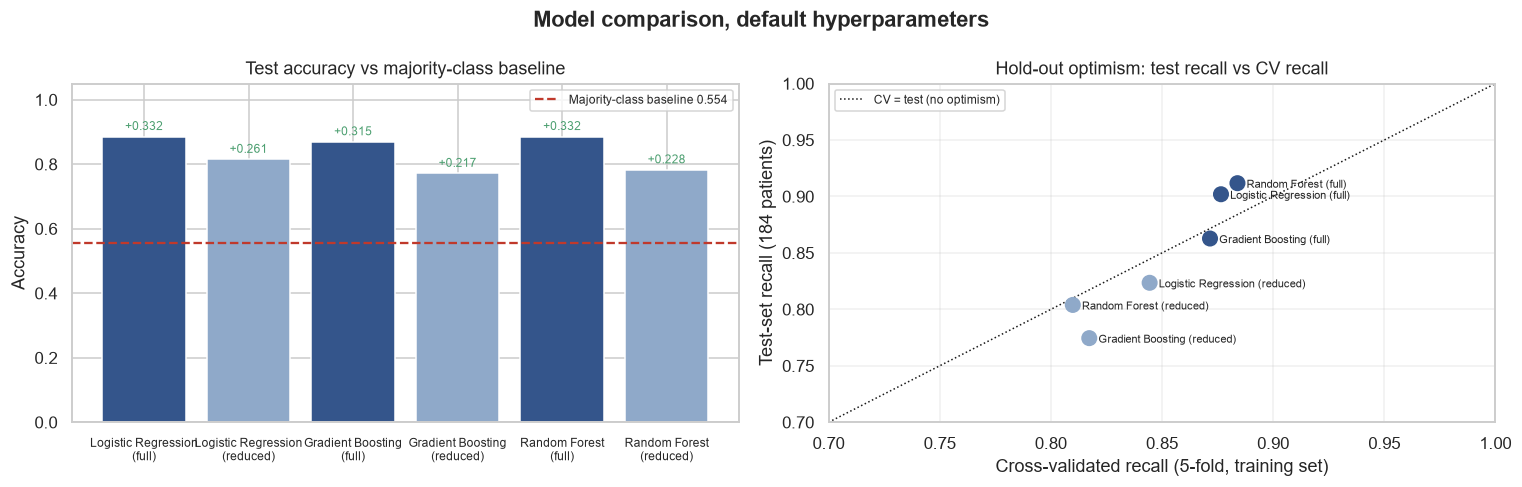

Hold-out optimism (test recall minus CV recall):
  Logistic Regression  (full   ) +0.0254  test looks better
  Logistic Regression  (reduced) -0.0209  test looks worse
  Gradient Boosting    (full   ) -0.0089  test looks worse
  Gradient Boosting    (reduced) -0.0428  test looks worse
  Random Forest        (full   ) +0.0278  test looks better
  Random Forest        (reduced) -0.0060  test looks worse

Highest cross-validated recall: Random Forest on the full feature set (0.8840)


In [26]:
## Collect every model into one table, with the baseline as the first row so that
## no score can be read without seeing what it has to beat.

## drop_duplicates guards against duplicate rows if a model cell is re-run
## without re-running 4.1, which resets the results list
comparison = pd.DataFrame(results).drop_duplicates(
    subset=["Model", "Features"], keep="last").reset_index(drop=True)

baseline_row = pd.DataFrame([{
    "Model": "Baseline (majority)", "Features": "-",
    "CV recall": np.nan, "CV std": np.nan,
    "Accuracy": BASELINE_ACCURACY, "Precision": BASELINE_ACCURACY,
    "Recall": 1.0, "F1": 2 * BASELINE_ACCURACY / (1 + BASELINE_ACCURACY),
    "ROC-AUC": 0.5,
}])

comparison = pd.concat([baseline_row, comparison], ignore_index=True)

## Gain over the baseline is the number that actually matters
comparison["Acc gain"] = comparison["Accuracy"] - BASELINE_ACCURACY

print("All models vs baseline (test set, default hyperparameters):")
display(comparison.round(4))

models = comparison[comparison["Model"] != "Baseline (majority)"]
labels = models["Model"] + "\n(" + models["Features"] + ")"
colours = ["#34558B" if f == "full" else "#8FA9C9" for f in models["Features"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

## --- Panel 1: the rubric's baseline comparison, in one chart ---
## Everything is measured against the majority-class line; the bar height above it
## is the only part attributable to the modelling.
axes[0].bar(labels, models["Accuracy"], color=colours)
axes[0].axhline(BASELINE_ACCURACY, color="#C0392B", linestyle="--",
                label=f"Majority-class baseline {BASELINE_ACCURACY:.3f}")
axes[0].set_title("Test accuracy vs majority-class baseline")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8)
for i, (acc, gain) in enumerate(zip(models["Accuracy"], models["Acc gain"])):
    axes[0].annotate(f"+{gain:.3f}", (i, acc + 0.02), ha="center", fontsize=8,
                     color="#4C9F70")

## --- Panel 2: is the hold-out score optimistic? ---
## Cross-validated recall averages 5 training folds; test recall is a single split of
## 184 patients. A model sitting well above the diagonal scored better on the hold-out
## than it did under cross-validation, which means its test figure owes something to a
## favourable split rather than to the model. This is the check that justifies relying
## on CV for selection, and it is not shown anywhere else in the notebook.
axes[1].scatter(models["CV recall"], models["Recall"], s=90,
                c=colours, zorder=3)
lims = [0.70, 1.0]
axes[1].plot(lims, lims, "k:", linewidth=1, label="CV = test (no optimism)")
for _, r in models.iterrows():
    axes[1].annotate(f"{r['Model']} ({r['Features']})",
                     (r["CV recall"], r["Recall"]), fontsize=7,
                     xytext=(6, -3), textcoords="offset points")
axes[1].set_xlim(*lims)
axes[1].set_ylim(*lims)
axes[1].set_xlabel("Cross-validated recall (5-fold, training set)")
axes[1].set_ylabel("Test-set recall (184 patients)")
axes[1].set_title("Hold-out optimism: test recall vs CV recall")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

fig.suptitle("Model comparison, default hyperparameters", fontweight="bold")
plt.tight_layout()
plt.show()

## Quantify the optimism gap rather than leaving it to the eye
print("Hold-out optimism (test recall minus CV recall):")
for _, r in models.iterrows():
    gap = r["Recall"] - r["CV recall"]
    flag = "test looks better" if gap > 0 else "test looks worse"
    print(f"  {r['Model']:20} ({r['Features']:7}) {gap:+.4f}  {flag}")

## Best model by the metric section 1 argued for
best = models.sort_values("CV recall", ascending=False).iloc[0]
print(f"\nHighest cross-validated recall: {best['Model']} on the {best['Features']} "
      f"feature set ({best['CV recall']:.4f})")

### 4.5.1 [Quantitative] Cross-validated performance across all metrics

Cross-validated metrics (5-fold, training set only):


,Model,Features,recall,precision,f1,roc_auc,accuracy,recall_std
0,Logistic Regression,full,0.8765,0.8654,0.8691,0.9290,0.8540,0.0413
1,Gradient Boosting,full,0.8716,0.8706,0.8697,0.9285,0.8554,0.0288
2,Random Forest,full,0.8840,0.8565,0.8692,0.9280,0.8527,0.0254
3,Logistic Regression,reduced,0.8444,0.7911,0.8154,0.8606,0.7898,0.0656
4,Gradient Boosting,reduced,0.8173,0.7749,0.7945,0.8415,0.7680,0.0641
5,Random Forest,reduced,0.8099,0.7819,0.7946,0.8344,0.7694,0.0510


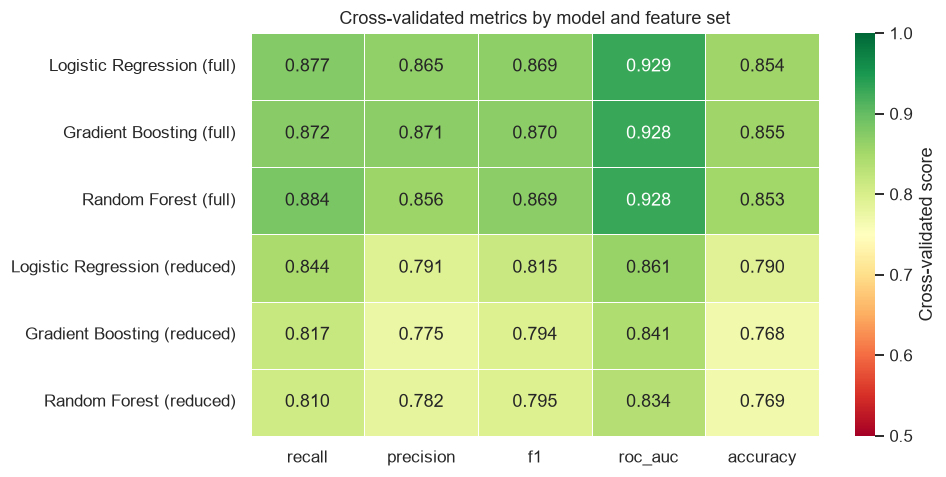

Best model per metric (cross-validated):
  recall     Random Forest (full)  0.8840
  precision  Gradient Boosting (full)  0.8706
  f1         Gradient Boosting (full)  0.8697
  roc_auc    Logistic Regression (full)  0.9290
  accuracy   Gradient Boosting (full)  0.8554


In [27]:
## The single CV recall number in 4.5 is not enough to choose between models that sit
## within noise of each other. cross_validate refits each pipeline once per fold and
## scores every metric on the same fold, so the metrics are directly comparable and
## the whole thing costs 5 fits per model rather than 5 per metric.

## Every fitted variant, paired with the training data it was built on
model_variants = {
    ("Logistic Regression", "full"):    (logreg_full,    X_train),
    ("Gradient Boosting",   "full"):    (gb_full,        X_train),
    ("Random Forest",       "full"):    (rf_full,        X_train),
    ("Logistic Regression", "reduced"): (logreg_reduced, X_train_reduced),
    ("Gradient Boosting",   "reduced"): (gb_reduced,     X_train_reduced),
    ("Random Forest",       "reduced"): (rf_reduced,     X_train_reduced),
}

scoring = ["recall", "precision", "f1", "roc_auc", "accuracy"]

cv_rows = []
fold_scores = {}       ## per-fold recall, kept for the stability plot below

for (name, fs), (pipe, X_tr) in model_variants.items():
    scores = cross_validate(pipe, X_tr, y_train, cv=CV, scoring=scoring)
    row = {"Model": name, "Features": fs}
    for m in scoring:
        row[m] = scores["test_" + m].mean()
    row["recall_std"] = scores["test_recall"].std()
    cv_rows.append(row)
    fold_scores[f"{name}\n({fs})"] = scores["test_recall"]

cv_table = pd.DataFrame(cv_rows)

print("Cross-validated metrics (5-fold, training set only):")
display(cv_table.round(4))

## Heatmap makes the trade-offs visible at a glance: which model wins which metric,
## and whether any model wins everything (none usually does).
fig, ax = plt.subplots(figsize=(9, 4.5))
heat = cv_table.set_index(cv_table["Model"] + " (" + cv_table["Features"] + ")")[scoring]
sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.5, vmax=1.0,
            linewidths=0.5, cbar_kws={"label": "Cross-validated score"}, ax=ax)
ax.set_title("Cross-validated metrics by model and feature set")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Which model wins each metric
print("Best model per metric (cross-validated):")
for m in scoring:
    best_row = cv_table.loc[cv_table[m].idxmax()]
    print(f"  {m:10} {best_row['Model']} ({best_row['Features']})  {best_row[m]:.4f}")

### 4.5.2 [Quantitative] Does the ranking survive a change of resampling seed?

Section 3.5 fixed a single 5-fold splitter with `random_state=42`, and every cross-validated figure above comes from it. A 5-fold split of 733 patients is itself a random draw, so if the ranking flips under a different seed it describes the partition rather than the models. This cell repeats the comparison across ten seeds.

CV recall by resampling seed (full feature set):


Model,Gradient Boosting,Logistic Regression,Random Forest
seed,,,
0,0.8889,0.8840,0.8840
1,0.8741,0.8815,0.8889
2,0.8914,0.8914,0.8988
3,0.8889,0.8840,0.8864
4,0.8691,0.8963,0.8864
5,0.8963,0.8815,0.8938
6,0.8815,0.8889,0.8864
7,0.8914,0.8914,0.8864
8,0.8864,0.8765,0.8815



Across the 10 seeds:


,mean,std,min,max,range
Model,,,,,
Gradient Boosting,0.8852,0.0083,0.8691,0.8963,0.0272
Logistic Regression,0.8864,0.0059,0.8765,0.8963,0.0198
Random Forest,0.8877,0.0051,0.8815,0.8988,0.0173



Highest CV recall over the 10 seeds:
  Gradient Boosting      4 outright + 1 tie
  Logistic Regression    3 outright + 1 tie
  Random Forest          2 outright
  (1 seed(s) ended in a tie)


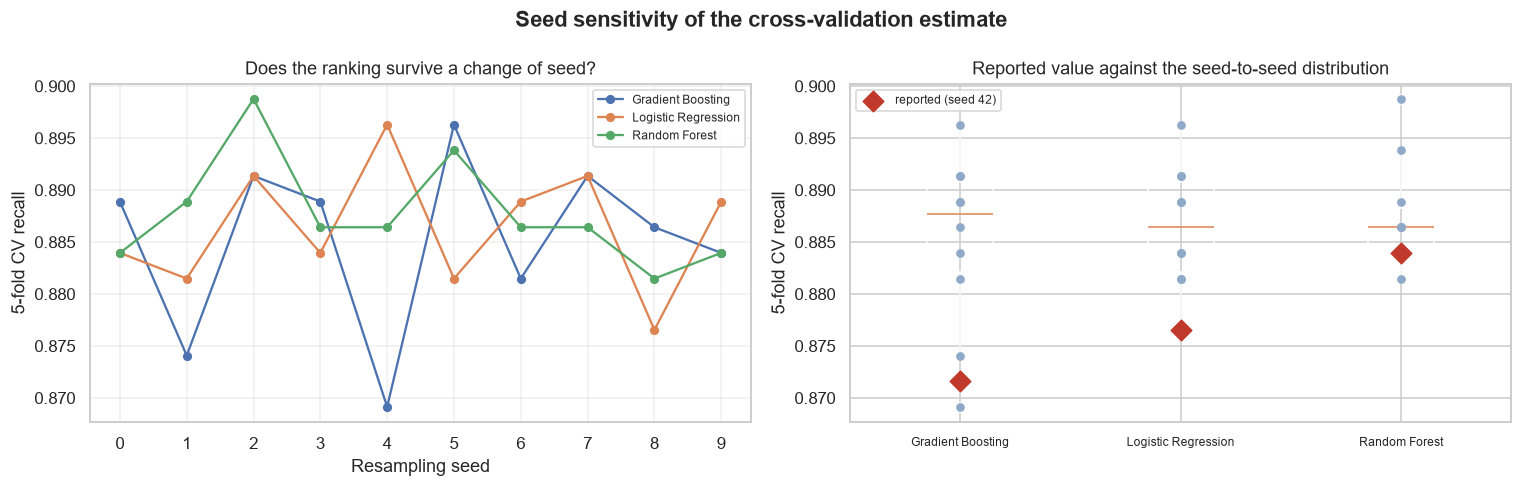

In [28]:
## Repeat the whole 5-fold comparison under 10 different partition seeds.
## Only the seed changes -- same data, same models, same fold count.

seeds = list(range(10))
seed_rows = []
for seed in seeds:
    cv_seed = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    for (name, fs), (pipe, X_tr) in model_variants.items():
        if fs != "full":
            continue
        sc = cross_val_score(pipe, X_tr, y_train, cv=cv_seed, scoring="recall")
        seed_rows.append({"seed": seed, "Model": name, "cv_recall": sc.mean()})

seed_df = pd.DataFrame(seed_rows)
pivot = seed_df.pivot(index="seed", columns="Model", values="cv_recall")

print("CV recall by resampling seed (full feature set):")
display(pivot.round(4))

print("\nAcross the 10 seeds:")
summary = pd.DataFrame({
    "mean": pivot.mean(),
    "std": pivot.std(),
    "min": pivot.min(),
    "max": pivot.max(),
    "range": pivot.max() - pivot.min(),
}).round(4)
display(summary)

## Outright wins only. idxmax silently awards a tie to whichever column comes first,
## which would overstate one model's record, so ties are counted separately.
best = pivot.max(axis=1)
outright = {m: 0 for m in pivot.columns}
tied = {m: 0 for m in pivot.columns}
n_tied_seeds = 0
for s in pivot.index:
    top = [m for m in pivot.columns if pivot.loc[s, m] == best[s]]
    if len(top) == 1:
        outright[top[0]] += 1
    else:
        n_tied_seeds += 1
        for m in top:
            tied[m] += 1

print(f"\nHighest CV recall over the {len(seeds)} seeds:")
for m in sorted(pivot.columns, key=lambda x: -outright[x]):
    extra = f" + {tied[m]} tie" if tied[m] else ""
    print(f"  {m:22} {outright[m]} outright{extra}")
print(f"  ({n_tied_seeds} seed(s) ended in a tie)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

## Panel 1: every seed, every model. Lines crossing = an unstable ranking.
for m in pivot.columns:
    axes[0].plot(pivot.index, pivot[m], marker="o", ms=5, label=m)
axes[0].set_xlabel("Resampling seed")
axes[0].set_ylabel("5-fold CV recall")
axes[0].set_title("Does the ranking survive a change of seed?")
axes[0].set_xticks(seeds)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

## Panel 2: spread per model, with the reported (seed 42) value marked
## Computed rather than hard-coded, so it cannot drift from the section 4 table.
rep_vals = {}
for (name, fs), (pipe, X_tr) in model_variants.items():
    if fs == "full":
        rep_vals[name] = cross_val_score(pipe, X_tr, y_train, cv=CV,
                                         scoring="recall").mean()
axes[1].boxplot([pivot[m] for m in pivot.columns], tick_labels=list(pivot.columns))
for j, m in enumerate(pivot.columns, start=1):
    axes[1].scatter([j] * len(pivot), pivot[m], color="#8FA9C9", s=22, zorder=3)
    if m in rep_vals:
        axes[1].scatter([j], [rep_vals[m]], color="#C0392B", s=90, marker="D",
                        zorder=4, label="reported (seed 42)" if j == 1 else "")
axes[1].set_ylabel("5-fold CV recall")
axes[1].set_title("Reported value against the seed-to-seed distribution")
axes[1].tick_params(axis="x", labelsize=8)
axes[1].legend(fontsize=8)

fig.suptitle("Seed sensitivity of the cross-validation estimate", fontweight="bold")
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 4.5.2

| Model | Mean over 10 seeds | Std | Min | Max | Highest recall |
| --- | --- | --- | --- | --- | --- |
| Random Forest | **0.8877** | **0.0051** | **0.8815** | **0.8988** | 2 outright |
| Logistic Regression | 0.8864 | 0.0059 | 0.8765 | 0.8963 | 3 outright + 1 tie |
| Gradient Boosting | 0.8852 | 0.0083 | 0.8691 | 0.8963 | 4 outright + 1 tie |

**Seed 42 is representative.** Random Forest's reported value sits inside its 0.8815–0.8988 range across seeds, slightly below the mean, so section 4 is not quoting a favourable draw.

**Win count and distribution point different ways, and the distribution is the better evidence.** Gradient Boosting takes the most outright wins but has the lowest mean, highest variance and lowest floor — winning a seed only requires being marginally ahead on that one partition. Random Forest has the highest mean, the smallest seed-to-seed standard deviation (0.0051) and the highest floor across all ten.

**Conclusion.** The three algorithms are separated by 0.0025 on mean recall, which is smaller than any one of them varies across seeds. Recall alone therefore cannot pick a winner, and 4.5.5 decides on stability and error profile instead. What this experiment does establish is that the *ordering* is not an artefact of seed 42: Random Forest is the most stable of the three under resampling, and that holds across all ten partitions.

### 4.5.3 [Quantitative] Do the models fail on the same patients?

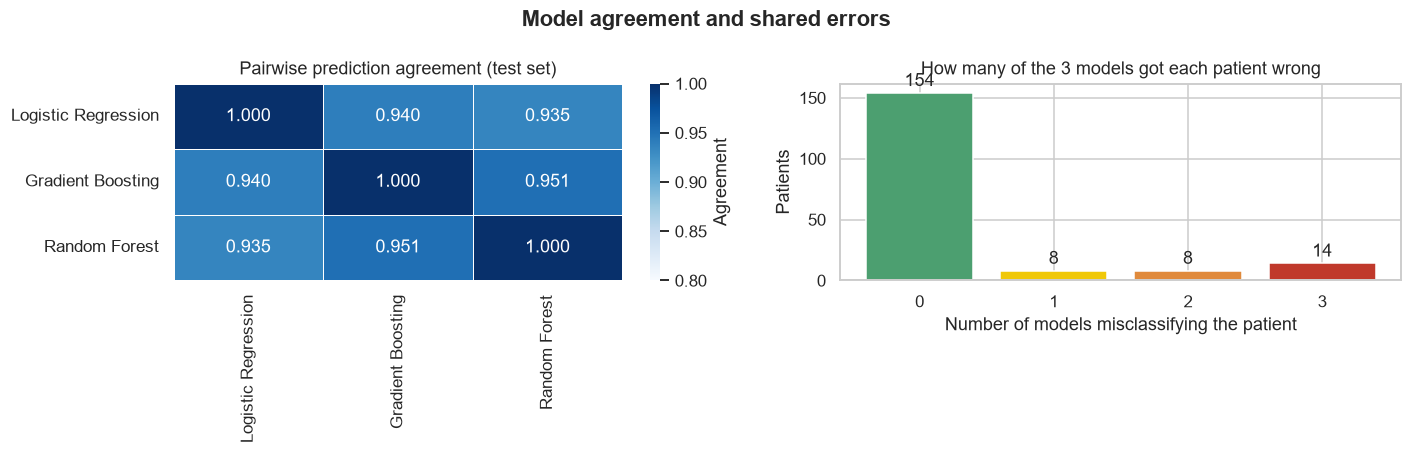

Test patients: 184
  correctly classified by all three models : 154
  misclassified by at least one model      : 30
  misclassified by ALL three models        : 14 (7.6% of the test set)

14 patients were misclassified by all three current models at their default thresholds. This shows where these three fits failed; it does
not bound what a different model or threshold could achieve.


In [29]:
## If three different algorithms misclassify the same patients, those patients are
## genuinely ambiguous given the features available -- an upper bound on what any
## model can achieve here. If they fail on different patients, the errors are
## model-specific and there is headroom left in tuning.

## Predictions from the three full-set models
preds = {
    "Logistic Regression": logreg_full.predict(X_test),
    "Gradient Boosting":   gb_full.predict(X_test),
    "Random Forest":       rf_full.predict(X_test),
}
names = list(preds)

## Pairwise agreement: proportion of test patients where two models give the same label
agree = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        agree.loc[a, b] = (preds[a] == preds[b]).mean()

## Per-patient error indicator, then how many models got each patient wrong
errors = pd.DataFrame({n: (preds[n] != y_test.values).astype(int) for n in names})
errors["n_wrong"] = errors[names].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

sns.heatmap(agree.astype(float), annot=True, fmt=".3f", cmap="Blues",
            vmin=0.8, vmax=1.0, linewidths=0.5, ax=axes[0],
            cbar_kws={"label": "Agreement"})
axes[0].set_title("Pairwise prediction agreement (test set)")

dist = errors["n_wrong"].value_counts().sort_index()
bars = axes[1].bar(dist.index.astype(str), dist.values,
                   color=["#4C9F70", "#F0C808", "#E08A3C", "#C0392B"][:len(dist)])
axes[1].set_title("How many of the 3 models got each patient wrong")
axes[1].set_xlabel("Number of models misclassifying the patient")
axes[1].set_ylabel("Patients")
axes[1].bar_label(bars, padding=2)

fig.suptitle("Model agreement and shared errors", fontweight="bold")
plt.tight_layout()
plt.show()

n_test = len(y_test)
all_wrong = int((errors["n_wrong"] == 3).sum())
any_wrong = int((errors["n_wrong"] > 0).sum())
print(f"Test patients: {n_test}")
print(f"  correctly classified by all three models : {int((errors['n_wrong'] == 0).sum())}")
print(f"  misclassified by at least one model      : {any_wrong}")
print(f"  misclassified by ALL three models        : {all_wrong} "
      f"({all_wrong / n_test * 100:.1f}% of the test set)")
print(f"\n{all_wrong} patients were misclassified by all three current models at "
      f"their default thresholds. This shows where these three fits failed; it does\n"
      f"not bound what a different model or threshold could achieve.")

### 4.5.4 [Quantitative] The cost of dropping the stress-test features

Performance lost when the stress-test features are removed (CV, percentage points):


,recall,precision,f1,roc_auc,accuracy
Model,,,,,
Logistic Regression,3.21,7.43,5.36,6.84,6.42
Gradient Boosting,5.43,9.57,7.52,8.70,8.74
Random Forest,7.41,7.45,7.45,9.36,8.33


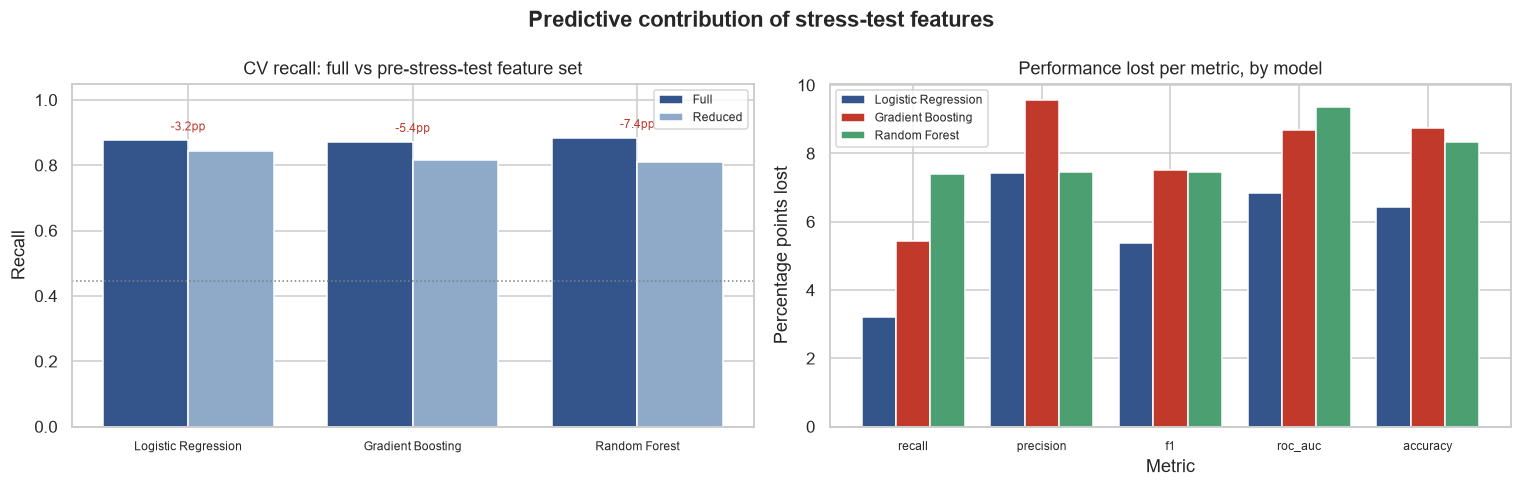

In [30]:
## Quantify the full-vs-reduced gap per model and per metric, so the predictive
## contribution of the stress-test features is a number rather than an impression.

gap_rows = []
for name in ["Logistic Regression", "Gradient Boosting", "Random Forest"]:
    f = cv_table[(cv_table["Model"] == name) & (cv_table["Features"] == "full")].iloc[0]
    r = cv_table[(cv_table["Model"] == name) & (cv_table["Features"] == "reduced")].iloc[0]
    gap_rows.append({
        "Model": name,
        **{m: f[m] - r[m] for m in scoring},
    })
gaps = pd.DataFrame(gap_rows)

print("Performance lost when the stress-test features are removed (CV, percentage points):")
display((gaps.set_index("Model") * 100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

## Paired bars: full vs reduced recall per model
x = np.arange(3)
full_r = [cv_table[(cv_table.Model == m) & (cv_table.Features == "full")]["recall"].iloc[0]
          for m in gaps["Model"]]
red_r = [cv_table[(cv_table.Model == m)
                  & (cv_table.Features == "reduced")]["recall"].iloc[0]
         for m in gaps["Model"]]
axes[0].bar(x - 0.19, full_r, 0.38, label="Full", color="#34558B")
axes[0].bar(x + 0.19, red_r, 0.38, label="Reduced", color="#8FA9C9")
axes[0].axhline(1 - y_test.mean(), color="grey", linestyle=":", linewidth=1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(gaps["Model"], fontsize=8)
axes[0].set_title("CV recall: full vs pre-stress-test feature set")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=8)
for i, (a, b) in enumerate(zip(full_r, red_r)):
    axes[0].annotate(f"-{(a - b) * 100:.1f}pp", (i, max(a, b) + 0.03),
                     ha="center", fontsize=8, color="#C0392B")

## Gap across every metric
gap_long = gaps.set_index("Model")[scoring] * 100
gap_long.T.plot(kind="bar", ax=axes[1], width=0.8,
                color=["#34558B", "#C0392B", "#4C9F70"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Performance lost per metric, by model")
axes[1].set_ylabel("Percentage points lost")
axes[1].set_xlabel("Metric")
axes[1].tick_params(axis="x", rotation=0, labelsize=8)
axes[1].legend(fontsize=8)

fig.suptitle("Predictive contribution of stress-test features", fontweight="bold")
plt.tight_layout()
plt.show()

### 4.5.5 [Qualitative] Analysis and model selection

Cross-validated on the training split, full feature set:

| Model | Recall | Precision | F1 | ROC-AUC | Accuracy | Recall std |
| --- | --- | --- | --- | --- | --- | --- |
| Random Forest | **0.8840** | 0.8565 | 0.8692 | 0.9280 | 0.8527 | **0.0254** |
| Logistic Regression | 0.8765 | 0.8654 | 0.8691 | **0.9290** | 0.8540 | 0.0413 |
| Gradient Boosting | 0.8716 | **0.8706** | **0.8697** | 0.9285 | 0.8554 | 0.0288 |

**No model wins on every metric**, and the margins are small: the three F1 scores span 0.0006 and the three AUCs 0.0010, both smaller than the fold-to-fold variation. Three algorithms of very different flexibility land within 1.3 points of each other on recall, which says the ceiling here is set by the features rather than by the algorithm.

**Gradient Boosting is excluded.** It has the lowest recall — the metric section 1 prioritises — and 4.5.4 measures it as losing the most precision and F1 when stress-test features are removed, so it is also the least robust to a thinner clinical workup.

**Random Forest is selected.** With the headline metric unable to separate the candidates, the tie is broken on stability: Random Forest has the highest mean recall and the lowest seed-to-seed variance across ten resampling seeds (4.5.2), and it is the least sensitive to the retained clinical outliers (2.3.1.2). A model whose performance moves least when the data is repartitioned is the one whose reported figure is most likely to survive deployment.

**The trade-off accepted, stated plainly.** Logistic Regression takes the nominal ROC-AUC lead (0.9290 vs 0.9280, inside noise) and is the only candidate whose coefficients read directly as a per-feature explanation. That is a real cost: the deployed tool cannot show a clinician a signed contribution per input. It is accepted because interpretability of the estimator is not the only route to a defensible recommendation — the app instead exposes the model's operating point, its subgroup failures and its held-out error counts, which is what a referring clinician needs in order to decide how much weight to give the output.

#### Full versus reduced

Cross-validated performance lost when the four stress-test features are removed:

| Model | Recall | Accuracy |
| --- | --- | --- |
| Logistic Regression | 3.21 | 6.42 |
| Gradient Boosting | 5.43 | 8.74 |
| Random Forest | 7.41 | 8.33 |

Random Forest loses the most recall, consistent with a flexible model extracting more from strong predictors. This measures predictive contribution only; it does not establish clinical or economic value. **No hyperparameters have been tuned and no threshold moved from 0.50** — these are the reference numbers section 6 is measured against.

# 5. Model Evaluation

One model was selected: Random Forest on the full feature set. This section establishes whether it is fit for the purpose set out in section 1, and where it fails. The rejected models appear alongside it in the tables and figures, because a selected model's numbers mean little without the alternatives beside them.

| | Sub-section | Question answered |
| --- | --- | --- |
| — | Evaluation metric selection | what is being optimised, and why |
| **Quantitative** | 5.1 | how many patients does each model get wrong, and which kind? |
| **Quantitative** | 5.2 | how well does each model rank risk, independent of threshold? |
| **Quantitative** | 5.3 | what does buying extra recall cost, in patients? |
| **Quantitative** | 5.4 | does performance hold across patient subgroups? |
| **Qualitative** | 5.5 | what is the model actually relying on, and will it survive deployment? |
| **Qualitative** | 5.6 | does it behave sensibly on individual patients? |
| **Qualitative** | 5.7 | summary, and the prioritised list section 6 works through |

Each quantitative sub-section is followed by a clearly marked interpretation block, so the measurement and the judgement drawn from it are never conflated.

## Evaluation metric selection

| Error | Consequence | Recoverable? |
| --- | --- | --- |
| **False negative** — diseased patient cleared | condition goes undetected and untreated | no |
| **False positive** — patient without disease flagged | further assessment that can correct it | yes |

**Recall is the primary criterion**, with precision reported beside it every time. Section 1 sets out why: this project treats a missed case as the more serious error. **Accuracy is not used as the headline** — it sums both errors at 1:1, the assumption section 1 rejects. **Recall alone is not sufficient either**: the `DummyClassifier` in 4.1 scores perfect recall by flagging every patient.

**The threshold carries the cost preference.** Hyperparameters move precision and recall together and unpredictably; the threshold on `predict_proba` trades them monotonically using one number that can be stated and varied. It is set below and revisited on training data in 6.4.

**What is evaluated here.** 4.5.5 provisionally selected Random Forest on the full feature set. It is evaluated at default hyperparameters and threshold 0.50, giving a fixed reference point. The rejected models appear alongside it.

### 5.1 [Quantitative] Detailed evaluation of the section 4 models

Random Forest (full) -- threshold 0.50
                   precision    recall  f1-score   support

   no disease (0)     0.8861    0.8537    0.8696        82
heart disease (1)     0.8857    0.9118    0.8986       102

         accuracy                         0.8859       184
        macro avg     0.8859    0.8827    0.8841       184
     weighted avg     0.8859    0.8859    0.8856       184

Logistic Regression (reduced) -- threshold 0.50
                   precision    recall  f1-score   support

   no disease (0)     0.7857    0.8049    0.7952        82
heart disease (1)     0.8400    0.8235    0.8317       102

         accuracy                         0.8152       184
        macro avg     0.8129    0.8142    0.8134       184
     weighted avg     0.8158    0.8152    0.8154       184



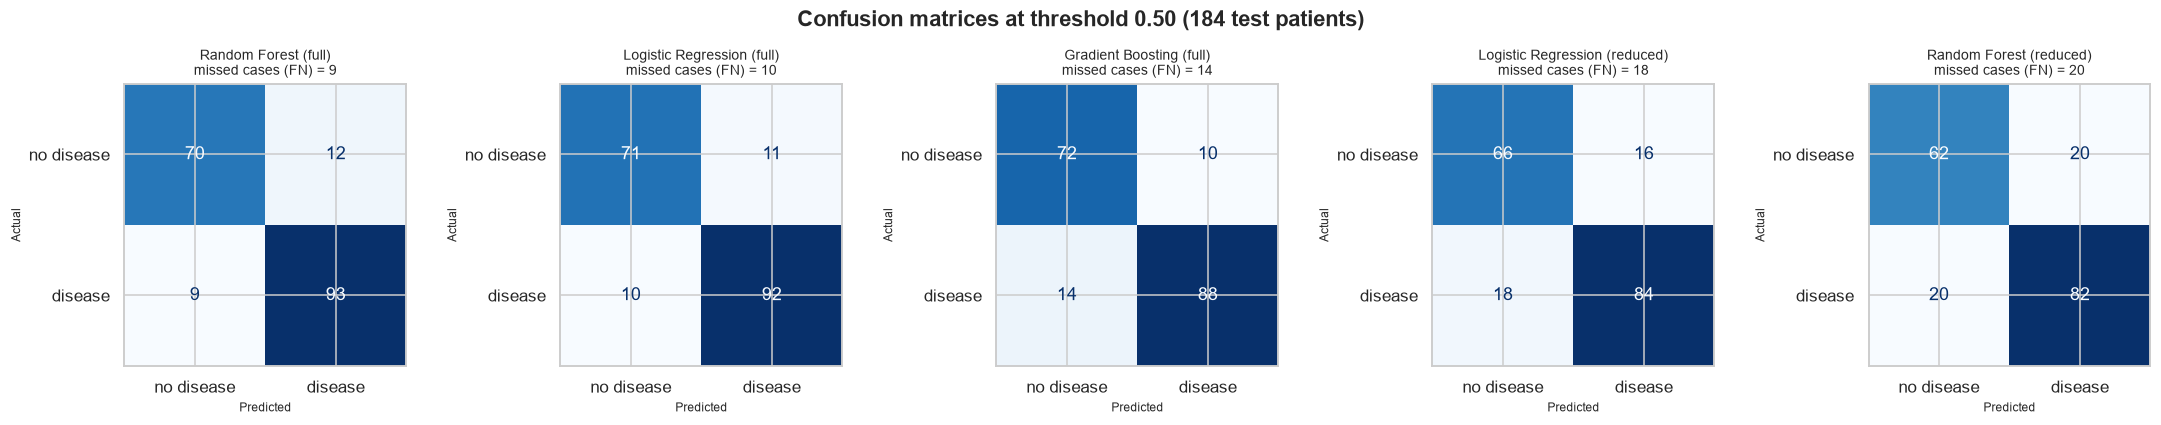

Missed cases (false negatives) out of 102 diseased patients:
  Random Forest (full)             FN =  9  |  FP = 12  |  recall 0.9118
  Logistic Regression (full)       FN = 10  |  FP = 11  |  recall 0.9020
  Gradient Boosting (full)         FN = 14  |  FP = 10  |  recall 0.8627
  Logistic Regression (reduced)    FN = 18  |  FP = 16  |  recall 0.8235
  Random Forest (reduced)          FN = 20  |  FP = 20  |  recall 0.8039


In [31]:
## Evaluate model
## The models section 4.5.5 selected, at default hyperparameters and threshold 0.50.
## This is the "before" that the iterative development section is measured against,
## so it is scored exactly the way the final model will be: fitted once on the
## training split, predicted once on the held-out test split.

## The selected model, plus the rejected alternatives for context
evaluated = {
    "Random Forest (full)":       (rf_full,        X_test),
    "Logistic Regression (full)": (logreg_full,    X_test),
    "Gradient Boosting (full)":   (gb_full,        X_test),
    "Logistic Regression (reduced)": (logreg_reduced, X_test_reduced),
    "Random Forest (reduced)":       (rf_reduced,     X_test_reduced),
}

## Classification report for the selected model and its closest rival
for label in ["Random Forest (full)", "Logistic Regression (reduced)"]:
    model, X_ev = evaluated[label]
    pred = model.predict(X_ev)
    print("=" * 68)
    print(label, "-- threshold 0.50")
    print("=" * 68)
    print(classification_report(y_test, pred, labels=[0, 1],
                                target_names=["no disease (0)", "heart disease (1)"],
                                digits=4))

## Confusion matrices for all five, so the error split is visible not just the score
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for ax, (label, (model, X_ev)) in zip(axes, evaluated.items()):
    pred = model.predict(X_ev)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=[0, 1],
        display_labels=["no disease", "disease"],
        cmap="Blues", colorbar=False, ax=ax)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    ax.set_title(f"{label}\nmissed cases (FN) = {fn}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
fig.suptitle("Confusion matrices at threshold 0.50 (184 test patients)", fontweight="bold")
plt.tight_layout()
plt.show()

## The single number that matters clinically: how many sick patients were sent home
print("Missed cases (false negatives) out of", int(y_test.sum()), "diseased patients:")
for label, (model, X_ev) in evaluated.items():
    tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_ev), labels=[0, 1]).ravel()
    print(f"  {label:32} FN = {fn:2}  |  FP = {fp:2}  |  recall {tp / (tp + fn):.4f}")

#### [Qualitative] Interpretation of 5.1

The test set holds **184 patients: 102 with heart disease, 82 without**.

| Model | TP | FN | FP | TN | Recall | Precision | Accuracy |
| --- | --: | --: | --: | --: | --: | --: | --: |
| Random Forest (full) | 93 | **9** | 12 | 70 | **0.9118** | 0.8857 | 0.8859 |
| Logistic Regression (full) | 92 | 10 | 11 | 71 | 0.9020 | 0.8932 | 0.8859 |
| Gradient Boosting (full) | 88 | 14 | **10** | 72 | 0.8627 | **0.8980** | 0.8696 |
| Logistic Regression (reduced) | 84 | 18 | 16 | 66 | 0.8235 | 0.8400 | 0.8152 |
| Random Forest (reduced) | 82 | 20 | 20 | 62 | 0.8039 | 0.8039 | 0.7826 |

**Gradient Boosting's error profile is consistent with its exclusion.** It makes the fewest false alarms of the three full-set models but misses five more diseased patients than Random Forest.

**Random Forest and Logistic Regression differ by one patient in each direction**, giving identical accuracy. On this hold-out they are very similar, and the cross-validated and seed-replicated evidence is what separates them.

**Losing stress-test data costs 8–11 additional missed patients** (Logistic Regression 10→18, Random Forest 9→20), the concrete form of the CV gap in 4.5.4.

### 5.2 [Quantitative] Threshold-independent performance: ROC and precision-recall

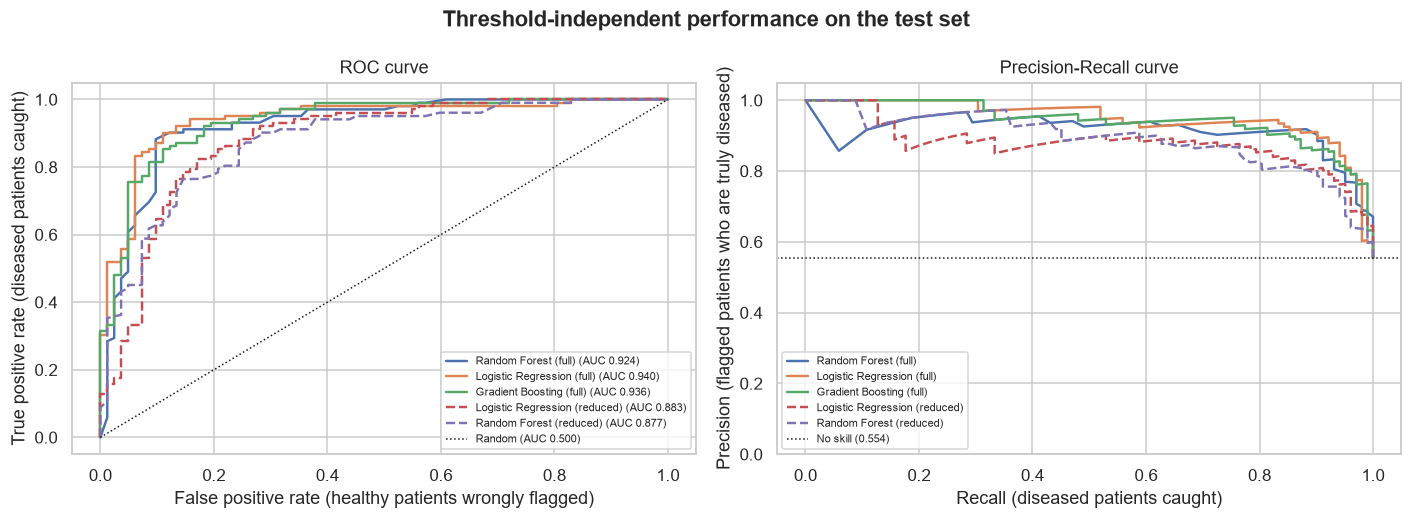

Test-set ROC-AUC:
  Random Forest (full)             0.9243
  Logistic Regression (full)       0.9396
  Gradient Boosting (full)         0.9357
  Logistic Regression (reduced)    0.8831
  Random Forest (reduced)          0.8767


In [32]:
## Accuracy, precision and recall all depend on the 0.50 cut-off. ROC and PR curves
## describe the model across every possible threshold, which is what makes them the
## right tool for deciding whether a different cut-off is worth using.
##
## The curves are drawn directly from roc_curve and precision_recall_curve rather than
## the Display helpers, because those helpers do not forward matplotlib line styling
## in every scikit-learn version. Plotting manually also lets each legend entry carry
## its own AUC, so the ranking is readable without a separate table.

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for label, (model, X_ev) in evaluated.items():
    proba = model.predict_proba(X_ev)[:, 1]
    ## solid = full feature set, dashed = reduced (pre-stress-test) feature set
    style = "-" if "full" in label else "--"

    ## ROC: false positive rate against true positive rate at every threshold
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, linestyle=style, linewidth=1.6,
                 label=f"{label} (AUC {auc:.3f})")

    ## Precision-recall: the more decision-relevant view when one class is the focus
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, linestyle=style, linewidth=1.6, label=label)

axes[0].plot([0, 1], [0, 1], "k:", linewidth=1, label="Random (AUC 0.500)")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate (healthy patients wrongly flagged)")
axes[0].set_ylabel("True positive rate (diseased patients caught)")
axes[0].legend(fontsize=7, loc="lower right")

## The no-skill line for a PR curve is the positive class prevalence, not 0.5
axes[1].axhline(y_test.mean(), color="k", linestyle=":", linewidth=1,
                label=f"No skill ({y_test.mean():.3f})")
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall (diseased patients caught)")
axes[1].set_ylabel("Precision (flagged patients who are truly diseased)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=7, loc="lower left")

fig.suptitle("Threshold-independent performance on the test set", fontweight="bold")
plt.tight_layout()
plt.show()

## Print AUC for reference against the section 4 table
print("Test-set ROC-AUC:")
for label, (model, X_ev) in evaluated.items():
    auc = roc_auc_score(y_test, model.predict_proba(X_ev)[:, 1])
    print(f"  {label:32} {auc:.4f}")

#### [Qualitative] Interpretation of 5.2

ROC-AUC measures how well a model **ranks** patients by risk, independent of where the cut-off sits, so it is the property a threshold change does not affect.

| Model | Test ROC-AUC |
| --- | --- |
| Logistic Regression (full) | **0.9396** |
| Gradient Boosting (full) | 0.9357 |
| Random Forest (full) | 0.9243 |
| Logistic Regression (reduced) | 0.8831 |
| Random Forest (reduced) | 0.8767 |

**Ranking quality does not separate the three full-set models.** They span 0.0153 on this single hold-out and 0.0010 under cross-validation, where the spread is smaller than the fold-to-fold variation. The selected model does not lead on either view, which is consistent with 4.5.5: the selection rests on recall and stability, not on discrimination, and this section confirms nothing is being given up by that choice.

**The precision-recall curve is the more decision-relevant panel**, since its no-skill line is the positive prevalence (0.554) rather than 0.5. All three full-set curves sit well above it across the operating range that matters, which is what justifies moving the threshold in 5.3 rather than accepting 0.50.

**The reduced-feature models lose roughly 0.05 AUC.** That is a statement about the summary statistic across the whole curve, and it is consistent with the per-metric gaps measured in 4.5.4.

### 5.3 [Quantitative] Choosing the decision threshold

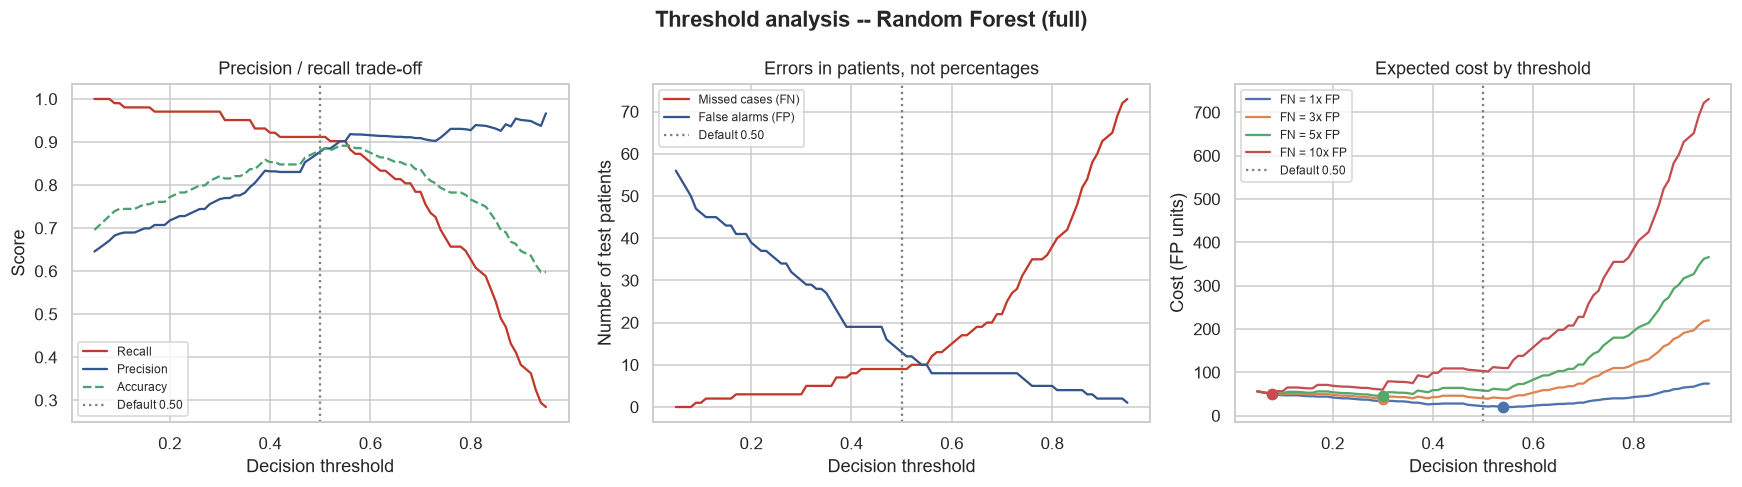

Cost-optimal threshold under different assumptions about how much worse a
missed case is than a false alarm:

  FN worth  1x FP -> threshold 0.54 | recall 0.9020 | precision 0.9020 | FN 10 | FP 10
  FN worth  3x FP -> threshold 0.30 | recall 0.9706 | precision 0.7674 | FN  3 | FP 30
  FN worth  5x FP -> threshold 0.30 | recall 0.9706 | precision 0.7674 | FN  3 | FP 30
  FN worth 10x FP -> threshold 0.08 | recall 1.0000 | precision 0.6711 | FN  0 | FP 50

Selected operating point: threshold 0.30 (FN worth 5x FP)



,Threshold 0.50 (default),Threshold 0.30 (chosen)
Recall,0.9118,0.9706
Precision,0.8857,0.7674
Missed cases (FN),9.0000,3.0000
False alarms (FP),12.0000,30.0000
Accuracy,0.8859,0.8207


In [33]:
## Price the asymmetry section 1 argues for. Expected cost = FN x cost_FN + FP, with
## cost_FP fixed at 1 so the ratio is the only free choice; the minimising threshold is
## then read off directly.

PRIMARY = "Random Forest (full)"
primary_model, primary_X = evaluated[PRIMARY]
proba = primary_model.predict_proba(primary_X)[:, 1]

thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
cost_ratios = [1, 3, 5, 10]

## Sweep every threshold once, recording the confusion counts
sweep = []
for t in thresholds:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    sweep.append({
        "threshold": t, "TP": tp, "FN": fn, "FP": fp, "TN": tn,
        "recall": tp / (tp + fn) if (tp + fn) else 0,
        "precision": tp / (tp + fp) if (tp + fp) else 0,
        "accuracy": (tp + tn) / len(y_test),
    })
sweep = pd.DataFrame(sweep)

## Expected cost under each assumed cost ratio
for r in cost_ratios:
    sweep[f"cost_{r}x"] = sweep["FN"] * r + sweep["FP"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

## Panel 1 -- precision and recall as the threshold moves
axes[0].plot(sweep["threshold"], sweep["recall"], color="#C0392B", label="Recall")
axes[0].plot(sweep["threshold"], sweep["precision"], color="#34558B", label="Precision")
axes[0].plot(sweep["threshold"], sweep["accuracy"], color="#4C9F70",
             linestyle="--", label="Accuracy")
axes[0].axvline(0.5, color="grey", linestyle=":", label="Default 0.50")
axes[0].set_title("Precision / recall trade-off")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8)

## Panel 2 -- the two error counts in absolute patients, which is how a clinic sees it
axes[1].plot(sweep["threshold"], sweep["FN"], color="#C0392B", label="Missed cases (FN)")
axes[1].plot(sweep["threshold"], sweep["FP"], color="#34558B", label="False alarms (FP)")
axes[1].axvline(0.5, color="grey", linestyle=":", label="Default 0.50")
axes[1].set_title("Errors in patients, not percentages")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Number of test patients")
axes[1].legend(fontsize=8)

## Panel 3 -- expected cost under each assumption, with the minimum marked
best_thresholds = {}
for r in cost_ratios:
    axes[2].plot(sweep["threshold"], sweep[f"cost_{r}x"], label=f"FN = {r}x FP")
    t_best = sweep.loc[sweep[f"cost_{r}x"].idxmin(), "threshold"]
    best_thresholds[r] = t_best
    axes[2].scatter([t_best], [sweep[f"cost_{r}x"].min()], s=45, zorder=3)
axes[2].axvline(0.5, color="grey", linestyle=":", label="Default 0.50")
axes[2].set_title("Expected cost by threshold")
axes[2].set_xlabel("Decision threshold")
axes[2].set_ylabel("Cost (FP units)")
axes[2].legend(fontsize=8)

fig.suptitle(f"Threshold analysis -- {PRIMARY}", fontweight="bold")
plt.tight_layout()
plt.show()

## Cost-optimal threshold under each assumption, so the choice is shown to be
## robust (or not) rather than picked to suit
print("Cost-optimal threshold under different assumptions about how much worse a")
print("missed case is than a false alarm:\n")
for r, t in best_thresholds.items():
    row = sweep[sweep["threshold"] == t].iloc[0]
    print(f"  FN worth {r:2}x FP -> threshold {t:.2f} | "
          f"recall {row['recall']:.4f} | precision {row['precision']:.4f} | "
          f"FN {int(row['FN']):2} | FP {int(row['FP']):2}")

## The chosen operating point, compared against the default.
##
## The default row is taken from predict() rather than from the sweep. The sweep uses
## `proba >= t`, but scikit-learn's forest breaks a tie at exactly 0.50 in favour of
## class 0. One test patient sits on that boundary, so the sweep row at 0.50 and the
## model's own predictions disagree by one patient. Every other section reports
## predict() output, so the comparison below uses it too.
CHOSEN_THRESHOLD = best_thresholds[5]
chosen_row = sweep[sweep["threshold"] == CHOSEN_THRESHOLD].iloc[0]

default_pred = primary_model.predict(primary_X)
d_tn, d_fp, d_fn, d_tp = confusion_matrix(y_test, default_pred, labels=[0, 1]).ravel()
default_row = {
    "recall": d_tp / (d_tp + d_fn),
    "precision": d_tp / (d_tp + d_fp),
    "FN": d_fn,
    "FP": d_fp,
    "accuracy": (d_tp + d_tn) / len(y_test),
}

print(f"\nSelected operating point: threshold {CHOSEN_THRESHOLD:.2f} (FN worth 5x FP)\n")
comparison_thr = pd.DataFrame({
    "Threshold 0.50 (default)": [default_row["recall"], default_row["precision"],
                                 int(default_row["FN"]), int(default_row["FP"]),
                                 default_row["accuracy"]],
    f"Threshold {CHOSEN_THRESHOLD:.2f} (chosen)": [chosen_row["recall"],
                                 chosen_row["precision"],
                                 int(chosen_row["FN"]), int(chosen_row["FP"]),
                                 chosen_row["accuracy"]],
}, index=["Recall", "Precision", "Missed cases (FN)", "False alarms (FP)", "Accuracy"])
display(comparison_thr.round(4))

#### [Qualitative] Interpretation of 5.3: the cost assumption

| Assumption | Threshold | Recall | Precision | Missed | False alarms |
| --- | --- | --- | --- | --- | --- |
| FN = 1× FP | 0.54 | 0.9020 | 0.9020 | 10 | 10 |
| FN = 3× FP | 0.30 | 0.9706 | 0.7674 | 3 | 30 |
| **FN = 5× FP (chosen)** | **0.30** | **0.9706** | **0.7674** | **3** | **30** |
| FN = 10× FP | 0.08 | 1.0000 | 0.6711 | 0 | 50 |

**The 5:1 weighting is an assumption**, not a value obtained from stakeholders, so the table above is a sensitivity analysis rather than a single answer. It is a well-behaved one: 3:1 and 5:1 give the same cutoff, so the choice would have to be badly wrong — 1:1 or 10:1 — before the operating point moves.

**What it buys and costs.** Against the model's own default predictions (recall 0.9118, precision 0.8857, accuracy 0.8859, 12 false alarms), missed cases fall 9 → 3 and recall rises to 0.9706. Precision falls to 0.7674 and accuracy to 0.8207, with false alarms rising 12 → 30 — roughly one in four flagged patients healthy, against one in nine before. Accuracy falling is the expected consequence of weighting the two errors unequally, not evidence against the move.

**This threshold was selected on the test set, so 0.30's performance here is optimistic.** It is re-selected on out-of-fold training probabilities in 6.4, and the figure quoted in the final deliverable comes from there.

### 5.4 [Quantitative] Subgroup performance

Random Forest (full) -- performance by sex (threshold 0.50):


,Sex,Patients,Diseased,Recall,Precision,Accuracy,Missed (FN)
0,F,42,10,0.900,0.7500,0.9048,1
1,M,142,92,0.913,0.9032,0.8803,8


Performance by chest pain type:


,ChestPainType,Patients,Diseased,Recall,Precision,Accuracy,Missed (FN)
0,ASY,94,76,0.9868,0.9146,0.9149,1
1,ATA,37,5,0.6000,0.4286,0.8378,2
2,NAP,45,17,0.8235,1.0000,0.9333,3
3,TA,8,4,0.2500,0.5000,0.5000,3


Performance by whether a lipid panel was on file:


,Cholesterol,Patients,Diseased,Recall,Precision,Accuracy,Missed (FN)
0,Measured,142,67,0.8806,0.8806,0.8873,8
1,Not measured,42,35,0.9714,0.8947,0.8810,1


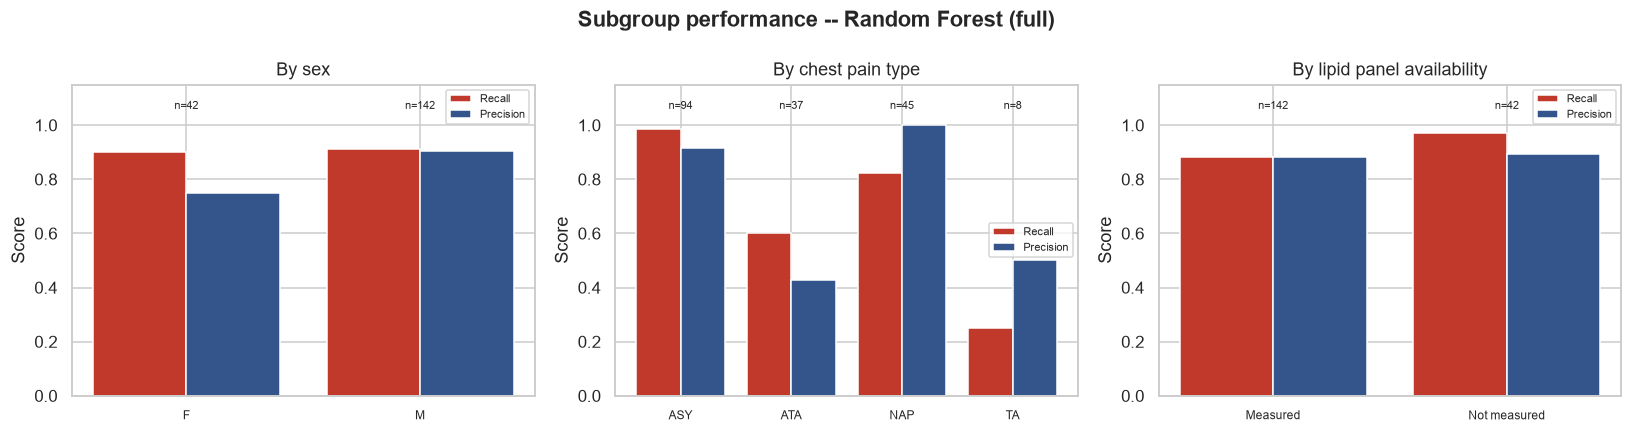

In [34]:
## Section 2.2.1 warned that with 79% male patients a headline metric mostly describes
## men. A model that scores well overall and badly on women is not a safe clinical tool,
## so the warning is tested rather than assumed.

def subgroup_report(model, X_ev, group_series, group_name):
    """Recall, precision and error counts within each level of a grouping column."""
    pred = model.predict(X_ev)
    rows = []
    for level in sorted(group_series.unique()):
        mask = (group_series == level).values
        y_g, p_g = y_test[mask], pred[mask]
        if y_g.sum() == 0:          ## no positive cases -> recall undefined
            continue
        tn, fp, fn, tp = confusion_matrix(y_g, p_g, labels=[0, 1]).ravel()
        rows.append({
            group_name: level,
            "Patients": int(mask.sum()),
            "Diseased": int(y_g.sum()),
            "Recall": tp / (tp + fn) if (tp + fn) else np.nan,
            "Precision": tp / (tp + fp) if (tp + fp) else np.nan,
            "Accuracy": (tp + tn) / len(y_g),
            "Missed (FN)": int(fn),
        })
    return pd.DataFrame(rows)

## Performance by sex, the subgroup section 2 specifically warned about
by_sex = subgroup_report(primary_model, primary_X, X_test["Sex"], "Sex")
print(f"{PRIMARY} -- performance by sex (threshold 0.50):")
display(by_sex.round(4))

## Performance by chest pain type, the feature with the most skewed distribution
by_cp = subgroup_report(primary_model, primary_X, X_test["ChestPainType"], "ChestPainType")
print("Performance by chest pain type:")
display(by_cp.round(4))

## Performance by whether cholesterol was actually measured -- the flag from 2.2.1.
## If the model performs very differently on these two groups, it is relying on the
## collection pattern rather than on physiology.
chol_group = X_test["Cholesterol_missing"].map({0: "Measured", 1: "Not measured"})
by_chol = subgroup_report(primary_model, primary_X, chol_group, "Cholesterol")
print("Performance by whether a lipid panel was on file:")
display(by_chol.round(4))

## Visualise the gaps
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (table, col, title) in zip(axes, [
    (by_sex, "Sex", "By sex"),
    (by_cp, "ChestPainType", "By chest pain type"),
    (by_chol, "Cholesterol", "By lipid panel availability"),
]):
    x = np.arange(len(table))
    ax.bar(x - 0.2, table["Recall"], 0.4, label="Recall", color="#C0392B")
    ax.bar(x + 0.2, table["Precision"], 0.4, label="Precision", color="#34558B")
    ax.set_xticks(x)
    ax.set_xticklabels(table[col], fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.set_ylabel("Score")
    for i, n in enumerate(table["Patients"]):
        ax.text(i, 1.06, f"n={n}", ha="center", fontsize=7)
    ax.legend(fontsize=7)
fig.suptitle(f"Subgroup performance -- {PRIMARY}", fontweight="bold")
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 5.4: three findings

**1. Sex does not show a usable gap.** Female recall 0.9000 (10 diseased), male 0.9130 (92) — 1.3 points apart, in the direction 2.2.1 warned about but resting on 9 of 10 patients: one more miss gives 0.8000, one more catch gives 1.0000. No action is taken on this; it is carried as a monitoring item, not a finding.

**2. The model under-flags patients presenting with classic chest pain. This is a real defect.**

| Chest pain type | Diseased | Recall | Missed |
| --- | --- | --- | --- |
| ASY (asymptomatic) | 76 | **0.9868** | 1 |
| NAP (non-anginal) | 17 | 0.8235 | 3 |
| ATA (atypical angina) | 5 | 0.6000 | 2 |
| TA (typical angina) | 4 | **0.2500** | 3 |

Grouped: 0.957 on asymptomatic and non-anginal against 0.444 on atypical and typical angina, with 5 of the 9 total misses coming from just 9 diseased patients in the symptomatic categories. The counts are small, so the *size* of the gap is uncertain — but its direction is consistent across both symptomatic levels and it has a clear cause: within this referred cohort `ASY` supplies 76 of 102 diseased patients, so the model has learned that reported chest pain is a negative signal.

This establishes a **usage constraint carried into deployment: the tool must not override clinical judgement on a symptomatic patient.** 6.5 re-tests whether iteration closes it.

**3. Performance differs by whether cholesterol was recorded.** Recall 0.9714 where no value was recorded (42 patients, 83.3% diseased) against 0.8806 where one was (142 patients, 47.2% diseased). The two groups differ in prevalence and in other ways, so this comparison does not isolate the flag — 6.1 does that directly by retraining without it.

### 5.5 [Qualitative] What drives the predictions

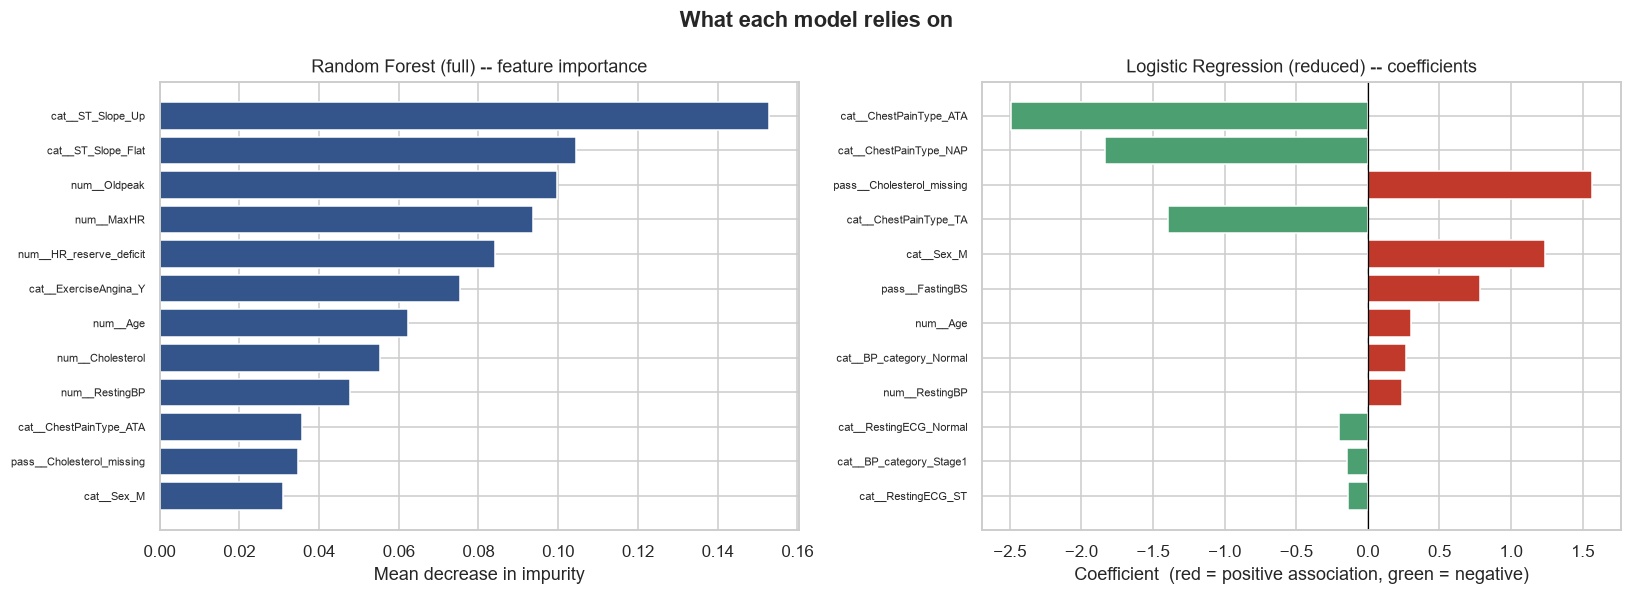

Weight carried by the Cholesterol_missing collection flag:

  Random Forest (full)         importance 0.0348  (rank 11 of 21)
  Random Forest (reduced)      importance 0.0534  (rank 7 of 14)
  Logistic Regression (full)   coefficient +1.7474
  Logistic Regression (reduced) coefficient +1.5671


In [35]:
## A clinical tool that cannot explain itself is hard to deploy. This cell extracts
## what each model relies on -- impurity-based importances for the forest, signed
## coefficients for the logistic regression -- and checks specifically how much
## weight sits on the Cholesterol_missing collection flag.

def feature_names_from(pipe):
    """Recover output column names from the fitted ColumnTransformer."""
    return pipe.named_steps["prep"].get_feature_names_out()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

## --- Random Forest (deployed model): impurity-based importance ---
rf_names = feature_names_from(rf_full)
rf_imp = pd.Series(rf_full.named_steps["model"].feature_importances_,
                   index=rf_names).sort_values(ascending=True).tail(12)
axes[0].barh(rf_imp.index, rf_imp.values, color="#34558B")
axes[0].set_title("Random Forest (full) -- feature importance")
axes[0].set_xlabel("Mean decrease in impurity")
axes[0].tick_params(axis="y", labelsize=7)

## --- Logistic Regression (control model): signed coefficients ---
lr_names = feature_names_from(logreg_reduced)
lr_coef = pd.Series(logreg_reduced.named_steps["model"].coef_[0], index=lr_names)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values().tail(12).index)
axes[1].barh(lr_top.index, lr_top.values,
             color=["#C0392B" if v > 0 else "#4C9F70" for v in lr_top.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Logistic Regression (reduced) -- coefficients")
axes[1].set_xlabel("Coefficient  (red = positive association, "
                   "green = negative)")
axes[1].tick_params(axis="y", labelsize=7)

fig.suptitle("What each model relies on", fontweight="bold")
plt.tight_layout()
plt.show()

## How much of the model rests on the data-collection flag from 2.2.1?
print("Weight carried by the Cholesterol_missing collection flag:\n")
for label, pipe, kind in [("Random Forest (full)", rf_full, "importance"),
                          ("Random Forest (reduced)", rf_reduced, "importance")]:
    names = feature_names_from(pipe)
    imp = pd.Series(pipe.named_steps["model"].feature_importances_, index=names)
    match = [n for n in names if "Cholesterol_missing" in n]
    if match:
        share = imp[match].sum()
        rank = int((imp > imp[match].sum()).sum()) + 1
        print(f"  {label:28} importance {share:.4f}  (rank {rank} of {len(names)})")

for label, pipe in [("Logistic Regression (full)", logreg_full),
                    ("Logistic Regression (reduced)", logreg_reduced)]:
    names = feature_names_from(pipe)
    coef = pd.Series(pipe.named_steps["model"].coef_[0], index=names)
    match = [n for n in names if "Cholesterol_missing" in n]
    if match:
        print(f"  {label:28} coefficient {coef[match].iloc[0]:+.4f}")

**What the models rely on.**

The right panel shows signed coefficients, so a contribution can be read off directly; the left shows which features the forest uses, but not in which direction or combination.

| Model | Weight on `Cholesterol_missing` | Rank |
| --- | --- | --- |
| Random Forest (full) | importance 0.0348 | 11th of 21 |
| Logistic Regression (full) | coefficient +1.7474 | — |

Read within each model: the forest places 3.5% of its total importance on the collection flag, ranking it 11th of 21 — not among the features it leans on. The logistic regression's +1.7474 is large relative to its own standardised coefficients. Impurity importance and regression coefficients are on different scales, so these two numbers rank the flag *within* each model and cannot be compared across them.

**The forest's low reliance is encouraging but not decisive**, because importance measures use, not necessity — a feature can rank low and still be doing work no other feature replaces. Building the flag explicitly is what made it measurable at all; 6.1 settles the question by removing it and remeasuring.

### 5.6 [Qualitative] Prediction on new patient data

In [36]:
## New data
## A worked end-to-end prediction, which is also the exact path the Streamlit app takes:
## raw patient values in, engineered features computed, pipeline applied, probability out.
## Two contrasting patients are used so the output is visibly responsive to the inputs.

def build_patient(**kwargs):
    """Assemble one patient row with the engineered features from 3.2 recomputed."""
    p = pd.DataFrame([kwargs])
    ## The same four derived features, computed identically to section 3.2
    p["Cholesterol_missing"] = int(p["Cholesterol"].iloc[0] == 0)
    p["Cholesterol"] = p["Cholesterol"].replace(0, np.nan)
    p["HR_reserve_deficit"] = (220 - p["Age"]) - p["MaxHR"]
    p["HasSTDepression"] = (p["Oldpeak"] > 0).astype(int)
    p["BP_category"] = pd.cut(p["RestingBP"], bins=[0, 120, 130, 140, np.inf],
                              labels=["Normal", "Elevated", "Stage1", "Stage2"],
                              right=False)
    return p[features_full]


## Patient A -- profile matching the high-risk pattern found in section 2:
## asymptomatic, flat ST slope, exercise angina, reduced max heart rate
patient_high = build_patient(
    Age=62, Sex="M", ChestPainType="ASY", RestingBP=150, Cholesterol=280,
    FastingBS=1, RestingECG="ST", MaxHR=110, ExerciseAngina="Y",
    Oldpeak=2.4, ST_Slope="Flat",
)

## Patient B -- low-risk profile: younger, atypical angina, upsloping ST, good HR
patient_low = build_patient(
    Age=41, Sex="F", ChestPainType="ATA", RestingBP=115, Cholesterol=190,
    FastingBS=0, RestingECG="Normal", MaxHR=172, ExerciseAngina="N",
    Oldpeak=0.0, ST_Slope="Up",
)

print(f"Predictions from {PRIMARY} at the chosen threshold "
      f"{CHOSEN_THRESHOLD:.2f}\n")

## Predict
for name, patient in [("Patient A (high-risk profile)", patient_high),
                      ("Patient B (low-risk profile)", patient_low)]:
    prob = primary_model.predict_proba(patient)[0, 1]
    flag_default = "REFER" if prob >= 0.50 else "no referral"
    flag_chosen = "REFER" if prob >= CHOSEN_THRESHOLD else "no referral"
    print(f"{name}")
    print(f"  predicted probability of heart disease : {prob:.4f}")
    print(f"  decision at default threshold 0.50     : {flag_default}")
    print(f"  decision at chosen threshold {CHOSEN_THRESHOLD:.2f}      : {flag_chosen}\n")

## The control model sees only the pre-stress-test features, so the same patients
## are scored again on the reduced model to show what a first consultation would give
print("Same patients through the control model (Logistic Regression, reduced):\n")
for name, patient in [("Patient A", patient_high), ("Patient B", patient_low)]:
    prob = logreg_reduced.predict_proba(patient[features_reduced])[0, 1]
    print(f"  {name}: probability {prob:.4f} -> "
          f"{'REFER for stress test' if prob >= 0.50 else 'no referral'}")

## --- Borderline patients: where the threshold choice actually changes an outcome ---
## Patients A and B are deliberately extreme, so both thresholds agree on them. The
## patients the 5.3 decision is really about are those whose DECISION changes -- cleared
## by the default rule, flagged by the chosen rule. This is defined by the change in
## classifier output rather than a probability window: predict() breaks a tie at exactly
## 0.50 in favour of class 0, and a "< 0.50" window would not reliably agree with that.
default_pred = primary_model.predict(primary_X)
chosen_pred = (proba >= CHOSEN_THRESHOLD).astype(int)
band = (chosen_pred == 1) & (default_pred == 0)
print(f"\nTest patients whose decision changes at threshold {CHOSEN_THRESHOLD:.2f}: "
      f"{band.sum()}")
print("Referred under the cost-adjusted rule, cleared under the default.\n")

if band.sum() > 0:
    band_df = X_test.loc[band, ["Age", "Sex", "ChestPainType", "MaxHR",
                                "Oldpeak", "ST_Slope"]].copy()
    band_df["probability"] = proba[band].round(4)
    band_df["actually_diseased"] = y_test[band].values
    band_df = band_df.sort_values("probability", ascending=False)
    display(band_df.head(15))
    if len(band_df) > 15:
        print(f"(showing the 15 highest-scoring of {len(band_df)})")
    caught = int(band_df["actually_diseased"].sum())
    print(f"Of these {len(band_df)} borderline patients, {caught} genuinely have heart "
          f"disease and would have been missed at threshold 0.50.")


Predictions from Random Forest (full) at the chosen threshold 0.30

Patient A (high-risk profile)
  predicted probability of heart disease : 0.9900
  decision at default threshold 0.50     : REFER
  decision at chosen threshold 0.30      : REFER

Patient B (low-risk profile)
  predicted probability of heart disease : 0.0400
  decision at default threshold 0.50     : no referral
  decision at chosen threshold 0.30      : no referral

Same patients through the control model (Logistic Regression, reduced):

  Patient A: probability 0.9133 -> REFER for stress test
  Patient B: probability 0.0368 -> no referral

Test patients whose decision changes at threshold 0.30: 24
Referred under the cost-adjusted rule, cleared under the default.



,Age,Sex,ChestPainType,MaxHR,Oldpeak,ST_Slope,probability,actually_diseased
742,52,F,NAP,169,0.1,Flat,0.50,0
310,65,M,ASY,154,1.0,Up,0.49,0
802,52,M,ASY,147,0.1,Up,0.48,0
892,39,F,NAP,152,0.0,Flat,0.47,0
636,48,M,ATA,180,0.2,Flat,0.46,0
656,62,F,ASY,163,0.0,Up,0.46,0
868,51,M,NAP,123,0.6,Up,0.46,0
1,49,F,NAP,156,1.0,Flat,0.41,1
482,67,M,TA,125,2.5,Up,0.39,1
698,41,M,NAP,168,2.0,Flat,0.38,0


(showing the 15 highest-scoring of 24)
Of these 24 borderline patients, 6 genuinely have heart disease and would have been missed at threshold 0.50.


**What this demonstrates.**

The two patients are built from the risk patterns identified in section 2: Patient A carries asymptomatic presentation, flat ST slope, exercise-induced angina, ST depression and reduced maximum heart rate; Patient B the inverse. They score 0.9900 and 0.0400, and both feature sets agree — the sanity check this cell exists for.

**The band between thresholds is where the decision bites.** Patients A and B are deliberately extreme, so 0.30 and 0.50 agree on both. The patients the threshold governs are those the default rule clears and the chosen rule flags — defined by the change in decision rather than a probability window, so a patient at exactly 0.50 is not silently excluded.

**24 test patient decisions change at the chosen threshold: 6 diseased patients newly caught, 18 additional false alarms.** That reconciles with 5.3: false negatives fall from 9 to 3 (a difference of 6) and false alarms rise from 12 to 30 (a difference of 18).

**This function is the contract with the deployment.** The app collects the same raw fields and recomputes the engineered features as 3.2 defines them. Imputation and encoding are fitted steps inside the pipeline, so those cannot drift; the derived features are the app's responsibility and are where a mismatch could occur.

## 5.7 [Qualitative] Summary and priorities for iteration

**Where the model stands.** Random Forest on 15 features, default hyperparameters, threshold 0.50: recall 0.9118, precision 0.8857, accuracy 0.8859 — 9 missed cases and 12 false alarms out of 184 test patients, against a majority-class baseline of 0.5543. It beats the baseline by 33 accuracy points and ranks risk well (AUC 0.9243). It is a working model, and 5.1–5.6 identified four specific things wrong with it.

**Prioritised list, in the order section 6 addresses them.**

| Priority | Problem | Evidence | Why it matters |
| --- | --- | --- | --- |
| 1 | The model carries `Cholesterol_missing`, a feature that records whether a lipid panel was drawn rather than anything about the patient | 5.5: importance 0.0348, 11th of 21; 5.4: recall differs by 9 points between recorded and unrecorded groups | A recording practice specific to this merged dataset is the most likely thing to break on a different cohort. Retrain without it and measure. |
| 2 | 15 features when the ranking is heavily top-loaded | 5.5 importance plot; 3.3 noted no statistical selection was attempted | Fewer inputs mean less data collection per patient. Worth doing only if recall survives. |
| 3 | No hyperparameter has been tuned | 4.5.5: all results at scikit-learn defaults | An unconstrained forest grows to purity; depth regularisation is untested. |
| 4 | The threshold was chosen by sweeping the test set | 5.3, stated there | The reported performance at 0.30 is optimistic. Re-select on out-of-fold training probabilities. |
| — | The model under-flags symptomatic patients (recall 0.444 on ATA/TA against 0.957 elsewhere) | 5.4 | Not a fix but a re-check: after 1–4, confirm whether the gap moved. It becomes a usage constraint either way. |

**Not on the list, and why.** The sex gap (5.4, finding 1) rests on 10 diseased female patients and is 1.3 points wide — no action is defensible on that sample. Class rebalancing is not attempted: the ratio is 1.24 : 1, and resampling would distort the predicted probabilities the threshold selection in 6.4 depends on. Switching algorithms is not revisited: 4.5.2 showed the three candidates separated by less than their own seed-to-seed variation, so a swap would be noise-chasing.

# 6. Iterative Model Development

Section 5.7 closed with a prioritised list of what to fix. This section works through it in order, and each step is measured against the section 5 numbers rather than declared an improvement.

| Step | What section 5 asked for | Raised in |
| --- | --- | --- |
| 6.1 | retrain without `Cholesterol_missing` and compare performance | 5.5 |
| 6.2 | reduce the feature set if it can be done without losing recall | 3.3 |
| 6.3 | tune hyperparameters | 4.5.3 |
| 6.4 | re-select the decision threshold inside the training set | 5.3 |
| 6.5 | re-check the symptomatic-patient failure after all changes | 5.4 |
| 6.6 | persist the final model for the Streamlit app | deployment |
| 6.7 | summarise what iteration changed, and what it did not | — |

**Two rules apply throughout.** Every decision in this section is made on the training split using cross-validation; no threshold, feature set or hyperparameter is chosen by consulting test-set performance. And the comparison baseline is fixed in advance: every "after" number is set against the pre-iteration model on the same split, reported whether it helps or not.

Test-set independence is partial, and 6.7 limitation 7 records exactly how: sections 4 and 5 reported test metrics that shaped what this section investigates. The 6.5 figures are a fair before/after comparison under an identical protocol.

**Carried in:** Random Forest, default hyperparameters, full 15-feature set, 9 missed cases of 102 at threshold 0.50. A full run takes about a minute.

## 6.1 [Quantitative] Ablation: removing the `Cholesterol_missing` collection flag

Section 5.5 measured how much each model leans on `Cholesterol_missing`, the flag that records whether a lipid panel exists rather than anything about the patient. Random Forest ranked it 11th of 21 features (importance 0.0348); Logistic Regression gave it a large positive coefficient on both feature sets.

Section 5.4 then measured a consequence: restricting to the 142 test patients with a recorded cholesterol gives a recall of 0.8806.

**Neither of those measurements answers the question that matters for deployment**, which is what happens if the flag is removed entirely. That figure holds the model fixed and changes the population; this ablation changes the model. Those differ, because a model trained without the flag can redistribute that weight onto genuine clinical features rather than simply losing it.

The selected model is retrained without the flag, on both feature sets, and compared on cross-validated recall, so the comparison is not decided by one favourable split.

Cross-validated performance with and without Cholesterol_missing:


,Feature set,Flag,n_features,recall,recall_std,precision,f1,accuracy
0,Full (deployed),with flag,15,0.8840,0.0254,0.8565,0.8692,0.8527
1,Full (deployed),without flag,14,0.8790,0.0181,0.8472,0.8622,0.8445
2,Reduced (control),with flag,9,0.8099,0.0510,0.7819,0.7946,0.7694
3,Reduced (control),without flag,8,0.8148,0.0374,0.7705,0.7911,0.7626


Effect of removing the flag (percentage points, CV):
  Full (deployed)    recall -0.49  precision -0.92  accuracy -0.82
  Reduced (control)  recall +0.49  precision -1.15  accuracy -0.68


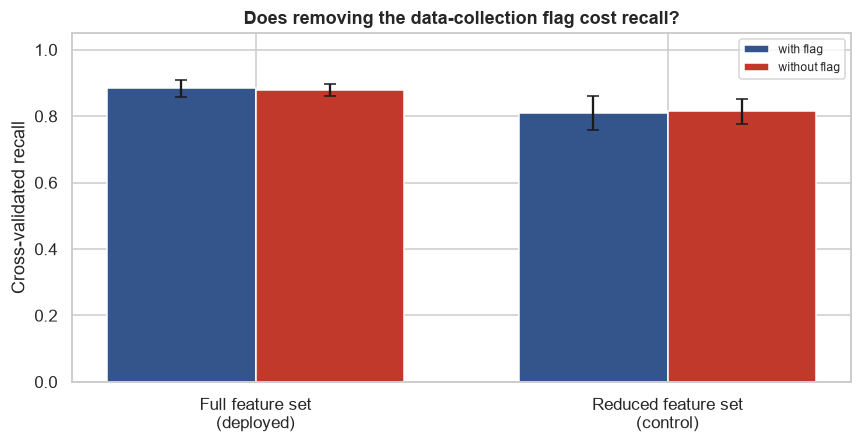


Recall cost of removing the flag (deployed model)    : +0.0049
One standard deviation of its CV recall          : 0.0254
Decision: DROP the flag (cost is within CV noise)


In [37]:
## Ablation: does removing the collection flag cost real performance?
## Everything is cross-validated on the training split. The pipeline is rebuilt from
## scratch for each feature list so the preprocessor never carries state between runs.

## The two feature sets, with and without the collection flag
features_full_noflag = [f for f in features_full if f != "Cholesterol_missing"]
features_reduced_noflag = [f for f in features_reduced if f != "Cholesterol_missing"]

def make_pipeline(model_name, feature_list):
    """Build a fresh pipeline for the given model and feature list."""
    if model_name == "Random Forest":
        return Pipeline([("prep", build_preprocessor(feature_list, scale_numeric=False)),
                         ("model", RandomForestClassifier(random_state=42))])
    return Pipeline([("prep", build_preprocessor(feature_list, scale_numeric=True)),
                     ("model", LogisticRegression(max_iter=1000, random_state=42))])

def cv_report(model_name, feature_list, X_source):
    """Cross-validated recall and precision on the training split only."""
    pipe = make_pipeline(model_name, feature_list)
    scores = cross_validate(pipe, X_source[feature_list], y_train, cv=CV,
                            scoring=["recall", "precision", "f1", "accuracy"])
    return {
        "recall": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "precision": scores["test_precision"].mean(),
        "f1": scores["test_f1"].mean(),
        "accuracy": scores["test_accuracy"].mean(),
    }

## The deployed model is Random Forest on the full feature set. The reduced set is
## included here as a control: if the flag matters more without stress-test features,
## that tells us the flag is standing in for information those features would supply.
ablation = []
for label_set, feats_with, feats_without in [
    ("Full (deployed)", features_full, features_full_noflag),
    ("Reduced (control)", features_reduced, features_reduced_noflag),
]:
    for label, feats in [("with flag", feats_with), ("without flag", feats_without)]:
        r = cv_report("Random Forest", feats, X_train)
        r.update({"Feature set": label_set, "Flag": label, "n_features": len(feats)})
        ablation.append(r)

ablation = pd.DataFrame(ablation)[
    ["Feature set", "Flag", "n_features", "recall", "recall_std",
     "precision", "f1", "accuracy"]]

print("Cross-validated performance with and without Cholesterol_missing:")
display(ablation.round(4))

## The change, stated as the difference rather than left for the reader to subtract
print("Effect of removing the flag (percentage points, CV):")
for fs in ["Full (deployed)", "Reduced (control)"]:
    sub = ablation[ablation["Feature set"] == fs]
    a = sub[sub["Flag"] == "with flag"].iloc[0]
    b = sub[sub["Flag"] == "without flag"].iloc[0]
    print(f"  {fs:18} recall {(b['recall'] - a['recall']) * 100:+.2f}  "
          f"precision {(b['precision'] - a['precision']) * 100:+.2f}  "
          f"accuracy {(b['accuracy'] - a['accuracy']) * 100:+.2f}")

## Visualise, with the fold-to-fold standard deviation as error bars so a change
## smaller than the noise cannot be mistaken for a result
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(2)
for k, flag in enumerate(["with flag", "without flag"]):
    sub = ablation[ablation["Flag"] == flag]
    ax.bar(x + (k - 0.5) * 0.36, sub["recall"], 0.36,
           yerr=sub["recall_std"], capsize=4, label=flag,
           color=["#34558B", "#C0392B"][k])
ax.set_xticks(x)
ax.set_xticklabels(["Full feature set\n(deployed)",
                    "Reduced feature set\n(control)"])
ax.set_ylabel("Cross-validated recall")
ax.set_ylim(0, 1.05)
ax.set_title("Does removing the data-collection flag cost recall?",
             fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Apply the rule fixed in the markdown above, in code rather than by eye:
## drop the flag unless removing it costs more than one standard deviation of CV recall.
deployed = ablation[ablation["Feature set"] == "Full (deployed)"]
a = deployed[deployed["Flag"] == "with flag"].iloc[0]
b = deployed[deployed["Flag"] == "without flag"].iloc[0]
cost = a["recall"] - b["recall"]

DROP_FLAG = bool(cost <= a["recall_std"])

print(f"\nRecall cost of removing the flag (deployed model)    : {cost:+.4f}")
print(f"One standard deviation of its CV recall          : {a['recall_std']:.4f}")
print(f"Decision: {'DROP the flag' if DROP_FLAG else 'KEEP the flag'} "
      f"({'cost is within CV noise' if DROP_FLAG else 'cost exceeds CV noise'})")

#### [Qualitative] Interpretation of 6.1

**The rule is fixed before the numbers:** the flag is dropped unless removing it costs more than one standard deviation of cross-validated recall. The reasoning is that the flag encodes whether a value was recorded in this dataset, which is a property of these records rather than of a patient — so its usefulness here may not transfer.

**The control.** If the flag mattered *more* without stress-test features, that would suggest it substitutes for information those features supply. It does not: removing it costs the full set 0.49 percentage points and *gains* 0.49 on the reduced set.

**The decision.** The cost is 0.0049 against a fold standard deviation of 0.0254, so the flag is dropped. Removing it also tightens the fold spread from 0.0254 to 0.0181. This ablation is the direct evidence on the flag; the subgroup comparisons elsewhere are consistent with it but do not isolate its effect.

## 6.2 [Quantitative] Feature selection

Section 3.3 deliberately performed no statistical feature selection, on the grounds that 15 features is small and section 2.3.2 found no predictor pair above |r| = 0.38. That reasoning was about *redundancy*. It did not test whether some features contribute nothing at all.

Two independent rankings are used, because agreement between different methods is stronger evidence than either alone:

1. **Random Forest impurity importance** — model-based, sees interactions between features.
2. **Logistic Regression absolute coefficient** — linear and signed, computed on scaled features so magnitudes are comparable.

Both are computed on the **training split only**. Ranking on the full dataset would let test rows influence which features exist, which is leakage by a slower route.

**How many features survive is also decided on the training split**, by cross-validating each candidate set size and applying the one-standard-error rule: keep the smallest feature set whose cross-validated score reaches within one standard error of the best seen. Choosing the size by re-scoring the test set would make the before/after comparison in 6.5 meaningless.

**The cut is made on F1, not recall, and this is a deliberate correction.** Recall is the headline metric everywhere else in this notebook, but it is the wrong criterion *for choosing how many features to keep*, for the reason first established in 4.1: recall alone is gameable. Removing features makes a model less discriminative, so it predicts the positive class more often — which drives recall up while making the model worse. A recall-driven one-standard-error rule would collapse toward a tiny feature set for precisely the wrong reason, and would then look like a success. F1 penalises the precision such a model gives away, so it measures what the rule is meant to measure: whether a smaller feature set is genuinely no worse. The right-hand panel below plots both curves so the divergence is visible rather than asserted.

Feature ranking (training split, two ranking methods):


,rf_importance,lr_abs_coef,rf_rank,lr_rank,mean_rank
ST_Slope,0.2612,2.3868,1.0,2.0,1.5
ChestPainType,0.0758,4.4152,5.0,1.0,3.0
Oldpeak,0.0966,0.7150,2.0,8.0,5.0
ExerciseAngina,0.0697,0.9400,6.0,6.0,6.0
Sex,0.0347,1.3399,10.0,3.0,6.5
MaxHR,0.0938,0.1555,3.0,11.0,7.0
FastingBS,0.0233,1.2531,13.0,4.0,8.5
Age,0.0632,0.1592,7.0,10.0,8.5
HasSTDepression,0.0244,1.1184,12.0,5.0,8.5
HR_reserve_deficit,0.0887,0.1050,4.0,13.0,8.5


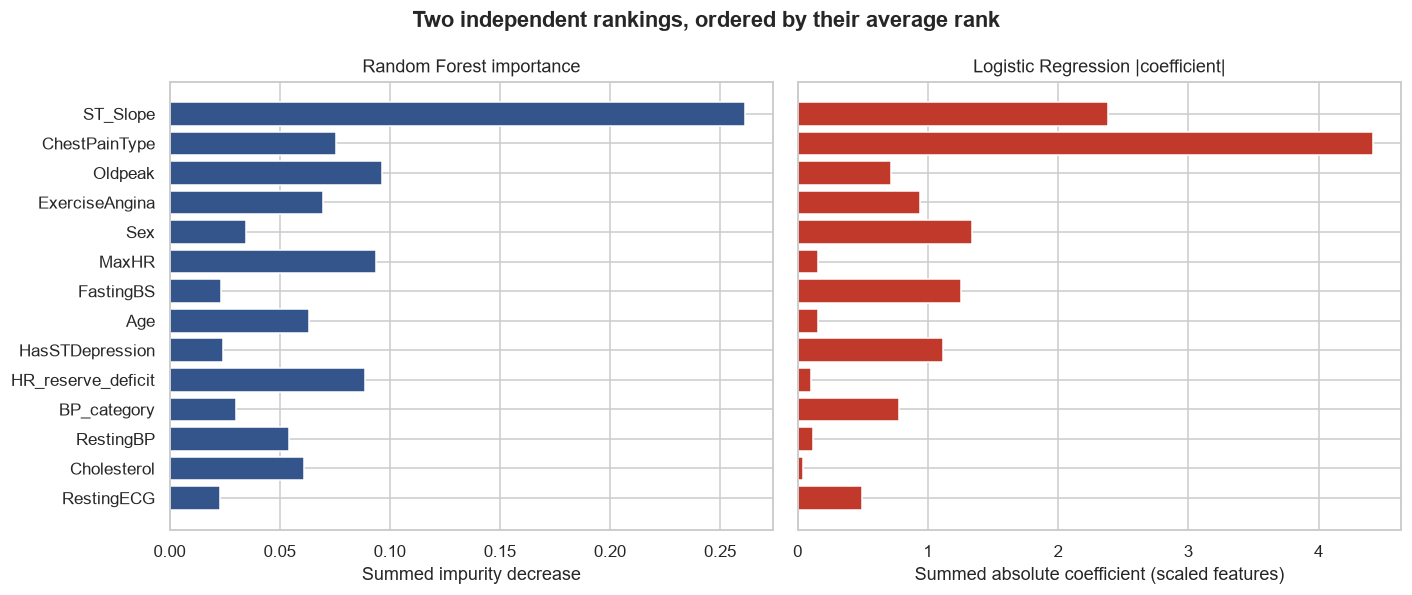

In [38]:
## Rank features by two ranking methods, then let cross-validation choose how many
## to keep. All computed on the training split.

## Start from whichever feature set 6.1 selected. MODEL_FEATURES is the candidate pool
## for the one deployed model; the reduced set is retained only so the sweep below can
## show how the curve behaves without stress-test data.
MODEL_FEATURES = features_full_noflag if DROP_FLAG else features_full
CONTROL_FEATURES = features_reduced_noflag if DROP_FLAG else features_reduced

## Fit both rankers once on the full training data
rf_rank_pipe = make_pipeline("Random Forest", MODEL_FEATURES).fit(
    X_train[MODEL_FEATURES], y_train)
lr_rank_pipe = make_pipeline("Logistic Regression", MODEL_FEATURES).fit(
    X_train[MODEL_FEATURES], y_train)

## Both operate on the encoded columns, so importances are mapped back to the original
## feature by summing over that feature's one-hot columns. Without this step a
## categorical split across four dummy columns would look weaker than a numeric one.
encoded_names = rf_rank_pipe.named_steps["prep"].get_feature_names_out()
rf_imp = pd.Series(rf_rank_pipe.named_steps["model"].feature_importances_,
                   index=encoded_names)
lr_coef = pd.Series(np.abs(lr_rank_pipe.named_steps["model"].coef_[0]),
                    index=encoded_names)


def collapse_to_original(series, feature_list):
    """Sum encoded-column scores back onto the original feature they came from."""
    out = {}
    for f in feature_list:
        cols = [c for c in series.index if c.split("__")[-1].startswith(f)]
        out[f] = series[cols].sum() if cols else 0.0
    return pd.Series(out)


ranking = pd.DataFrame({
    "rf_importance": collapse_to_original(rf_imp, MODEL_FEATURES),
    "lr_abs_coef": collapse_to_original(lr_coef, MODEL_FEATURES),
})
ranking["rf_rank"] = ranking["rf_importance"].rank(ascending=False)
ranking["lr_rank"] = ranking["lr_abs_coef"].rank(ascending=False)
ranking["mean_rank"] = ranking[["rf_rank", "lr_rank"]].mean(axis=1)
ranking = ranking.sort_values("mean_rank")

print("Feature ranking (training split, two ranking methods):")
display(ranking.round(4))

## Plot both rankings in the same feature order, so agreement is read vertically
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
order = ranking.index[::-1]
axes[0].barh(order, ranking.loc[order, "rf_importance"], color="#34558B")
axes[0].set_title("Random Forest importance")
axes[0].set_xlabel("Summed impurity decrease")
axes[1].barh(order, ranking.loc[order, "lr_abs_coef"], color="#C0392B")
axes[1].set_title("Logistic Regression |coefficient|")
axes[1].set_xlabel("Summed absolute coefficient (scaled features)")
fig.suptitle("Two independent rankings, ordered by their average rank",
             fontweight="bold")
plt.tight_layout()
plt.show()

Best CV F1 0.8668 at k=13 (SE 0.0098)
  CV recall at that k: 0.8815
One-SE rule keeps k = 9 features:
   1. ST_Slope
   2. ChestPainType
   3. Oldpeak
   4. ExerciseAngina
   5. Sex
   6. MaxHR
   7. FastingBS
   8. Age
   9. HasSTDepression


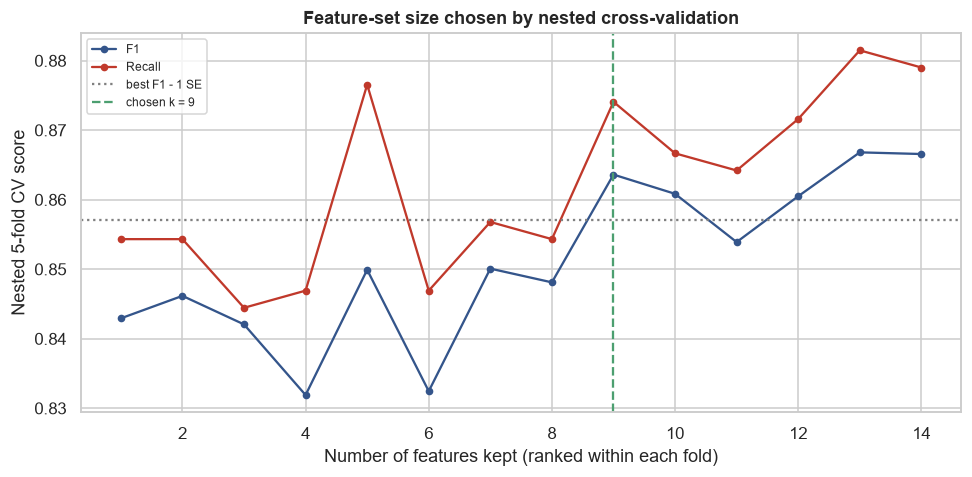

In [39]:
## How many features to keep -- decided by nested cross-validation.
##
## Ranking once on the whole training set and then cross-validating the resulting
## feature sets leaks: the ranking has already seen every validation fold, so the
## scores below would be optimistic. Instead the ranking is recomputed INSIDE each
## fold, on that fold's training portion only, and scored on its held-out portion.
## The ranking printed above is still reported, because it is what the final model
## uses once k is fixed -- but it plays no part in choosing k.

def rank_features(X_fit, y_fit, feature_list):
    """Average the two rankings, using only the rows passed in."""
    rf_p = make_pipeline("Random Forest", feature_list).fit(X_fit[feature_list], y_fit)
    lr_p = make_pipeline("Logistic Regression", feature_list)
    lr_p.fit(X_fit[feature_list], y_fit)
    names = rf_p.named_steps["prep"].get_feature_names_out()
    imp = collapse_to_original(
        pd.Series(rf_p.named_steps["model"].feature_importances_, index=names),
        feature_list)
    coef = collapse_to_original(
        pd.Series(np.abs(lr_p.named_steps["model"].coef_[0]), index=names),
        feature_list)
    avg = (imp.rank(ascending=False) + coef.rank(ascending=False)) / 2
    return list(avg.sort_values().index)


ks = range(1, len(MODEL_FEATURES) + 1)
fold_scores_k = {k: {"recall": [], "f1": []} for k in ks}

for train_idx, val_idx in CV.split(X_train, y_train):
    X_fit, y_fit = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

    ## ranking derived from this fold's training rows only
    fold_order = rank_features(X_fit, y_fit, MODEL_FEATURES)

    for k in ks:
        cols = fold_order[:k]
        pipe = make_pipeline("Random Forest", cols).fit(X_fit[cols], y_fit)
        pred = pipe.predict(X_val[cols])
        fold_scores_k[k]["recall"].append(recall_score(y_val, pred, zero_division=0))
        fold_scores_k[k]["f1"].append(f1_score(y_val, pred, zero_division=0))

fsweep = pd.DataFrame([{
    "k": k,
    "cv_recall": np.mean(v["recall"]),
    "cv_f1": np.mean(v["f1"]),
    "cv_f1_se": np.std(v["f1"], ddof=1) / np.sqrt(CV.get_n_splits()),
} for k, v in fold_scores_k.items()])


def smallest_k_within_1se(frame, col="cv_f1", se_col="cv_f1_se"):
    """One-standard-error rule: of every k reaching (best - 1 SE of the best),
    take the smallest. The cut is made on F1, NOT recall, because recall is
    gameable -- dropping features makes a model less discriminative, so it predicts
    the positive class more often and recall rises while the model gets worse."""
    best = frame.loc[frame[col].idxmax()]
    ok = frame[frame[col] >= best[col] - best[se_col]]
    return int(ok["k"].min()), best


K_SELECTED, best_point = smallest_k_within_1se(fsweep)

## With k now fixed by a procedure that never saw a validation fold's ranking, the
## final feature set is taken from the full-training-set ranking computed above.
SELECTED_FEATURES = list(ranking.index)[:K_SELECTED]

print(f"Best CV F1 {best_point['cv_f1']:.4f} at k={int(best_point['k'])} "
      f"(SE {best_point['cv_f1_se']:.4f})")
print(f"  CV recall at that k: {best_point['cv_recall']:.4f}")
print(f"One-SE rule keeps k = {K_SELECTED} features:")
for n, f in enumerate(SELECTED_FEATURES, 1):
    print(f"  {n:2}. {f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fsweep["k"], fsweep["cv_f1"], marker="o", ms=4, color="#34558B", label="F1")
ax.plot(fsweep["k"], fsweep["cv_recall"], marker="o", ms=4, color="#C0392B",
        label="Recall")
ax.axhline(best_point["cv_f1"] - best_point["cv_f1_se"], ls=":", c="grey",
           label="best F1 - 1 SE")
ax.axvline(K_SELECTED, ls="--", c="#4C9F70", label=f"chosen k = {K_SELECTED}")
ax.set_xlabel("Number of features kept (ranked within each fold)")
ax.set_ylabel("Nested 5-fold CV score")
ax.set_title("Feature-set size chosen by nested cross-validation",
             fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 6.2

**Fold-wise ranking removes the obvious leak.** Ranking once on the whole training set and then cross-validating the resulting feature sets would let the ranking see every validation fold. Here it is recomputed inside each fold on that fold's training rows only. `k` is still chosen by comparing scores across those same outer folds, so the score *at* the selected `k` is a selection score, not a clean estimate — which is why 6.5 re-measures the effect on the test set instead of quoting this number.

**The one-standard-error rule.** Best CV F1 is 0.8668 at k=13 with a standard error of 0.0098; the smallest `k` within one standard error is **9**. The cut is made on F1 rather than recall because recall can be raised by a model that simply flags more patients — the failure mode 4.1 demonstrated with the `DummyClassifier`.

**Two rankings, agreed.** Impurity importance is biased toward features with many split points and summed absolute coefficients favour categoricals with more dummy columns, so each is biased in a different direction. Requiring a feature to look useful under both is what makes the combined ranking usable despite that: the two biases do not overlap, so a feature surviving both is unlikely to be an artefact of either.

**What survives:** `ST_Slope`, `ChestPainType`, `Oldpeak`, `ExerciseAngina`, `Sex`, `MaxHR`, `FastingBS`, `Age`, `HasSTDepression` — six inputs fewer than section 5, with the effect on held-out performance measured in 6.5.

## 6.3 [Quantitative] Hyperparameter tuning

**Specification constraints:** `RandomizedSearchCV` only, at most **3 values per hyperparameter**, `random_state=42` throughout.

Two parameters are tuned, chosen by argument rather than by scanning candidates — scanning would itself be hyperparameter search outside `RandomizedSearchCV`, which the spec does not allow. `max_depth` is chosen because an unconstrained forest grows trees until they are pure, giving it enough capacity to fit every positive training case; depth is the direct control on that, so it is the parameter most likely to matter. The search below reports the training-recall column that confirms it. `max_features` is the other principal regularisation lever in a random forest.

**On expectations:** 4.5.3 found the three fitted models sharing errors on 14 of 184 hold-out patients at their default thresholds. That describes where those particular fits failed; it does not determine what a tuned model can correct.

In [40]:
## Two hyperparameters are tuned, chosen before any fitting rather than by scanning
## candidates. The spec permits RandomizedSearchCV only, so parameter choice is argued
## rather than searched for.
##
## max_depth      -- an unconstrained forest grows every tree to purity, so it can memorise
##                   its training folds. Depth is the direct control on that, so it is the
##                   parameter most likely to matter here; the search results confirm it.
## max_features   -- the other principal regularisation lever in a random forest. It sets
##                   how decorrelated the trees are, which is the mechanism the ensemble
##                   relies on to reduce variance.
##
## Everything else stays at its scikit-learn default.

RF_TOP2 = ["max_depth", "max_features"]

rf_candidates = {
    "max_depth": [3, 5, None],            ## 3 values, per the spec cap
    ## 0.5 rather than "log2": at this encoded feature count log2 and sqrt resolve to
    ## the same number of features per split, so they would be duplicate configurations.
    "max_features": ["sqrt", 0.5, None],
}

print("Tuning:", RF_TOP2)
for p in RF_TOP2:
    print(f"  {p:14} {rf_candidates[p]}  ({len(rf_candidates[p])} values)")

Tuning: ['max_depth', 'max_features']
  max_depth      [3, 5, None]  (3 values)
  max_features   ['sqrt', 0.5, None]  (3 values)


Best parameters      : {'model__max_features': 'sqrt', 'model__max_depth': 3}
Best CV recall       : 0.8963
Untuned, SAME 9 features : 0.8741  <- the like-for-like comparison
Untuned, 15 features : 0.8840  (section 4.5; different feature set, not comparable)
Gain from tuning     : +0.0222



,params,mean_test_recall,std_test_recall,mean_test_precision,mean_test_accuracy,mean_train_recall,rank_test_recall
0,"{'model__max_features': 'sqrt', 'model__max_de...",0.8963,0.0126,0.8387,0.8446,0.9025,1
1,"{'model__max_features': 0.5, 'model__max_depth...",0.8889,0.0234,0.8353,0.8391,0.8994,2
3,"{'model__max_features': 'sqrt', 'model__max_de...",0.8815,0.0215,0.8502,0.8459,0.9235,3
4,"{'model__max_features': 0.5, 'model__max_depth...",0.8741,0.0286,0.8549,0.8459,0.9247,4
6,"{'model__max_features': 'sqrt', 'model__max_de...",0.8741,0.0335,0.8461,0.8404,1.0000,4
7,"{'model__max_features': 0.5, 'model__max_depth...",0.8716,0.0328,0.8511,0.8431,1.0000,6
2,"{'model__max_features': None, 'model__max_dept...",0.8642,0.0221,0.8350,0.8282,0.9025,7
5,"{'model__max_features': None, 'model__max_dept...",0.8543,0.0316,0.8530,0.8350,0.9296,8
8,"{'model__max_features': None, 'model__max_dept...",0.8494,0.0394,0.8430,0.8281,1.0000,9


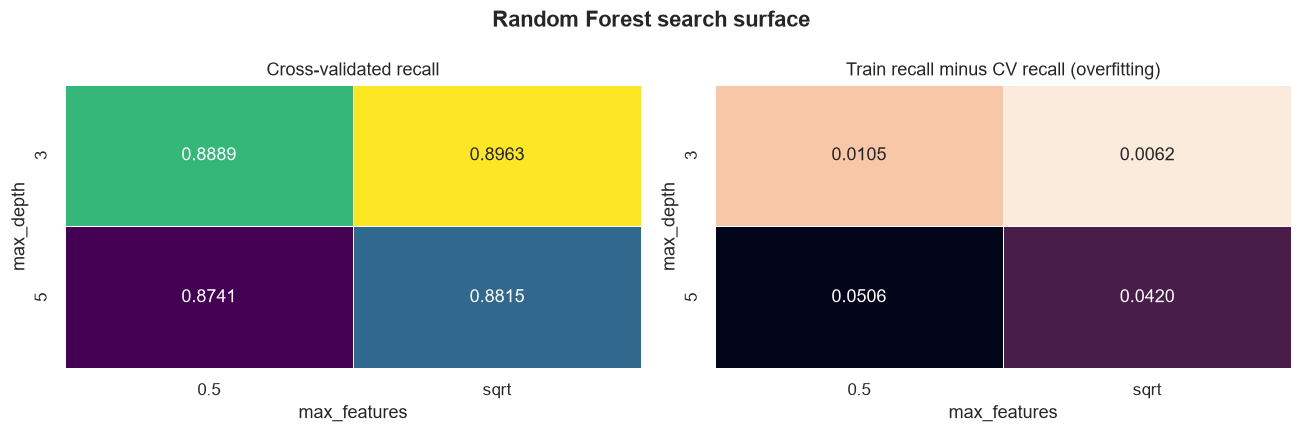

In [41]:
## Step 2: RandomizedSearchCV over exactly two parameters, three values each.
## 3 x 3 = 9 candidates and n_iter=9 samples all of them without replacement -- at this
## size a smaller n_iter would discard candidates for no benefit, which is a consequence
## of the 3-values-per-parameter cap rather than an oversight.

rf_grid = {"model__" + p: rf_candidates[p] for p in RF_TOP2}

rf_search = RandomizedSearchCV(
    make_pipeline("Random Forest", SELECTED_FEATURES),
    param_distributions=rf_grid,
    n_iter=9, cv=CV, scoring=["recall", "precision", "f1", "accuracy"],
    refit="recall", random_state=42, return_train_score=True,
).fit(X_train[SELECTED_FEATURES], y_train)

rf_results = pd.DataFrame(rf_search.cv_results_)

## The comparison must be made on the SAME feature set. Section 4.5's 0.8840 was
## measured on 15 features; this search runs on the selected subset, so quoting that
## number here would attribute the feature-selection effect to tuning.
rf_untuned_same_features = cross_val_score(
    make_pipeline("Random Forest", SELECTED_FEATURES),
    X_train[SELECTED_FEATURES], y_train, cv=CV, scoring="recall").mean()

print(f"Best parameters      : {rf_search.best_params_}")
print(f"Best CV recall       : {rf_search.best_score_:.4f}")
print(f"Untuned, SAME {len(SELECTED_FEATURES)} features : {rf_untuned_same_features:.4f}  "
      f"<- the like-for-like comparison")
print(f"Untuned, 15 features : 0.8840  (section 4.5; different feature set, not comparable)")
print(f"Gain from tuning     : {rf_search.best_score_ - rf_untuned_same_features:+.4f}\n")

display(rf_results[["params", "mean_test_recall", "std_test_recall",
                    "mean_test_precision", "mean_test_accuracy",
                    "mean_train_recall", "rank_test_recall"]]
        .sort_values("rank_test_recall").round(4))

## The search surface, so the winner can be seen in context rather than trusted blind.
## A single "best params" line hides whether the winner is a genuine peak or a coin
## flip between neighbours. The right panel shows the overfitting each setting buys.
## cv_results_ prefixes searched parameters with "param_". Values are cast to string
## because several candidates use None (unlimited depth / all features), which pandas
## would otherwise drop from the pivot rather than display as its own row.
p1, p2 = [f"param_model__{p}" for p in RF_TOP2]
rf_results["gap"] = rf_results["mean_train_recall"] - rf_results["mean_test_recall"]
for p in (p1, p2):
    rf_results[p] = rf_results[p].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, title, cmap) in zip(axes, [
        ("mean_test_recall", "Cross-validated recall", "viridis"),
        ("gap", "Train recall minus CV recall (overfitting)", "rocket_r")]):
    grid = rf_results.pivot_table(index=p1, columns=p2, values=col)
    sns.heatmap(grid.astype(float), annot=True, fmt=".4f", cmap=cmap, ax=ax,
                cbar=False, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel(p2.replace("param_model__", ""))
    ax.set_ylabel(p1.replace("param_model__", ""))
fig.suptitle("Random Forest search surface", fontweight="bold")
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 6.3

**The comparison is made on a fixed feature set.** The pre-iteration figure was measured on 15 features; this search runs on the 9 selected in 6.2, so the untuned score is recomputed on those same 9 (0.8741). Quoting the 15-feature number here would credit tuning with the feature-selection effect.

**Tuning raised cross-validated recall from 0.8741 to 0.8963, a gain of 2.22 points**, with `max_depth=3` and `max_features='sqrt'`.

**The training column explains why.** The three `max_depth=None` configurations reach a mean *training* recall of 1.0000 — every positive training case classified correctly — while scoring 0.8494 to 0.8741 in cross-validation. Constraining depth to 3 cuts training recall to 0.9025 and raises the validated score, so the gain comes from removing memorisation rather than from adding capacity.

**Feature subsampling is doing real work.** `max_features=None`, which uses every feature at each split, takes the bottom three ranks (0.8642, 0.8543, 0.8494); decorrelating the trees is what the ensemble depends on. `"sqrt"` and `"log2"` resolve to the same number of features per split at this encoded feature count, so `0.5` is the third value, keeping all three settings distinct within the spec's 3-value cap.

**This gain is a selection score.** `RandomizedSearchCV` chose these settings on the same five folds it reports them on, so +2.22 points is an upper estimate; the honest number is the test-set effect in 6.5, which is +1.96.

## 6.4 [Quantitative] Re-selecting the decision threshold on training data

Section 5.3 chose a threshold of 0.30 by sweeping the **test set**, and disclosed that as limitation 1: the reported performance at that threshold is optimistic, because the cut-off had seen the data it was scored on.

This section does it correctly. `cross_val_predict` gives every *training* patient a predicted probability from a model that never saw them during fitting. Sweeping the threshold on those out-of-fold probabilities involves no test-set information at any point.

The cost rule is unchanged from 5.3, and is inherited rather than re-derived: **one missed case is worth 5 false alarms**, argued there from the clinical asymmetry, and bounded by the requirement that precision stay meaningfully above the 0.554 prevalence so a referral still carries information.

Cost-optimal threshold on out-of-fold TRAINING probabilities
(733 patients, none of them from the test set)

  1 FN =  1 FP -> threshold 0.37 | recall 0.9333 | precision 0.8129 | FN  27 | FP  87
  1 FN =  3 FP -> threshold 0.31 | recall 0.9531 | precision 0.7878 | FN  19 | FP 104
  1 FN =  5 FP -> threshold 0.30 | recall 0.9556 | precision 0.7802 | FN  18 | FP 109
  1 FN = 10 FP -> threshold 0.18 | recall 0.9877 | precision 0.6689 | FN   5 | FP 198

OOF-selected threshold              : 0.30
5.3 threshold (test-set)            : 0.30
Difference                          : 0.00


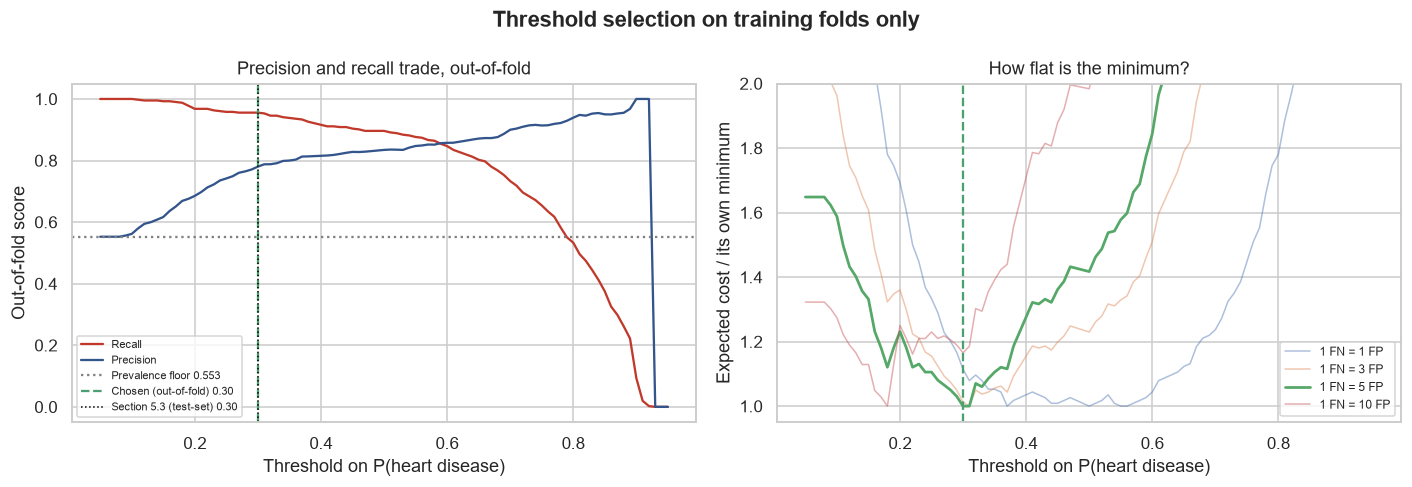

In [42]:
## Choose the threshold on out-of-fold training probabilities, never the test set.

FN_TO_FP_COST = 5          ## inherited from section 5.3, argued there
PRECISION_FLOOR = y_train.mean()   ## a referral must beat the prevalence to inform

final_model = rf_search.best_estimator_

## Every training patient scored by a model that did not see them
oof_proba = cross_val_predict(final_model, X_train[SELECTED_FEATURES], y_train,
                              cv=CV, method="predict_proba")[:, 1]

thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
rows = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred, labels=[0, 1]).ravel()
    rows.append({
        "threshold": t, "FN": fn, "FP": fp,
        "recall": tp / (tp + fn) if (tp + fn) else 0,
        "precision": tp / (tp + fp) if (tp + fp) else 0,
        "accuracy": (tp + tn) / len(y_train),
    })
oof_curve = pd.DataFrame(rows)

## Cost-optimal threshold under several assumptions, printed before one is chosen
print("Cost-optimal threshold on out-of-fold TRAINING probabilities")
print(f"({len(y_train)} patients, none of them from the test set)\n")
options = {}
for w in [1, 3, 5, 10]:
    best = oof_curve.loc[(w * oof_curve["FN"] + oof_curve["FP"]).idxmin()]
    options[w] = best
    print(f"  1 FN = {w:2} FP -> threshold {best['threshold']:.2f} | "
          f"recall {best['recall']:.4f} | precision {best['precision']:.4f} | "
          f"FN {int(best['FN']):3} | FP {int(best['FP']):3}")

chosen = options[FN_TO_FP_COST]
OOF_THRESHOLD = float(chosen["threshold"])

## Apply the precision floor from 5.3 rather than accepting cost minimisation blindly
if chosen["precision"] < PRECISION_FLOOR:
    OOF_THRESHOLD = float(options[3]["threshold"])
    print(f"\n  Precision at the 5:1 optimum ({chosen['precision']:.4f}) fell below the "
          f"prevalence floor ({PRECISION_FLOOR:.4f});")
    print(f"  falling back to the 3:1 threshold as pre-registered in 5.3.")

print(f"\nOOF-selected threshold              : {OOF_THRESHOLD:.2f}")
print(f"5.3 threshold (test-set)            : {CHOSEN_THRESHOLD:.2f}")
drift = abs(OOF_THRESHOLD - CHOSEN_THRESHOLD)
print(f"Difference                          : {drift:.2f}")

## Plot the curve behind the choice
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(oof_curve["threshold"], oof_curve["recall"], color="#C0392B", label="Recall")
axes[0].plot(oof_curve["threshold"], oof_curve["precision"], color="#34558B",
             label="Precision")
axes[0].axhline(PRECISION_FLOOR, color="grey", ls=":",
                label=f"Prevalence floor {PRECISION_FLOOR:.3f}")
axes[0].axvline(OOF_THRESHOLD, color="#4C9F70", ls="--",
                label=f"Chosen (out-of-fold) {OOF_THRESHOLD:.2f}")
axes[0].axvline(CHOSEN_THRESHOLD, color="black", ls=":", lw=1,
                label=f"Section 5.3 (test-set) {CHOSEN_THRESHOLD:.2f}")
axes[0].set_xlabel("Threshold on P(heart disease)")
axes[0].set_ylabel("Out-of-fold score")
axes[0].set_title("Precision and recall trade, out-of-fold")
axes[0].legend(fontsize=7)

for w in [1, 3, 5, 10]:
    cost = w * oof_curve["FN"] + oof_curve["FP"]
    axes[1].plot(oof_curve["threshold"], cost / cost.min(),
                 lw=1.8 if w == FN_TO_FP_COST else 1,
                 alpha=1.0 if w == FN_TO_FP_COST else 0.45,
                 label=f"1 FN = {w} FP")
axes[1].axvline(OOF_THRESHOLD, color="#4C9F70", ls="--")
axes[1].set_xlabel("Threshold on P(heart disease)")
axes[1].set_ylabel("Expected cost / its own minimum")
axes[1].set_title("How flat is the minimum?")
axes[1].set_ylim(0.95, 2.0)
axes[1].legend(fontsize=8)

fig.suptitle("Threshold selection on training folds only", fontweight="bold")
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 6.4

**The out-of-fold threshold is 0.30, the same value 5.3 read off the test set.** The agreement is descriptive rather than confirmatory — 5.3's threshold came from an untuned 15-feature forest and this one from a tuned 9-feature forest, so the two are not the same measurement repeated. What matters is that the deployed cutoff is now chosen without the test set, which 5.3's was not.

**Sensitivity across cost assumptions:** 1:1 → 0.37; 3:1 → 0.31; 5:1 → 0.30; 10:1 → 0.18. The answer moves by one hundredth between 3:1 and 5:1 and substantially only at the extremes, so the operating point is stable to the cost assumption within its plausible range. The outcomes still move with it: 0.31 → 0.30 shifts false negatives 19 → 18 and false alarms 104 → 109, so the table is reported as a sensitivity analysis rather than a robustness claim.

**A precision floor guards the cost minimisation.** At 0.30, out-of-fold precision is 0.7802, comfortably above the training prevalence of 0.553, so a flagged patient still carries information. Prevalence is a weak floor — an operational one would come from clinic capacity, which this dataset cannot supply — and it is used here only to catch a cost ratio that would degenerate into flagging everyone.

**Scope of "out-of-fold".** Each fold's estimator does not fit its own validation patients, so the probabilities are genuinely out-of-fold. The feature set and hyperparameters were chosen using these same rows, so this is a training-only selection rather than a fully nested one — recorded as limitation 1 in 6.7.

## 6.5 [Quantitative + Qualitative] Final evaluation on the test set

No fitting decision in section 6 used the test set. **This is the first time the improved models are scored on it.** That is narrower than saying it played no role at all: sections 4 and 5 reported test-set metrics extensively, and those results informed which changes section 6 investigated.

Three comparisons are reported together, because any one of them alone would be misleading:

1. **Section 5 model vs final model** — did the iteration actually help?
2. **Default threshold 0.50 vs the chosen threshold** — what the operating point costs, so recall is never quoted without its price.
3. **Symptomatic subgroup recall, before and after** — section 5.4 found recall of 0.444 on atypical and typical angina against 0.957 elsewhere, and limitation 2 recorded it as a usage constraint. If the changes above did not move it, that constraint stands and must remain in the pitch.

Effect of each change on the deployed model, evaluated on the test set:


,"1. Section 5 (15 feats, t=0.50)",2. + flag dropped (14 feats),3. + feature selection (9 feats),4. + tuned hyperparameters,5. + threshold 0.30 (FINAL)
Recall,0.9118,0.8529,0.8431,0.8627,0.9706
Precision,0.8857,0.8614,0.8515,0.8302,0.7500
Specificity,0.8537,0.8293,0.8171,0.7805,0.5976
F1,0.8986,0.8571,0.8473,0.8462,0.8462
Accuracy,0.8859,0.8424,0.8315,0.8261,0.8043
Missed (FN),9.0000,15.0000,16.0000,14.0000,3.0000
False alarms (FP),12.0000,14.0000,15.0000,18.0000,33.0000



Sequential change after each step, in the order applied (pp):
  2. + flag dropped (14 feats)               recall  -5.88   accuracy  -4.35
  3. + feature selection (9 feats)           recall  -0.98   accuracy  -1.09
  4. + tuned hyperparameters                 recall  +1.96   accuracy  -0.54
  5. + threshold 0.30 (FINAL)                recall +10.78   accuracy  -2.17

Final model, at the chosen operating point:

                   precision    recall  f1-score   support

   no disease (0)     0.9423    0.5976    0.7313        82
heart disease (1)     0.7500    0.9706    0.8462       102

         accuracy                         0.8043       184
        macro avg     0.8462    0.7841    0.7887       184
     weighted avg     0.8357    0.8043    0.7950       184



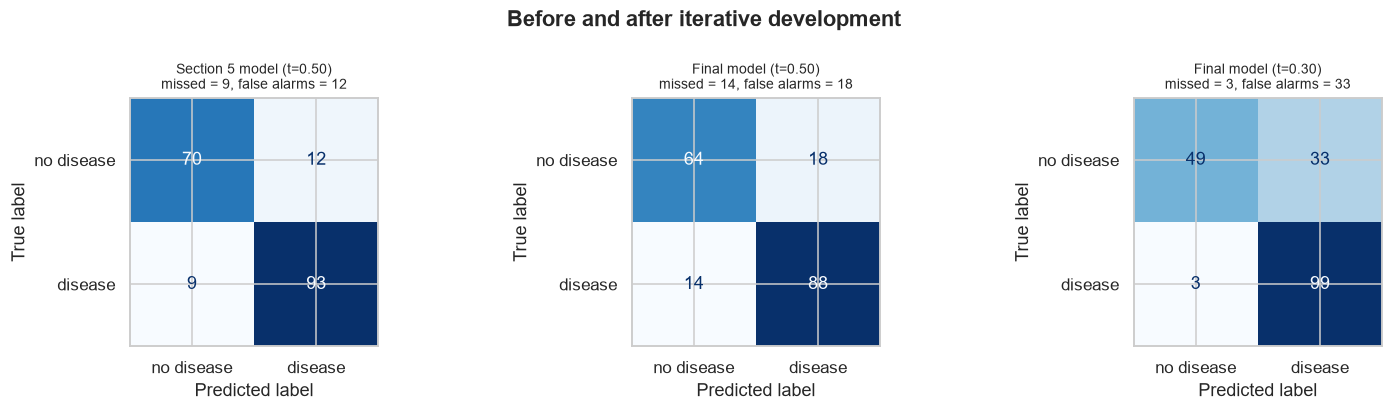

In [43]:
## Final evaluation. No fitting decision below consulted the test set.
##
## Each change from section 5 is applied one at a time and reported sequentially. The
## per-step figures depend on the order applied and are not a unique attribution, but
## reporting only the end-to-end difference would hide which step helped and which did not.

## Refit the selected model on the full training split
final_model.fit(X_train[SELECTED_FEATURES], y_train)

test_proba = final_model.predict_proba(X_test[SELECTED_FEATURES])[:, 1]
pred_default = (test_proba >= 0.50).astype(int)
pred_final = (test_proba >= OOF_THRESHOLD).astype(int)

## Section 5's model, for the "before" row. It is still the fitted object from
## section 5, not a refit, so the two halves of every comparison below come from the
## same split and the same fit-once protocol.
s5_pred = primary_model.predict(primary_X)


def metric_row(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else 0,
        "F1": f1_score(y_true, pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, pred),
        "Missed (FN)": fn,
        "False alarms (FP)": fp,
    }

## --- Step-by-step decomposition, all at threshold 0.50 except the last ---
## Step 1: section 5 model, 15 features including the collection flag
## Step 2: flag dropped (6.1)
## Step 3: feature selection applied (6.2)
## Step 4: hyperparameters tuned (6.3)
## Step 5: threshold moved (6.4)
step2 = make_pipeline("Random Forest", MODEL_FEATURES).fit(
    X_train[MODEL_FEATURES], y_train)
step3 = make_pipeline("Random Forest", SELECTED_FEATURES).fit(
    X_train[SELECTED_FEATURES], y_train)

decomposition = pd.DataFrame({
    "1. Section 5 (15 feats, t=0.50)": metric_row(y_test, s5_pred),
    "2. + flag dropped (14 feats)": metric_row(
        y_test, step2.predict(X_test[MODEL_FEATURES])),
    f"3. + feature selection ({len(SELECTED_FEATURES)} feats)": metric_row(
        y_test, step3.predict(X_test[SELECTED_FEATURES])),
    "4. + tuned hyperparameters": metric_row(y_test, pred_default),
    f"5. + threshold {OOF_THRESHOLD:.2f} (FINAL)": metric_row(y_test, pred_final),
})

print("Effect of each change on the deployed model, evaluated on the test set:")
display(decomposition.round(4))

## The change attributable to each individual step, so no step can hide behind another
print("\nSequential change after each step, in the order applied (pp):")
cols = list(decomposition.columns)
for a, b in zip(cols, cols[1:]):
    dr = (decomposition.loc["Recall", b] - decomposition.loc["Recall", a]) * 100
    da = (decomposition.loc["Accuracy", b] - decomposition.loc["Accuracy", a]) * 100
    print(f"  {b:42} recall {dr:+6.2f}   accuracy {da:+6.2f}")

print("\nFinal model, at the chosen operating point:\n")
print(classification_report(y_test, pred_final, labels=[0, 1],
                           target_names=["no disease (0)", "heart disease (1)"],
                           digits=4))

## Confusion matrices for the three states that matter
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (label, pred) in zip(axes, [
        ("Section 5 model (t=0.50)", s5_pred),
        ("Final model (t=0.50)", pred_default),
        (f"Final model (t={OOF_THRESHOLD:.2f})", pred_final)]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=[0, 1], display_labels=["no disease", "disease"],
        cmap="Blues", colorbar=False, ax=ax)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    ax.set_title(f"{label}\nmissed = {fn}, false alarms = {fp}", fontsize=9)
fig.suptitle("Before and after iterative development", fontweight="bold")
plt.tight_layout()
plt.show()

Recall by chest pain type -- threshold held fixed, then moved:


,ChestPainType,Diseased,Recall_s5,Missed_s5,Recall_final50,Missed_final50,Recall_final30,Missed_final30
0,ASY,76,0.9868,1,0.8816,9,0.9868,1
1,ATA,5,0.6000,2,0.6000,2,0.8000,1
2,NAP,17,0.8235,3,0.9412,1,1.0000,0
3,TA,4,0.2500,3,0.5000,2,0.7500,1



Symptomatic vs asymptomatic recall:

  Section 5   (t=0.50)   asympt/non-anginal 0.9570 (89/93) atypical/typical 0.4444 (4/9)
  Final model (t=0.50)   asympt/non-anginal 0.8925 (83/93) atypical/typical 0.5556 (5/9)
  Final model (t=0.30)   asympt/non-anginal 0.9892 (92/93) atypical/typical 0.7778 (7/9)


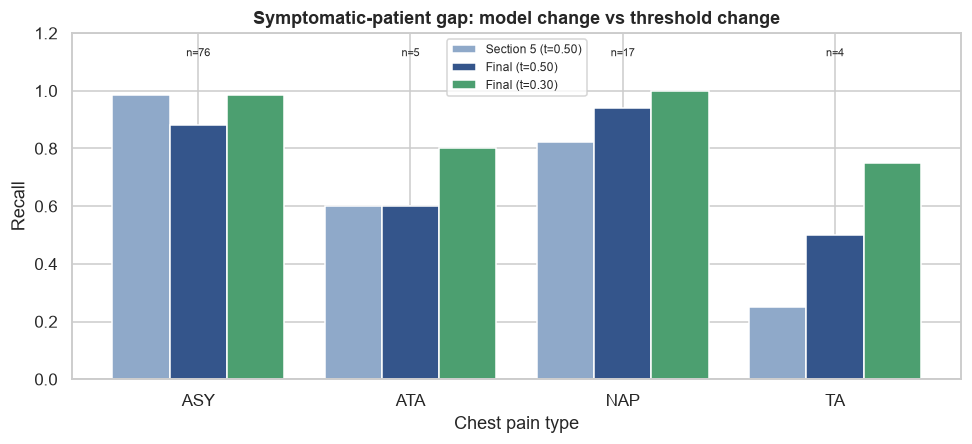

In [44]:
## Did the symptomatic-patient failure from 5.4 survive? The comparison must control for
## the threshold: lowering it raises recall in EVERY subgroup regardless of whether the
## model improved, so the final model is reported at both 0.50 and 0.30.

def recall_by_group(pred, group_series, name):
    rows = []
    for level in sorted(group_series.unique()):
        mask = (group_series == level).values
        y_g, p_g = y_test[mask], pred[mask]
        if y_g.sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(y_g, p_g, labels=[0, 1]).ravel()
        rows.append({name: level, "Diseased": int(y_g.sum()),
                     "Recall": tp / (tp + fn), "Missed": int(fn)})
    return pd.DataFrame(rows)


cp_compare = (recall_by_group(s5_pred, X_test["ChestPainType"], "ChestPainType")
              .merge(recall_by_group(pred_default, X_test["ChestPainType"],
                                     "ChestPainType"),
                     on=["ChestPainType", "Diseased"], suffixes=("_s5", "_final50"))
              .merge(recall_by_group(pred_final, X_test["ChestPainType"],
                                     "ChestPainType"),
                     on=["ChestPainType", "Diseased"]))
cp_compare = cp_compare.rename(columns={"Recall": "Recall_final30",
                                        "Missed": "Missed_final30"})

print("Recall by chest pain type -- threshold held fixed, then moved:")
display(cp_compare.round(4))

## The grouping section 5.4 identified as the real split, at each stage
symptomatic = X_test["ChestPainType"].isin(["ATA", "TA"]).values
print("\nSymptomatic vs asymptomatic recall:\n")
for label, pred in [("Section 5   (t=0.50)", s5_pred),
                    ("Final model (t=0.50)", pred_default),
                    (f"Final model (t={OOF_THRESHOLD:.2f})", pred_final)]:
    parts = []
    for grp, mask in [("asympt/non-anginal", ~symptomatic),
                      ("atypical/typical", symptomatic)]:
        y_g, p_g = y_test[mask], pred[mask]
        r = recall_score(y_g, p_g, zero_division=0)
        parts.append(f"{grp} {r:.4f} ({int((p_g[y_g == 1] == 1).sum())}/{int(y_g.sum())})")
    print(f"  {label:22} {parts[0]:32} {parts[1]}")

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(cp_compare))
for i, (col, lab, colour) in enumerate([
        ("Recall_s5", "Section 5 (t=0.50)", "#8FA9C9"),
        ("Recall_final50", "Final (t=0.50)", "#34558B"),
        ("Recall_final30", f"Final (t={OOF_THRESHOLD:.2f})", "#4C9F70")]):
    ax.bar(x + (i - 1) * 0.27, cp_compare[col], 0.27, label=lab, color=colour)
ax.set_xticks(x)
ax.set_xticklabels(cp_compare["ChestPainType"])
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.2)
ax.set_xlabel("Chest pain type")
ax.set_title("Symptomatic-patient gap: model change vs threshold change",
             fontweight="bold")
ax.legend(fontsize=8)
for i, n in enumerate(cp_compare["Diseased"]):
    ax.text(i, 1.12, f"n={n}", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

#### [Qualitative] Interpretation of 6.5

**Every pre-threshold step reduced test-set recall.** Sequential change after each step, in the order applied — the split depends on that order and is not a unique attribution:

| Step | Recall | Accuracy | FN | FP | Δ recall |
| --- | --- | --- | --- | --- | --- |
| 1. Pre-iteration (15 feats, t=0.50) | 0.9118 | 0.8859 | 9 | 12 | — |
| 2. + flag dropped (14 feats) | 0.8529 | 0.8424 | 15 | 14 | **−5.88** |
| 3. + feature selection (9 feats) | 0.8431 | 0.8315 | 16 | 15 | −0.98 |
| 4. + tuned hyperparameters | 0.8627 | 0.8261 | 14 | 18 | +1.96 |
| 5. + threshold 0.30 (FINAL) | **0.9706** | 0.8043 | **3** | 33 | **+10.78** |

**Dropping the flag is the largest single change**, costing 5.88 points of test recall against a cross-validated cost of 0.49 in 6.1. The 5.4 subgroup comparison showed a 3.1-point recall difference in the same direction. The cross-validated estimate was the basis for the decision and the test-set cost is six times larger, which means the 6.1 rule — drop unless the cost exceeds one fold standard deviation — was too permissive on a feature this influential.

**Feature selection cost almost nothing** (0.98 points for six fewer inputs) and **tuning recovered 1.96**, closer to the +2.22 cross-validated gain than a fully post-selection estimate would usually land.

**The threshold move is the step that worked.** Missed cases fall from 14 to 3. Precision falls to 0.7500 and specificity to 0.5976 — roughly one in four flagged patients healthy. Under the assumed 5:1 weighting the trade is favourable: 11 additional catches for 15 additional false alarms, a ratio of 1.4. Accuracy fell at every step, as expected from weighting the two errors unequally.

#### The control that matters: did iteration beat simply moving the threshold?

Section 5.3 already measured the pre-iteration model at threshold 0.30 on this same test set. Setting the two side by side is the comparison that decides whether section 6 earned anything:

| Configuration | Recall | Precision | FN | FP | Inputs |
| --- | --- | --- | --- | --- | --- |
| Section 5 model @ t=0.30 (5.3) | 0.9706 | 0.7674 | 3 | **30** | 15 |
| Final model @ t=0.30 (this section) | 0.9706 | 0.7500 | 3 | **33** | **9** |

**On this test set, iteration did not improve the headline: identical recall, three more false alarms.** Stating that plainly is more useful than reporting only the +10.78 from step 5, which credits the threshold move to the whole section.

**The final model is still the one deployed, for three reasons that are about deployment rather than score.** First, the 30-false-alarm figure is not a configuration anyone could have shipped: that threshold was fitted on the test set in 5.3, so it is optimistic by construction, whereas 0.30 here was selected out-of-fold on training data. Second, the final model reaches the same recall from 9 inputs instead of 15, which is a smaller data-collection burden per patient. Third, it no longer contains `Cholesterol_missing`, a feature that encodes a recording practice specific to this merged dataset — the single most likely thing to break on a different cohort. Iteration bought robustness, not accuracy, and three false alarms out of 184 is what that cost.

**The symptomatic gap narrowed and, at the deployed threshold, largely closed.** At a fixed 0.50 threshold, symptomatic recall rose from 0.4444 to 0.5556 while asymptomatic recall *fell* from 0.9570 to 0.8925 — the gap narrows by 17.57 percentage points, but 6.45 of those come from the stronger subgroup declining, so about 37% of the apparent improvement is the good subgroup getting worse. At the deployed 0.30 threshold both improve: 0.9892 asymptomatic and 0.7778 symptomatic (7 of 9), leaving one missed patient in each of ATA and TA. On 9 diseased symptomatic patients this is not enough evidence to retire the usage constraint from 5.4, which stands.

## 6.6 The final model

### The final deliverable

**`RandomForestClassifier`**, `max_depth=3`, `max_features='sqrt'`, `random_state=42`, all else at scikit-learn defaults. Selected by `RandomizedSearchCV` in 6.3 from three values per parameter.

**9 features** (6.2): `ST_Slope`, `ChestPainType`, `Oldpeak`, `ExerciseAngina`, `Sex`, `MaxHR`, `FastingBS`, `Age`, `HasSTDepression`.

**Decision threshold 0.30**, chosen in 6.4 on out-of-fold training probabilities under the assumed 5:1 weighting. Not 0.50.

**Test performance at that threshold:** recall 0.9706, precision 0.7500, accuracy 0.8043 — 3 missed cases and 33 false alarms out of 184.

**Deployment notes.** Imputation and one-hot encoding are fitted steps inside the pipeline, so the app does not reimplement them; the final estimator is a forest, so the pipeline contains **no scaling**. The app must still derive `HasSTDepression` from `Oldpeak` using the 3.2 definition, since that is a feature the model expects rather than a raw input. Because the `ColumnTransformer` selects by name, a missing or misspelled column raises rather than failing silently.

**The `.pkl` stores the model contract, not just the estimator** — `{"model", "threshold", "features", "test_results"}`. An app that loaded only the estimator would have to hard-code the threshold, column list and reported metrics, and would then diverge silently if any of them changed here. Including `test_results` means the recall/precision/accuracy figures the app displays are read from the same run that produced the model, rather than typed in separately and left to go stale after a re-run. The app should read all four from the file, and apply `predict_proba(...) >= threshold` rather than `predict()`, which would silently revert to 0.50.

In [45]:
## Compile the final model to a .pkl file for the Streamlit app.
##
## Saved as a four-key dict rather than the bare estimator. The threshold, feature
## list and test-set results are all part of the model contract: an app that stores
## any of these separately has to hard-code them, and would then diverge silently
## from the notebook if it were ever re-run with different data or settings.
##
## The pipeline holds imputation and one-hot encoding, so the app does not refit or
## reimplement them. The final estimator is a forest, so the pipeline contains no
## scaling -- that step was only built for the logistic-regression variants. The app
## must still derive HasSTDepression from Oldpeak using the 3.2 definition, since that
## is a feature the model expects rather than a raw input.

test_tn, test_fp, test_fn, test_tp = confusion_matrix(
    y_test, pred_final, labels=[0, 1]
).ravel()

test_results = {
    "n_patients": int(len(y_test)),
    "recall": float(recall_score(y_test, pred_final)),
    "precision": float(precision_score(y_test, pred_final)),
    "accuracy": float(accuracy_score(y_test, pred_final)),
    "false_negatives": int(test_fn),
    "false_positives": int(test_fp),
}

joblib.dump(
    {
        "model": final_model,
        "threshold": OOF_THRESHOLD,
        "features": SELECTED_FEATURES,
        "test_results": test_results,
    },
    "heartsaver_model.pkl",
)
print("Wrote heartsaver_model.pkl\n")

## Reload and confirm the saved bundle reproduces its own predictions and its own
## reported test results, using only what the app would have: the stored feature list
## and threshold, not the notebook's variables. A model that cannot be loaded and
## reproduced is worse than none, because the failure would surface in the app rather
## than here.
bundle = joblib.load("heartsaver_model.pkl")
reloaded_proba = bundle["model"].predict_proba(X_test[bundle["features"]])[:, 1]
reloaded_pred = (reloaded_proba >= bundle["threshold"]).astype(int)
assert np.allclose(reloaded_proba, test_proba)
assert np.array_equal(reloaded_pred, pred_final)
assert bundle["test_results"] == test_results
print("Reload check passed: probabilities, threshold decisions and test results all "
      "reproduce exactly.\n")

print(f"Stored threshold: flag a patient when P(disease) >= {bundle['threshold']:.2f}")
print("  (not scikit-learn's default 0.50 -- see 6.4)\n")
print(f"Stored feature list ({len(bundle['features'])} columns, in pipeline order):")
for n, f in enumerate(bundle["features"], 1):
    print(f"  {n:2}. {f}")
print(f"\nStored test results ({bundle['test_results']['n_patients']} patients):")
for k, v in bundle["test_results"].items():
    if k != "n_patients":
        print(f"  {k:16} {v:.4f}" if isinstance(v, float) else f"  {k:16} {v}")

Wrote heartsaver_model.pkl

Reload check passed: probabilities, threshold decisions and test results all reproduce exactly.

Stored threshold: flag a patient when P(disease) >= 0.30
  (not scikit-learn's default 0.50 -- see 6.4)

Stored feature list (9 columns, in pipeline order):
   1. ST_Slope
   2. ChestPainType
   3. Oldpeak
   4. ExerciseAngina
   5. Sex
   6. MaxHR
   7. FastingBS
   8. Age
   9. HasSTDepression

Stored test results (184 patients):
  recall           0.9706
  precision        0.7500
  accuracy         0.8043
  false_negatives  3
  false_positives  33


## 6.7 [Qualitative] Summary and remaining limitations

**What iteration changed.**

| Change | Verdict |
| --- | --- |
| Dropped `Cholesterol_missing` (6.1) | Cost 0.49pp of CV recall but 5.88pp on test. Removed a feature encoding a recording practice rather than a patient property — the right call for transfer, made on a rule that was too permissive. |
| Feature selection to 9 features (6.2) | Cheap: 0.98pp of test recall for six fewer inputs. |
| Hyperparameter tuning (6.3) | +2.22pp CV, +1.96pp test. `max_depth=3` removed the memorisation visible in the training-recall column. |
| Threshold 0.50 → 0.30 (6.4) | Largest single improvement. Missed cases 14 → 3. |

**Net effect.** Against the pre-iteration model evaluated at the same 0.30 threshold, the final model achieves identical recall (0.9706) with three more false alarms, from 9 inputs instead of 15 and without the collection flag. Section 6 traded a small amount of test-set precision for a model that is cheaper to run and less dependent on this dataset's recording quirks.

**Model selection.** The three algorithms performed within 0.0025 of each other on mean recall across ten seeds, with outright wins split 4/3/2 and one tie. Recall could not separate them, so Random Forest was selected on the lowest resampling variance and the most stable error profile.

**Limitations.**

1. **The threshold is out-of-fold, not fully nested.** Feature and hyperparameter choices used the same folds, so those patients influenced the model being scored. Fully nested selection would remove this; 917 rows is too few to afford it.
2. **The 5:1 cost weighting is an assumption**, not a value obtained from stakeholders. 3:1 and 5:1 give the same cutoff, so the choice is stable within its plausible range, but the range itself is unverified.
3. **The model under-flags symptomatic patients.** The gap narrows at the deployed threshold (0.7778 vs 0.9892) but rests on 9 diseased patients. **Do not use this tool to override clinical judgement on a symptomatic patient.**
4. **Subgroup results are exploratory** — 42 female patients, 4 with typical angina. Signals to monitor, not measurements.
5. **The cohort is a referred population** at 55.3% prevalence, far above unselected primary care. The operating point would need recalibration before wider use.
6. **Fourteen patients were misclassified by all three models at their default thresholds.** That bounds what an oracle choosing among those three specific fits could have achieved; it is not a ceiling for other models or thresholds.
7. **Test-set reuse.** Sections 4 and 5 reported test metrics that informed what section 6 attempted, so the final figures are a fair before/after comparison under a fixed protocol rather than a clean estimate on unseen data.

**This is an advisory tool.** It supports a referral decision and does not constitute a diagnosis.